# 03 Temporal Fusion Transformer

**AI for Business Prognosis, Capstone Projekt Multi Country BIP Prognose**

Dieses Notebook behandelt den Temporal Fusion Transformer als Deep Learning Methode
zum Methodenvergleich und deckt schwerpunktmäßig CRISP DM Phase 4 (Modeling)
ab, einschließlich der modellspezifischen Anteile von Phase 3 (Data Preparation) und
Phase 5 (Evaluation). Die Phasen 1 bis 3 auf Ebene des gesamten Panels (Business
Understanding, Data Understanding, generische Data Preparation) sind in
`01_Datenbeschaffung_Aufbereitung.ipynb` dokumentiert. Der finale, modellübergreifende
Vergleich in Phase 5 folgt in `05_Vergleich.ipynb`.

| CRISP DM Phase | Abschnitt in diesem Notebook |
|---|---|
| Business und Data Understanding | Abschnitt 1 |
| Data Preparation, TFT spezifisch | Abschnitt 3 |
| Modeling | Abschnitte 2, 4 und 5 |
| Evaluation, TFT spezifisch | Abschnitte 6 und 7 |
| Diskussion und Übergabe | Abschnitte 8 und 9 |

Der Temporal Fusion Transformer ist für das Team eine neue Methode gemäß der
Projektanforderung, ein neues Verfahren anzuwenden. Dieser passt
zugleich inhaltlich zum vorliegenden Datensatz. Ein globales Modell über 116 Länder mit
drei ausdrücklich unterschiedenen Kovariatenrollen (statisch, bekannt zukünftig, nur
vergangen beobachtet) entspricht genau der Unterscheidung, die `src/config.py` bereits
über `KNOWN_FUTURE` und `PAST_ONLY` trifft. Hinzu kommen native Quantilsprognosen und
eingebaute Interpretierbarkeit über Variablenwichtigkeit und Attention. SARIMAX als
klassisches, länderweises Verfahren sowie Chronos 2 als Zero Shot Foundation Model werden
in den Notebooks 02 und 04 behandelt. Der gemeinsame Vergleich aller Verfahren
einschließlich der Baseline folgt in Notebook 05.

Dieses Notebook folgt der in `01_Datenbeschaffung_Aufbereitung.ipynb` festgelegten
Schnittstelle zwischen den Notebooks. Es lädt `data/processed/gdp_panel.csv` über
`src.data_utils.load_panel()` und speichert seine Prognosen über
`src.evaluation.save_predictions(df, "tft")` im Standardschema `src.config.RESULTS_COLUMNS`
nach `data/results/preds_tft.csv`.

## 0 Setup

Das Notebook läuft lokal. Zusätzlich zu den Kernabhängigkeiten des
Repositoriums werden `torch`, `lightning` und `pytorch forecasting` benötigt. Diese sind
in `pyproject.toml` eingetragen, `uv sync` installiert sie einschließlich einer CPU
Version von Torch automatisch. Steht eine NVIDIA GPU zur Verfügung, installiert `uv sync --extra cuda --no-default-groups`
stattdessen eine CUDA fähige Version von Torch, wofür `pyproject.toml` bereits eine eigene
Abhängigkeitsgruppe bereitstellt.

Ein vollständiger Durchlauf (Hyperparametersuche und fünf Backtest Folds mit jeweils
zweistufigem Training) dauert auf einer üblichen CPU etwa 20 bis 30 Minuten. Für eine
schnelle Funktionsprüfung lässt sich weiter unten `FAST_DEV_RUN = True` setzen, was ein
kleineres Suchraster, weniger Trainingsepochen und nur zwei statt fünf Origins verwendet.
Für die Abgabe und Präsentation gilt der Standardwert `FAST_DEV_RUN = False`.

In [1]:
# Lädt geaenderte Module aus src automatisch neu.
%load_ext autoreload
%autoreload 2

import sys
import textwrap
import time
import warnings
from pathlib import Path

# Setzt die Projektwurzel CapstoneProjekt_BPI in den Suchpfad, damit src importierbar ist.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning.pytorch as pl

from src import config, data_utils, evaluation, plotting, tft_utils

# Begrenzt die Ausgabe auf Fehler und Warnungen aus eigenem Code. Lightning hängt
# seine rank_zero_info Meldungen, etwa zur GPU Erkennung oder Produktwerbung für
# LitLogger, an den Logger seines zuletzt importierten Teilmoduls, nicht an den
# Logger "lightning" selbst, weshalb dieser gezielt benannt werden muss.
warnings.filterwarnings("ignore")
import logging
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch.utilities.rank_zero").setLevel(logging.ERROR)
logging.getLogger("pytorch_forecasting").setLevel(logging.ERROR)

SEED = tft_utils.SEED
pl.seed_everything(SEED, verbose=False)
torch.set_num_threads(max(1, torch.get_num_threads()))

plotting.apply_style()
pd.set_option("display.max_columns", 30)
print("Projektwurzel gefunden", ROOT.name)
print("Torch Version", torch.__version__, "CUDA verfügbar", torch.cuda.is_available())
print("Der Konsistenzcheck der Feature Rollen aus tft_utils.validate_feature_roles() "
      "wurde beim Import erfolgreich ausgeführt.")

Projektwurzel gefunden CapstoneProjekt_BPI
Torch Version 2.13.0+cpu CUDA verfügbar False
Der Konsistenzcheck der Feature Rollen aus tft_utils.validate_feature_roles() wurde beim Import erfolgreich ausgeführt.


In [2]:
# FAST_DEV_RUN = True eignet sich für eine schnelle Funktionsprüfung des Notebooks.
# Für die Abgabe und die Präsentation wird dieser Wert auf False gesetzt.
FAST_DEV_RUN = False

## 1 Business und Data Understanding

Notebook 01 behandelt diese Phasen ausführlich. Hier folgen nur die Punkte, die für die
Modellierung mit dem Temporal Fusion Transformer unmittelbar relevant sind.

Das Geschäftsproblem ist die Prognose des realen BIP Wachstums für 116 Länder über einen
Horizont von fünf Jahren als Entscheidungsgrundlage für Haushalts und Investitionsplanung.
Ein globales Modell, also ein einziges Modell für alle Länder mit gemeinsamem Lernen über
Länder hinweg, ist hier methodisch sinnvoll. Selbst nach dem in Notebook 01 angewendeten
Filter auf mindestens `config.MIN_YEARS = 35` Jahre Historie liefert ein einzelnes Land
lediglich 35 bis 65 jährliche Beobachtungen. Das sind deutlich zu wenig, um ein Modell mit so
vielen Parametern wie den Temporal Fusion Transformer allein aus den Daten eines Landes
zu trainieren. Ein globales Modell nutzt stattdessen alle 116 Länder gemeinsam als
Trainingsgrundlage und kann zusätzlich gemeinsame Muster wie globale Konjunkturzyklen oder
den Konvergenzeffekt über Länder hinweg lernen. Das ist die zentrale Stärke eines Panel
Deep Learning Modells wie des Temporal Fusion Transformers gegenüber 116 getrennt
geschätzten Modellen.

Drei Befunde aus der explorativen Analyse in Notebook 01 prägen die
Modellierungsentscheidungen dieses Notebooks:
- Die Eigendynamik der Zielgröße ist gering. Die mediane Lag 1 Autokorrelation von
`gdp_growth` liegt nur bei etwa 0,27. Reine Autoregression trägt damit wenig, exogene
Treiber und länderübergreifendes Lernen sind entscheidend. Der Temporal Fusion
Transformer nutzt deshalb aktiv die Treiber aus `KNOWN_FUTURE` und `PAST_ONLY`, statt nur
die Zielreihe selbst fortzuschreiben.
- Zweitens ist die Volatilität heterogen. Ärmere Länder schwanken deutlich stärker als
reiche Länder, mit einer medianen Standardabweichung von etwa 5,5 in der Gruppe der
Länder mit niedrigem Einkommen gegenüber etwa 4,2 in der Gruppe mit hohem Einkommen. Aus
diesem Grund wird je Land normiert (`GroupNormalizer`) statt global, und die Auswertung
erfolgt mit der skalenfreien MASE.
- Zuletzt zeigen die Demografievariablen ein Confounding Muster. `dependency_ratio` und
`working_age_share` korrelieren gepoolt scheinbar entgegen der ökonomischen Erwartung mit
dem Wachstum, weil sich ein Querschnittseffekt mit dem eigentlichen Zeitreiheneffekt
überlagert. Statische Ländermerkmale wie `region` und `income_group` geben dem Modell die
Möglichkeit, Länderheterogenität explizit abzubilden, statt sie in gepoolten
Koeffizienten zu verstecken.

In [3]:
panel = data_utils.load_panel()          # Eine Zeile je Land und Jahr
meta = data_utils.load_panel_meta()      # Merkmalsgruppen, Splits, Ergebnisschema
static = pd.read_csv(config.PROCESSED_DIR / "countries_static.csv")

print(f"Panel {panel['country'].nunique()} Länder, "
      f"{panel['year'].min()} bis {panel['year'].max()}, {len(panel):,} Zeilen")
print("Ziel", meta["target"])
print("Bekannt zukünftig", meta["known_future_features"])
print("Gelaggt, nur Vergangenheit", meta["lagged_features"])
print("Backtest Origins", config.ALL_ORIGINS, "Horizont", config.HORIZON)
panel.head()

Panel 116 Länder, 1960 bis 2024, 7,540 Zeilen
Ziel gdp_growth
Bekannt zukünftig ['pop_growth', 'working_age_share']
Gelaggt, nur Vergangenheit ['log_gdp_pc_lag1', 'investment_gdp_lag1', 'trade_gdp_lag1', 'inflation_log_lag1']
Backtest Origins [1999, 2004, 2009, 2014, 2019] Horizont 5


,country,year,dependency_ratio,gdp_growth,pop_growth,working_age_share,log_gdp_pc_lag1,investment_gdp_lag1,trade_gdp_lag1,inflation_log_lag1,is_global_crisis
0,ABW,1960,83.046159,NaN,NaN,54.632024,NaN,NaN,NaN,NaN,0
1,ABW,1961,81.969092,NaN,1.187344,54.953804,NaN,NaN,NaN,NaN,0
2,ABW,1962,81.058317,NaN,1.326227,55.230824,NaN,NaN,NaN,NaN,0
3,ABW,1963,79.794348,NaN,1.203664,55.618712,NaN,NaN,NaN,NaN,0
4,ABW,1964,78.152923,NaN,1.076602,56.131658,NaN,NaN,NaN,NaN,0


## 2 Methodik, der Temporal Fusion Transformer

### 2.1 Einordnung

| | Baseline, Random Walk | Klassisch, SARIMAX | Temporal Fusion Transformer |
|---|---|---|---|
| Modell je | Land | Land | global, ein Modell für alle Länder |
| Nichtlinearität | nein | nein, linear in den Exogenen | ja |
| Kovariatentypen | keine | eine gemeinsame Gruppe Exogener | getrennt in statisch, bekannt zukünftig und nur vergangen |
| Unsicherheit | keine | analytisches Konfidenzintervall | Quantilsregression mit q10, q50 und q90 |
| Interpretierbarkeit | trivial | Koeffizienten | Gewichte der Variablenauswahl und Attention |
| Lernen über Länder hinweg | nein | nein | ja |

Der Temporal Fusion Transformer wurde von Lim, Arik, Loeff und Pfister im Jahr 2021 in
der Zeitschrift International Journal of Forecasting unter dem Titel Temporal Fusion
Transformers for Interpretable Multi Horizon Time Series Forecasting vorgestellt. Er
wurde für Probleme wie das vorliegende entworfen, nämlich für mehrere heterogene
Zeitreihen mit einer Mischung aus statischen Metadaten, Kovariaten mit bekannter Zukunft
und Kovariaten mit unbekannter Zukunft. Diese Dreiteilung ist kein Implementierungsdetail,
sondern der Kern der Architektur, und sie entspricht genau der Unterscheidung, die
`src/config.py` bereits über `KNOWN_FUTURE` und `PAST_ONLY` trifft, wie in Notebook 01
unter der Überschrift zur Trennung der Datenrollen beschrieben.

Die Anwendung von Temporal Fusion Transformern auf die gemeinsame BIP Prognose mehrerer
Länder ist selbst bereits Gegenstand aktueller Forschung. Laborda, Ruano und Zamanillo
(2023, Multi Country and Multi Horizon GDP Forecasting Using Temporal Fusion Transformers,
Mathematics, Band 11, Ausgabe 12, Artikel 2625) wenden TFTs auf die gemeinsame
Quartalsprognose des BIP von 25 OECD Ländern an, mit Finanzvariablen und Frühindikatoren
als Treibern, und finden ebenfalls eine deutliche Überlegenheit gegenüber einer klassischen
Referenz, insbesondere in Krisenperioden wie der COVID Pandemie. Dieses Notebook
unterscheidet sich davon in mehreren Punkten. Es umfasst mit 116 statt 25 Ländern deutlich
mehr und heterogenere Volkswirtschaften über alle Einkommensgruppen hinweg, nicht nur
OECD Mitglieder, verwendet einen jährlichen statt vierteljährlichen Horizont, testet über
fünf unabhängige Origin Folds statt eines fortlaufend neu angepassten Modells, und ergänzt
mit dem gepaarten Wilcoxon Test über alle Kombinationen aus Land und Origin sowie dem
empirischen Leakage Nachweis in Abschnitt 3.4 zwei methodische Absicherungen.

### 2.2 Formale Problemstellung

Für Land $i$, Origin Jahr $t$, Horizontschritt $h \in \{1, \dots, H\}$ und Quantil
$q \in \{0.1, 0.5, 0.9\}$ schätzt der Temporal Fusion Transformer

$$\hat{y}_{i,t+h}(q) = f_\theta\big(\underbrace{y_{i,t-k}, \dots, y_{i,t}}_{\text{Zielhistorie}},\;
\underbrace{z_{i,t-k}, \dots, z_{i,t}}_{\text{nur vergangen, Treiber mit Endung lag1}},\;
\underbrace{x_{i,t-k}, \dots, x_{i,t+H}}_{\text{bekannt zukünftig, Krisendummy}},\;
\underbrace{s_i}_{\text{statisch, region und income group}}\big)$$

mit einem Encoderfenster der Länge $k$ (`max_encoder_length`, siehe Abschnitt 3.3) und
gemeinsam über alle Quantile und Horizontschritte trainierten Parametern $\theta$. Die
Verlustfunktion ist der Pinball beziehungsweise Quantilsverlust
$\sum_h \sum_q \max\big(q \cdot e, (q-1) \cdot e\big)$ mit dem Fehler
$e = y_{i,t+h} - \hat{y}_{i,t+h}(q)$. Entscheidend ist, dass die bekannt zukünftigen
Variablen $x$ Werte bis $t+H$ verwenden dürfen, während die nur vergangenen Variablen $z$
lediglich bis $t$ reichen. Diese Trennung entspricht der Zuordnung in Abschnitt 2.4 und
bildet den Kern der in Notebook 01 formulierten Regel gegen das Einfließen zukünftiger
Information.

### 2.3 Architektur

Der Temporal Fusion Transformer besteht aus sechs Kernbausteinen:

- **Variable Selection Networks** wählen pro Zeitschritt mit einem Gated Residual
Network ein weiches Gewicht je Eingabevariable. Statt alle Merkmale gleichberechtigt
einzuspeisen, entscheidet das Modell selbst, welche Merkmale zu welchem Zeitpunkt
relevant sind. Es gibt getrennte Variable Selection Networks für statische, für
Encoder und für Decoder Eingaben. Diese Gewichte bilden später die Grundlage für die
Interpretierbarkeit in Abschnitt 7.
- **Statische Kovariaten Encoder** verdichten die statischen Merkmale `region` und
`income_group` zu vier getrennten Kontextvektoren, die jeweils die Variablenauswahl, die
Startzustände der LSTM Schicht, die statische Anreicherung und die zeitliche Attention
konditionieren. Auf diese Weise beeinflusst die Information, in welcher Region und
Einkommensgruppe ein Land liegt, jede Stufe des Modells.
- **LSTM Encoder Decoder Struktur** verarbeitet die Zeitreihe sequenziell. Der
Encoder verarbeitet die letzten `max_encoder_length` Jahre, der Decoder die fünf
Prognosejahre. Ergänzende Gated Skip Connections erlauben es dem Modell, bei Bedarf auch
ein einfaches, nahezu lineares Verhalten abzubilden.
- **Statische Anreicherung** über ein weiteres Gated Residual Network reichert die
Ausgaben der LSTM Schicht mit dem statischen Kontext an, bevor sie in die Attention
Schicht eingehen.
- **Interpretierbare Multi Head Attention** erfasst langfristige
Abhängigkeiten, etwa das Wachstum vor mehreren Jahren. Anders als im ursprünglichen
Transformer teilen sich alle Köpfe eine gemeinsame Werteprojektion, wodurch die
Attention Gewichte über die Zeit unmittelbar interpretierbar werden, siehe Abschnitt 7.
- **Quantilsausgabeschicht** gibt direkt die Quantile aus `config.QUANTILES`
also 0,1, 0,5 und 0,9 aus, trainiert mit einem gemeinsamen Pinball beziehungsweise
Quantilsverlust über alle Quantile und Horizontschritte.

Die folgende Abbildung zeigt die vollständige Originalarchitektur mit den
Detailansichten des Gated Residual Network und des Variable Selection Network.

<img src="figures/tft_architecture.png" width="980">

Quelle Lim, B., Arik, S. O., Loeff, N. und Pfister, T. (2021). Temporal Fusion
Transformers for Interpretable Multi Horizon Time Series Forecasting. International
Journal of Forecasting. arXiv 1912.09363

### 2.4 Merkmalsrollen in diesem Projekt

| Projektmerkmal | Rolle im Temporal Fusion Transformer | Begründung |
|---|---|---|
| `region`, `income_group` | statisch, `static_categoricals` | ändert sich nicht über die Zeit und adressiert die Confounding Struktur aus Notebook 01 |
| `pop_growth`, `working_age_share`, `dependency_ratio` | bekannt zukünftig, `time_varying_known_reals` | Teil von `KNOWN_FUTURE`, UN Bevölkerungsprojektionen gelten für den Prognosehorizont als bekannt, siehe Notebook 01 |
| `is_global_crisis` | bekannt zukünftig, `time_varying_known_reals` | historisch bekannt, für Zukunftsjahre auf 0 gesetzt, siehe Abschnitt 3.2 |
| `gdp_growth` als Ziel sowie die Treiber mit Endung lag1 | nur vergangen, `time_varying_unknown_reals` | Teil von `PAST_ONLY`, pytorch forecasting verwendet diese Variablen ausschließlich im Encoder, niemals im Decoder, was der in Notebook 01 formulierten Regel entspricht |

Die Regel gegen das Einfließen zukünftiger Information aus Notebook 01 ist nicht
nur eine Konvention, die manuell eingehalten werden muss, sondern strukturell in der
Modellarchitektur verankert. Die Abbildung oben zeigt zugleich, dass die statischen
Metadaten in der Originalarchitektur nicht nur in die Variable Selection Networks
einfließen, sondern über die vier Kontextvektoren der statischen Kovariaten Encoder
gleichzeitig auch die Startzustände des LSTM Encoders und die statische Anreicherung
konditionieren.

### 2.5 Zur Rolle der nur vergangen beobachteten Merkmale

Die Bezeichnung nur vergangen beziehungsweise unbekannt zukünftig im Sinne von
`time_varying_unknown_reals` bedeutet, dass die zukünftigen Werte dieser Variable zum
Prognosezeitpunkt nicht bekannt sind und unterscheidet diese von den als bekannt zukünftig
klassifizierten Merkmalen (`time_varying_known_reals`), deren Werte auch für den
Prognosehorizont feststehen, etwa Kalenderinformationen oder Bevölkerungsprojektionen.
Beide Kategorien sind in der Architektur vorgesehen und werden gemeinsam
verarbeitet. Ein Temporal Fusion Transformer ohne beobachtete Eingaben wäre kein
Temporal Fusion Transformer mehr, da er dann ausschließlich aus kalendarischen und
statischen Informationen prognostizieren müsste, ohne jemals die Zielhistorie selbst
oder andere Vergangenheitsdaten zu sehen.

Als nur vergangen beobachtet klassifizierte Variablen dürfen
ausschließlich bis zum Prognosezeitpunkt verwendet werden, niemals für den
Prognosehorizont selbst. Genau dies erzwingt `pytorch forecasting` architektonisch,
indem `time_varying_unknown_reals` ausschließlich vom LSTM Encoder gelesen werden. Der
Decoder hat auf diese Werte keinen Zugriff, unabhängig davon, welche Werte in den
entsprechenden Zeilen des Eingabedatensatzes für die Zukunft stehen. Dieser Zusammenhang
wird in Abschnitt 3.4 nicht nur beschrieben, sondern empirisch nachgewiesen, indem die
Decoderzeilen der betroffenen Spalten mit offensichtlich unsinnigen Werten überschrieben
werden und gezeigt wird, dass sich die Prognosen dadurch nicht verändern.

## 3 Data Preparation für den Temporal Fusion Transformer

`pytorch forecasting` stellt an das Panel Anforderungen, die über das generische
Panelformat aus Notebook 01 hinausgehen. Benötigt werden ein fortlaufender ganzzahliger
Zeitindex, keine fehlenden Werte in den verwendeten Spalten sowie kodierte
statische Kategorien. Die dafür erforderliche Logik liegt in `src/tft_utils.py` und nicht
in `src/data_utils.py`, weil sie spezifisch für den Temporal Fusion Transformer ist und
die von allen Notebooks gemeinsam genutzte Infrastruktur unverändert lässt.

### 3.1 Zeitindex und statische Merkmale

In [4]:
panel_tft = tft_utils.add_model_features(panel, static)
print(panel_tft[["country", "year", "time_idx", "region", "income_group"]].head(3))
print("\nStatische Kategorien")
print("Anzahl Regionen", panel_tft["region"].nunique(),
      "Anzahl Einkommensgruppen", panel_tft["income_group"].nunique())

  country  year  time_idx                     region income_group
0     ABW  1960         0  Latin America & Caribbean  High income
1     ABW  1961         1  Latin America & Caribbean  High income
2     ABW  1962         2  Latin America & Caribbean  High income

Statische Kategorien
Anzahl Regionen 7 Anzahl Einkommensgruppen 4


### 3.2 Vorkehrungen gegen das Einfließen zukünftiger Information

Zusätzlich zur strukturellen Absicherung durch die Architektur selbst, wonach als nur
vergangen beobachtet klassifizierte Variablen niemals im Decoder verwendet werden (siehe
Abschnitt 2.4), sichert `tft_utils.validate_feature_roles()` beim Import des Moduls
zusätzlich ab, dass die eigene Rollenzuordnung in `tft_utils.KNOWN_REALS` und
`tft_utils.UNKNOWN_REALS` widerspruchsfrei ist, also keine Variable gleichzeitig als
bekannt zukünftig und als nur vergangen deklariert ist. Die entsprechende Bestätigung
erscheint in der Setup Zelle oben. Darüber hinaus enthält die Datenaufbereitung zwei
weitere Vorkehrungen, die über die generische Data Preparation aus Notebook 01
hinausgehen:

1. Die Maskierung von `is_global_crisis` für Zukunftsjahre\
Notebook 01 legt als Regel fest, dass `is_global_crisis` für Zukunftsjahre stets den Wert
0 tragen muss. Da für jeden Fold mit dem realen historischen Panel gearbeitet wird und
kein künstliches Zukunftsszenario für die Exogenen benötigt wird, weil auf echten Daten
zurückgetestet wird, steht im Rohpanel für das Jahr 2020 der reale Wert 1 für die COVID
Pandemie. Für den finalen Holdout Fold mit Origin 2019 und Testfenster von 2020 bis 2024
würde ein unmittelbarer Aufruf der Prognosefunktion dem Modell also verraten, dass 2020
ein Krisenjahr sein wird, bevor es diese Prognose überhaupt erstellt hat. Die Funktion
`tft_utils.mask_future_crisis()` setzt diesen Wert für alle Jahre nach dem jeweiligen
Origin unabhängig vom betrachteten Fold auf 0.

2. Fold sicheres Auffüllen fehlender Werte bei den vier gelaggten Treibern
`log_gdp_pc_lag1`, `investment_gdp_lag1`, `trade_gdp_lag1` und `inflation_log_lag1` \
Diese weisen Lücken auf, die über die in Notebook 01 geglätteten
kurzen Lücken von höchstens zwei Jahren hinausgehen, insbesondere bei ärmeren Ländern mit
lückenhafter Berichterstattung an die World Development Indicators vor den 1990er
Jahren. `pytorch forecasting` akzeptiert keine fehlenden Werte in den Kovariaten. Daher
bestehen grundsätzlich zwei Optionen:
    - Die erste Option besteht darin, betroffene Zeilen zu verwerfen, was einfach ist,
    aber gerade bei den Ländern Historie verschwendet, für die ein globales Modell mit
    länderübergreifendem Lernen am wertvollsten wäre.
    - Die zweite Option kombiniert ein Auffüllen mit dem Median des jeweiligen Trainingsfensters
    mit einer Kennzeichnung fehlender Werte, wodurch alle Zeilen erhalten bleiben und das
    Modell über die Kennzeichnung selbst lernen kann, wie stark einem aufgefüllten Wert zu vertrauen ist. \
Dieses Notebook verwendet die zweite Option, wobei der Median ausschließlich aus dem
Trainingsfenster des jeweiligen Folds berechnet wird, niemals aus dessen Testjahren oder
späteren Daten. Andernfalls würde die Verteilung der zum Prognosezeitpunkt nicht
bekannten Zukunft in die Aufbereitung der Vergangenheit einfließen, was derselben Logik
gegen das Einfließen zukünftiger Information entspricht wie in Notebook 01, hier
angewendet auf das Auffüllen fehlender Werte. Die Funktion `tft_utils.prepare_fold()`
bündelt beide Vorkehrungen.

In [5]:
example_origin = config.BACKTEST_ORIGINS[0]
train_df, fold_df = tft_utils.prepare_fold(panel_tft, example_origin)

n_imputed = {c: int(fold_df.loc[fold_df["year"] <= example_origin, f"{c}_missing"].sum())
             for c in tft_utils.LAG_COLS}
n_train_rows = (fold_df["year"] <= example_origin).sum()
print(f"Beispiel Fold mit Origin {example_origin}, {n_train_rows:,} Trainingszeilen")
print("Aufgefüllte Werte je Treiber, Anteil an den Trainingszeilen")
for c, n in n_imputed.items():
    print(f"  {c:<24s} {n:5d}  ({n / n_train_rows:.1%})")

crisis_future = fold_df.loc[fold_df["year"] > example_origin, "is_global_crisis"]
print(f"\nWert von is_global_crisis im Testfenster, muss überall 0 sein, "
      f"Maximum {crisis_future.max()}, Summe {crisis_future.sum()}")

Beispiel Fold mit Origin 1999, 4,075 Trainingszeilen
Aufgefüllte Werte je Treiber, Anteil an den Trainingszeilen
  log_gdp_pc_lag1              0  (0.0%)
  investment_gdp_lag1        616  (15.1%)
  trade_gdp_lag1             555  (13.6%)
  inflation_log_lag1         734  (18.0%)

Wert von is_global_crisis im Testfenster, muss überall 0 sein, Maximum 0, Summe 0


### 3.3 Länge von Encoder und Decoder

Die Länge des Decoders ist durch die verbindliche Konvention des Projekts fest auf
`max_prediction_length = config.HORIZON = 5` gesetzt. Für den Encoder, also die Anzahl
der Vergangenheitsjahre, die das Modell sieht, wird ein Korridor zwischen
`min_encoder_length` und `max_encoder_length` gewählt, der als Teil des Hyperparameter
Suchraums in Abschnitt 4 zwischen zehn und fünfzehn Jahren abgesucht wird. Diese Spanne
ist lang genug, um mindestens einen vollständigen Konjunkturzyklus zu erfassen, aber
nicht so lang, dass Länder mit kurzer Historie nahe der in `config.MIN_YEARS = 35`
festgelegten Mindestlänge systematisch benachteiligt werden. Beide Längen werden in
`tft_utils.make_training_dataset()` gesetzt, `min_encoder_length` dort als die Hälfte von
`max_encoder_length`, mindestens jedoch drei Jahre. Dieselbe Funktion setzt außerdem
`allow_missing_timesteps=True`, was zusätzlich Lücken im Zeitindex erlaubt, etwa durch das
Entfernen von Zeilen ohne gültigen Zielwert, ohne dass Länder mit solchen Lücken
vollständig aus dem Training herausfallen.

### 3.4 Empirischer Nachweis, dass der Decoder keine nur vergangen beobachteten Werte sieht

Abschnitt 2.5 behauptet, dass die als nur vergangen beobachtet klassifizierten Variablen,
also das Ziel und die vier gelaggten Treiber, strukturell niemals in den Decoder
gelangen. Statt sich allein auf die Dokumentation der verwendeten Bibliothek zu
verlassen, wird dies hier geprüft. Ein kleines, ausschließlich für diesen Test
trainiertes Modell erstellt zunächst eine reguläre Prognose. Anschließend werden in den
Testjahren, also im Decoderzeitraum, alle Spalten aus `tft_utils.UNKNOWN_REALS` durch den
offensichtlich unsinnigen Wert 99999 ersetzt, und dieselbe Prognose wird erneut erstellt.
Ist die Architektur tatsächlich frei vom Einfließen zukünftiger Information über diese
Spalten, müssen sich beide Prognosen um exakt 0,0 unterscheiden.

In [6]:
_proof_hp = dict(hidden_size=8, attention_head_size=1, dropout=0.1,
                  hidden_continuous_size=8, learning_rate=0.03, max_encoder_length=10)
_proof_fold = tft_utils.run_fold(panel_tft, origin_year=config.BACKTEST_ORIGINS[0],
                                  hp=_proof_hp, max_epochs=3, patience=5,
                                  refit_on_full_train=False)

_dl_original = _proof_fold.predict_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)
_pred_original = _proof_fold.model.predict(_dl_original, mode="quantiles")

_corrupted = _proof_fold.fold_df.copy()
_future_mask = _corrupted["year"] > config.BACKTEST_ORIGINS[0]
_corrupted.loc[_future_mask, tft_utils.UNKNOWN_REALS] = 99_999.0

from pytorch_forecasting import TimeSeriesDataSet
_predict_ds_corrupt = TimeSeriesDataSet.from_dataset(
    _proof_fold.predict_dataset, _corrupted, predict=True, stop_randomization=True)
_dl_corrupt = _predict_ds_corrupt.to_dataloader(train=False, batch_size=64, num_workers=0)
_pred_corrupt = _proof_fold.model.predict(_dl_corrupt, mode="quantiles")

_max_abs_diff = (_pred_original - _pred_corrupt).abs().max().item()
print(f"Maximale absolute Abweichung zwischen der Original und der Sabotageprognose "
      f"{_max_abs_diff:.10f}")
print("Nachweis erfolgreich, kein Einfließen der nur vergangen beobachteten Spalten "
      "in den Decoder", _max_abs_diff == 0.0)

del _proof_hp, _proof_fold, _dl_original, _pred_original, _corrupted, _future_mask
del _predict_ds_corrupt, _dl_corrupt, _pred_corrupt, _max_abs_diff

Maximale absolute Abweichung zwischen der Original und der Sabotageprognose 0.0000000000
Nachweis erfolgreich, kein Einfließen der nur vergangen beobachteten Spalten in den Decoder True


## 4 Hyperparameter Suche

Die Architektur wird über ein kleines, manuell zusammengestelltes Suchraster gewählt,
nicht über eine automatisierte Suche mit `pytorch_forecasting.tuning.optimize_hyperparameters`
auf Basis von Optuna. Dieses Vorgehen hält den Suchraum nachvollziehbar und die Laufzeit
auf einer CPU im Rahmen. Mit einem größeren Zeitbudget wäre die automatisierte Suche der
naheliegende nächste Schritt (siehe Abschnitt 8).

Die Suche berührt keine der offiziellen Testperioden. Sie läuft auf einem Fenster vor dem
frühesten offiziellen Backtest Origin aus `config.BACKTEST_ORIGINS[0] = 1999`, konkret auf
Origin 1994 mit dem letzten Fünfjahresfenster von 1990 bis 1994 als interner Validierung.
Keine der fünf offiziellen Testperioden von 2000 bis 2024 wird dabei berührt. Die
Architekturwahl ist damit sauber von der eigentlichen Backtest Bewertung getrennt. Da nur
dieses eine Tuning Fenster geprüft wird, bleibt eine gewisse Tuning Unsicherheit bestehen,
die gewählte Konfiguration könnte auf einem anderen Tuning Fenster leicht anders ausfallen,
ohne ein zweites, unabhängiges Fenster lässt sich diese Unsicherheit mit dem vorhandenen
Zeitbudget nicht weiter quantifizieren.

Das Suchraster variiert sechs Hyperparameter. Die Werte in der folgenden Tabelle
entsprechen den in `HP_GRID` verwendeten Werten:

| Parameter | Getestete Werte | Begründung |
|---|---|---|
| hidden_size | 8, 16, 32 | Modellkapazität |
| attention_head_size | 1, 2, 4 | Komplexität der zeitlichen Abhängigkeiten |
| dropout | 0,10, 0,15, 0,20, 0,30 | Regularisierung |
| hidden_continuous_size | 8, 16 | Kapazität der Einbettung stetiger Merkmale |
| learning_rate | 0,003, 0,01, 0,03 | Stabilität und Konvergenz |
| max_encoder_length | 10, 15 | Anzahl nutzbarer Vergangenheitsjahre |

Bewertet wird mit der projektweiten Primärmetrik MASE auf der internen Validierung.

In [7]:
TUNING_ORIGIN = 1994
# Die interne Validierung der Hyperparametersuche deckt die letzten HORIZON Jahre vor
# TUNING_ORIGIN ab. Das darf keine echte Testperiode beruehren.
assert TUNING_ORIGIN <= config.BACKTEST_ORIGINS[0], (
    "Das Tuning Fenster überschneidet sich mit einem offiziellen Backtest Origin.")

HP_GRID = [
    dict(hidden_size=8,  attention_head_size=1, dropout=0.10, hidden_continuous_size=8,
         learning_rate=0.03,  max_encoder_length=10),
    dict(hidden_size=16, attention_head_size=1, dropout=0.10, hidden_continuous_size=8,
         learning_rate=0.03,  max_encoder_length=10),
    dict(hidden_size=16, attention_head_size=2, dropout=0.15, hidden_continuous_size=8,
         learning_rate=0.03,  max_encoder_length=15),
    dict(hidden_size=16, attention_head_size=2, dropout=0.15, hidden_continuous_size=16,
         learning_rate=0.01,  max_encoder_length=15),
    dict(hidden_size=32, attention_head_size=4, dropout=0.20, hidden_continuous_size=16,
         learning_rate=0.01,  max_encoder_length=15),
    dict(hidden_size=32, attention_head_size=4, dropout=0.30, hidden_continuous_size=16,
         learning_rate=0.003, max_encoder_length=10),
]
if FAST_DEV_RUN:
    HP_GRID = HP_GRID[:2]

print(f"{len(HP_GRID)} Konfigurationen im Suchraster" + (", Testmodus" if FAST_DEV_RUN else ""))
pd.DataFrame(HP_GRID)

6 Konfigurationen im Suchraster


,hidden_size,attention_head_size,dropout,hidden_continuous_size,learning_rate,max_encoder_length
0,8,1,0.10,8,0.030,10
1,16,1,0.10,8,0.030,10
2,16,2,0.15,8,0.030,15
3,16,2,0.15,16,0.010,15
4,32,4,0.20,16,0.010,15
5,32,4,0.30,16,0.003,10


In [8]:
t0 = time.time()
hp_results = tft_utils.search_hyperparameters(
    panel_tft, HP_GRID, tuning_origin=TUNING_ORIGIN,
    max_epochs=6 if FAST_DEV_RUN else 25,
    patience=3 if FAST_DEV_RUN else 5,
)
print(f"Hyperparameter Suche abgeschlossen nach {time.time() - t0:.0f} Sekunden")
hp_results

Hyperparameter Suche abgeschlossen nach 111 Sekunden


,config_id,hidden_size,attention_head_size,dropout,hidden_continuous_size,learning_rate,max_encoder_length,best_epoch,val_loss,val_MASE
0,4,32,4,0.20,16,0.010,15,1,3.565830,1.116266
1,2,16,2,0.15,8,0.030,15,6,3.501820,1.142611
2,3,16,2,0.15,16,0.010,15,5,3.588936,1.166544
3,0,8,1,0.10,8,0.030,10,3,3.575228,1.191096
4,5,32,4,0.30,16,0.003,10,9,3.569669,1.208421
5,1,16,1,0.10,8,0.030,10,6,3.598702,1.246425


In [9]:
INT_HP_KEYS = {"hidden_size", "attention_head_size", "hidden_continuous_size", "max_encoder_length"}
best_row_hp = hp_results.iloc[0]
best_hp = {k: (int(best_row_hp[k]) if k in INT_HP_KEYS else float(best_row_hp[k]))
           for k in HP_GRID[0]}

top3_cols = ["hidden_size", "attention_head_size", "dropout",
             "hidden_continuous_size", "learning_rate", "max_encoder_length", "val_MASE"]
print("Die drei besten Konfigurationen nach val_MASE")
print(hp_results.head(3)[top3_cols].to_string(index=False))

worst_row, best_row = hp_results.iloc[-1], hp_results.iloc[0]
print(f"\nGewählte, beste Konfiguration {best_hp}")
print(f"Spannweite im Suchraster {worst_row['val_MASE'] - best_row['val_MASE']:+.3f} "
      f"MASE Punkte zwischen bester und schlechtester Konfiguration")

Die drei besten Konfigurationen nach val_MASE
 hidden_size  attention_head_size  dropout  hidden_continuous_size  learning_rate  max_encoder_length  val_MASE
          32                    4     0.20                      16           0.01                  15  1.116266
          16                    2     0.15                       8           0.03                  15  1.142611
          16                    2     0.15                      16           0.01                  15  1.166544

Gewählte, beste Konfiguration {'hidden_size': 32, 'attention_head_size': 4, 'dropout': 0.2, 'hidden_continuous_size': 16, 'learning_rate': 0.01, 'max_encoder_length': 15}
Spannweite im Suchraster +0.130 MASE Punkte zwischen bester und schlechtester Konfiguration


Die gewählte Konfiguration `best_hp` wird eingefroren und für alle fünf offiziellen
Backtest Folds in Abschnitt 5 identisch verwendet. Dies ist eine bewusste methodische
Entscheidung. Eine erneute Optimierung der Architektur je Fold wäre gegenüber jedem
einzelnen Trainingsfenster günstiger, würde aber die Rechenzeit vervielfachen und die
Gefahr erhöhen, dass sich die Architektur implizit an einzelne Testperioden anpasst. Eine
feste Architektur über alle Folds spiegelt zudem eine in produktiven Systemen übliche
Praxis wider, bei der die Modellklasse in größeren Abständen festgelegt und lediglich in
kürzeren Abständen mit neuen Daten neu trainiert wird, statt bei jeder neuen
Datenlieferung vollständig neu entworfen zu werden, unter anderem weil ein häufig
wechselndes Modellverhalten selbst eine Form von technischer Schuld darstellt, vergleiche
Sculley et al., 2015, Hidden Technical Debt in Machine Learning Systems, Advances in
Neural Information Processing Systems, Band 28.

## 5 Walk Forward Backtest über alle Origins

Dieses Notebook folgt der in Notebook 01 festgelegten, für alle Modelle verbindlichen
Konvention eines Walk Forward Backtests mit expandierendem Fenster über
`config.ALL_ORIGINS`, also die Origins 1999, 2004, 2009 und 2014 sowie den finalen
Holdout Origin 2019 mit Testfenster von 2020 bis 2024, bei einem Horizont von fünf
Jahren und ohne jede Durchmischung der Zeitachse.

Für jeden Origin trainiert `tft_utils.run_fold()` in zwei Stufen:

1. Fit auf den Trainingsjahren ohne die letzten fünf Jahre, mit Early Stopping auf genau
diesem zurückgehaltenen Fenster. Dies simuliert die eigentliche Aufgabe des Folds intern,
ohne die echten Testjahre zu berühren, in derselben Weise wie beim Hyperparameter Tuning
in Abschnitt 4
2. Erneutes Training für die in Stufe 1 ermittelte Anzahl an Epochen auf dem
vollständigen Trainingsfenster, ohne weiteres Early Stopping. Andernfalls blieben die
jüngsten fünf Trainingsjahre in jedem Fold systematisch ungenutzt

Auf diese Weise sieht jedes Fold Modell beim endgültigen Training alle Daten bis
einschließlich des jeweiligen Origin Jahres, in Übereinstimmung mit der Definition in
`data_utils.train_test_split()`.

In [10]:
# Im Testmodus wird zusaetzlich der finale Origin verwendet, weil Abschnitt 7 gezielt
# dessen Modell fuer die Interpretierbarkeit heranzieht.
ORIGINS = [config.BACKTEST_ORIGINS[0], config.FINAL_ORIGIN] if FAST_DEV_RUN else config.ALL_ORIGINS
MAX_EPOCHS = 15 if FAST_DEV_RUN else 60
PATIENCE = 4 if FAST_DEV_RUN else 6

fold_results = {}
all_preds = []
t0 = time.time()
for origin in ORIGINS:
    t_fold = time.time()
    fold = tft_utils.run_fold(panel_tft, origin_year=origin, hp=best_hp,
                               max_epochs=MAX_EPOCHS, patience=PATIENCE,
                               refit_on_full_train=not FAST_DEV_RUN)
    preds = tft_utils.predictions_to_results(fold, model_name="tft")
    fold_results[origin] = fold
    all_preds.append(preds)
    print(f"Origin {origin}, Testfenster {origin + 1} bis {origin + config.HORIZON}, "
          f"{fold.best_epoch} Epochen, val_loss {fold.val_loss:.3f}, "
          f"{time.time() - t_fold:.0f} Sekunden")

preds_tft = pd.concat(all_preds, ignore_index=True)
print(f"\nGesamtlaufzeit des Backtests {time.time() - t0:.0f} Sekunden")
print(f"Prognosen insgesamt {len(preds_tft):,}, "
      f"{preds_tft['country'].nunique()} Länder mal {len(ORIGINS)} Origins "
      f"mal {config.HORIZON} Jahre")

Origin 1999, Testfenster 2000 bis 2004, 2 Epochen, val_loss 2.731, 29 Sekunden
Origin 2004, Testfenster 2005 bis 2009, 12 Epochen, val_loss 2.181, 201 Sekunden
Origin 2009, Testfenster 2010 bis 2014, 8 Epochen, val_loss 2.193, 135 Sekunden
Origin 2014, Testfenster 2015 bis 2019, 8 Epochen, val_loss 2.253, 101 Sekunden
Origin 2019, Testfenster 2020 bis 2024, 8 Epochen, val_loss 1.637, 113 Sekunden

Gesamtlaufzeit des Backtests 578 Sekunden
Prognosen insgesamt 2,900, 116 Länder mal 5 Origins mal 5 Jahre


### 5.1 Konsistenzprüfungen vor dem Export

In [11]:
assert set(preds_tft.columns) == set(config.RESULTS_COLUMNS)
assert preds_tft["h"].between(1, config.HORIZON).all()
assert preds_tft[["country", "origin_year", "year"]].isna().any().any() == False
assert preds_tft.duplicated(["country", "origin_year", "year"]).sum() == 0
assert (preds_tft["q10"] <= preds_tft["y_pred"]).mean() > 0.9, "q10 sollte fast immer nicht groesser als y_pred sein"
assert (preds_tft["y_pred"] <= preds_tft["q90"]).mean() > 0.9, "y_pred sollte fast immer nicht groesser als q90 sein"
print("Alle Konsistenzprüfungen bestanden")
preds_tft.head()

Alle Konsistenzprüfungen bestanden


,model,country,origin_year,year,h,y_true,y_pred,q10,q90
0,tft,ABW,1999,2000,1,7.622921,5.070044,-0.916337,9.380651
1,tft,ABW,1999,2001,2,4.182002,5.156024,-0.884649,9.536518
2,tft,ABW,1999,2002,3,-0.944953,5.168871,-0.889626,9.552258
3,tft,ABW,1999,2003,4,1.110505,5.170066,-0.893717,9.625687
4,tft,ABW,1999,2004,5,7.293728,5.072083,-0.885000,9.739625


In [12]:
evaluation.save_predictions(preds_tft, "tft")

Gespeichert: data/results/preds_tft.csv  (2,900 Prognosen)


### 5.2 Interne Referenz, Random Walk mit Drift

Der offizielle Vergleich gegen `preds_rw_drift.csv` aus dem Baseline Fold des Teams folgt
in Notebook 05. Um schon an dieser Stelle eine erste Einordnung zu ermöglichen, ob sich
der Modellierungsaufwand überhaupt lohnt, wird hier zusätzlich eine interne Referenz
berechnet. Diese wird nicht unter `data/results/` gespeichert und trägt deshalb die
Modellbezeichnung `rw_drift_intern`, um eine Verwechslung mit dem offiziellen Baseline
Fold auszuschließen. Für jeden Origin ergibt sich die Referenzprognose als
`y_hat(origin + h) = y(origin) + h * drift`, wobei `drift` die mittlere historische
Jahresveränderung bis zum jeweiligen Origin Jahr ist.

Die Wahl fällt bewusst auf genau diese Modellklasse und nicht auf einen einfachen
driftlosen Random Walk oder den historischen Mittelwert je Land, aus zwei Gründen:

- ein Random Walk mit Drift ist derjenige triviale Referenzpunkt, gegen den MASE als
Primärmetrik dieses Projekts ohnehin bereits implizit skaliert, siehe die Definition der
Metrik in Notebook 01, sodass ein MASE von 1 unmittelbar der Güte dieser Referenz
entspricht
- die Modellklasse entspricht zugleich exakt dem offiziellen `rw_drift` Baseline Fold des
Teams, der in Notebook 05 den eigentlichen Vergleichsmaßstab liefert

Die interne Referenz an dieser Stelle ist damit kein beliebig gewählter Platzhalter,
sondern eine funktionsgleiche Vorwegnahme des späteren offiziellen Vergleichs, berechnet
aus denselben Daten wie der Backtest dieses Notebooks, ohne auf die separate Datei des
Teams warten zu müssen.

In [13]:
preds_baseline = pd.concat(
    [tft_utils.naive_drift_forecast(panel, origin) for origin in ORIGINS],
    ignore_index=True)
by_origin_baseline = tft_utils.summarize_by_origin(preds_baseline, panel)
print(f"Random Walk mit Drift, MASE gemittelt über alle Folds "
      f"{by_origin_baseline['MASE'].mean():.3f}, per Definition der MASE Skalierung "
      f"nahe 1, kleine Abweichungen ergeben sich durch den Driftterm")

Random Walk mit Drift, MASE gemittelt über alle Folds 1.083, per Definition der MASE Skalierung nahe 1, kleine Abweichungen ergeben sich durch den Driftterm


## 6 Ergebnisse und Diagnostik

Der vollständige Modellvergleich zwischen dem Temporal Fusion Transformer, SARIMAX,
Chronos 2 und dem offiziellen `rw_drift` Baseline Fold folgt in Notebook 05. Dieser
Abschnitt prüft zunächst isoliert, ob und in welchen Bereichen der Temporal Fusion
Transformer gut beziehungsweise weniger gut funktioniert. Das ist die Voraussetzung, um
die Ergebnisse in Notebook 05 später richtig einzuordnen.

### 6.1 Einordnung und statistische Signifikanz gegenüber der trivialen Referenz

**Naive Einordnung je Origin**

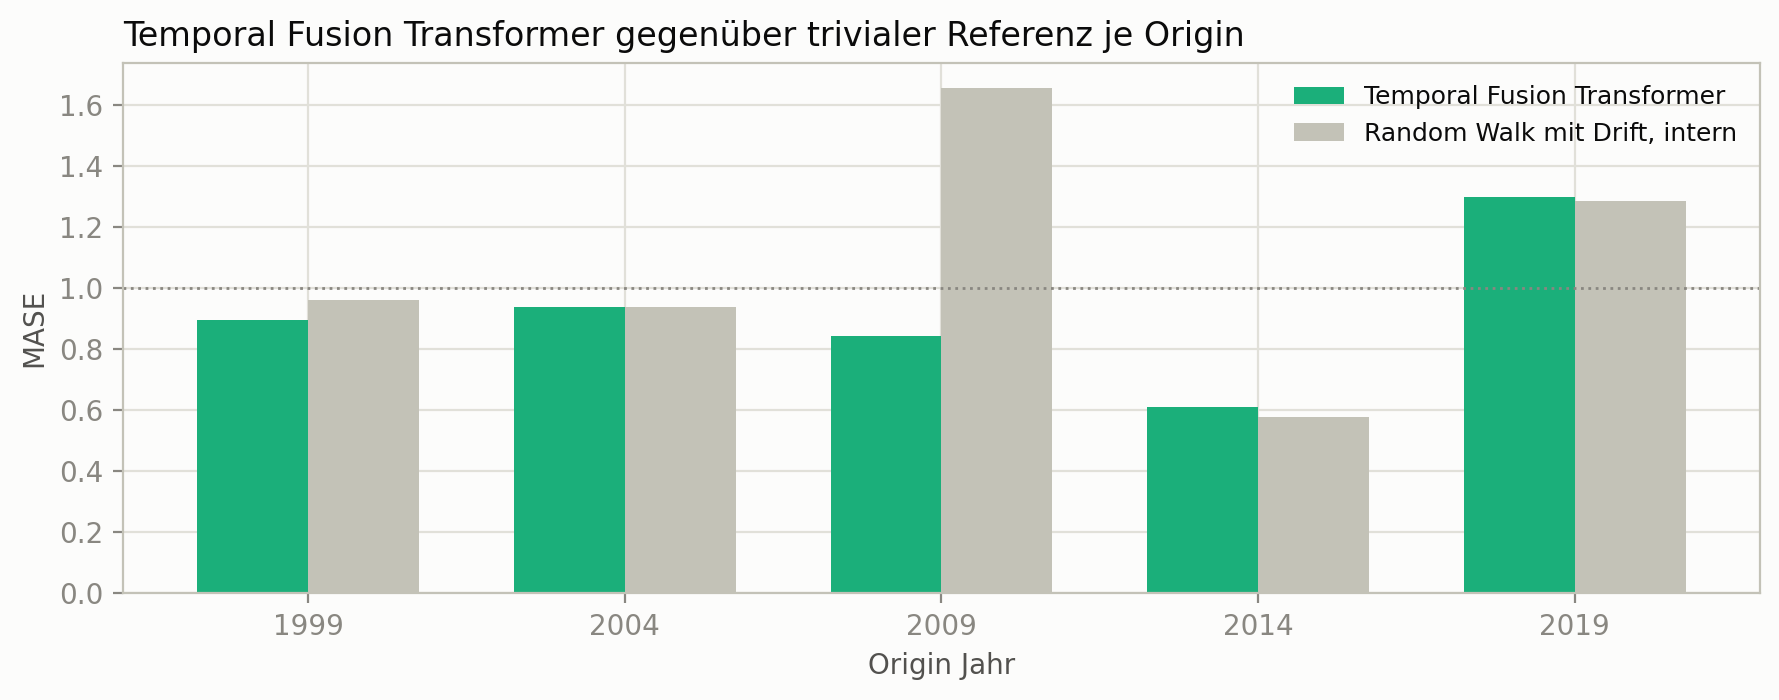

Der Temporal Fusion Transformer schlägt die interne Referenz in 3 von 5 Folds, auf Ebene je eines gemittelten MASE Werts pro Fold
Folds, in denen der Temporal Fusion Transformer nicht besser war [2014, 2019]


In [14]:
tft_by_origin = tft_utils.summarize_by_origin(preds_tft, panel)
comparison = tft_by_origin[["origin_year", "test_years", "MASE"]].merge(
    by_origin_baseline[["origin_year", "MASE"]], on="origin_year",
    suffixes=("_tft", "_baseline"))

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width / 2, comparison["MASE_tft"], width, color=plotting.MODEL_COLORS["tft"],
       label="Temporal Fusion Transformer")
ax.bar(x + width / 2, comparison["MASE_baseline"], width, color=plotting.BASELINE,
       label="Random Walk mit Drift, intern")
ax.axhline(1.0, color=plotting.MUTED, linewidth=1, linestyle=":")
ax.set_xticks(x, comparison["origin_year"].astype(str))
ax.set_xlabel("Origin Jahr")
ax.set_ylabel("MASE")
ax.set_title("Temporal Fusion Transformer gegenüber trivialer Referenz je Origin",
             loc="left", color=plotting.INK)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

n_tft_better = (comparison["MASE_tft"] < comparison["MASE_baseline"]).sum()
print(f"Der Temporal Fusion Transformer schlägt die interne Referenz in "
      f"{n_tft_better} von {len(comparison)} Folds, "
      f"auf Ebene je eines gemittelten MASE Werts pro Fold")
worse = comparison[comparison["MASE_tft"] >= comparison["MASE_baseline"]]
if len(worse):
    print("Folds, in denen der Temporal Fusion Transformer nicht besser war",
          [int(o) for o in worse["origin_year"]])

Der Temporal Fusion Transformer schlägt die interne Referenz in der Mehrheit, aber nicht
in allen fünf Folds. Auf dieser naiven Ebene mit nur fünf Datenpunkten lässt sich daraus
noch nicht verlässlich schließen, ob der Ansatz tatsächlich systematisch besser ist oder
ob die Unterschiede zwischen den Folds im Rahmen des Zufalls liegen. Der folgende
Abschnitt prüft dieselbe Frage deshalb mit einem zur Panelstruktur der Daten passenden
Signifikanztest.

**Statistische Signifikanz des Unterschieds**

Der bekannteste Test für die Frage, ob ein Prognosemodell signifikant genauer ist als ein
anderes, ist der Diebold-Mariano-Test (Diebold und Mariano, 1995, Comparing Predictive
Accuracy, Journal of Business and Economic Statistics, Band 13, Nummer 3). Er wurde für
eine einzelne Zeitreihe gepaarter Verlustdifferenzen entwickelt, mit einer asymptotischen
Herleitung, die auf einer großen Zahl T von Prognosevergleichen einer einzelnen Serie
beruht. Die Hauptdatenquelle dieses Projekts besteht jedoch aus vielen Ländern mit jeweils
nur fünf Origin Folds, einem Querschnitts beziehungsweise Panelproblem statt eines reinen
Zeitreihenproblems, gepoolt über alle 580 Kombinationen aus Land und Origin würde der Test
seine Kernannahme einer gemeinsamen, stationären Fehlerzeitreihe verletzen. \
Die folgende Tabelle stellt die deshalb in diesem Notebook verwendeten Verfahren sowie eine
Alternative aus der Literatur gegenüber:

| Verfahren | Rolle in diesem Notebook | Eignung |
|---|---|---|
| Diebold-Mariano-Test gepoolt über alle 580 Paare | nicht verwendet | verletzt die Annahme einer gemeinsamen, stationären Fehlerzeitreihe bei 116 Ländern mit sehr unterschiedlichen Volatilitätsregimen |
| Gepaarter Wilcoxon Vorzeichen Rang Test (Wilcoxon, 1945, Individual Comparisons by Ranking Methods, Biometrics Bulletin, Band 1, Nummer 6) | primäres Verfahren | behandelt Land und Fold als näherungsweise unabhängige Beobachtungen, robust gegenüber der schiefen MASE Verteilung, 580 statt nur fünf Beobachtungen |
| Diebold-Mariano-Test je Land, mit Kleinstichprobenkorrektur (Harvey, Leybourne und Newbold, 1997, Testing the Equality of Prediction Mean Squared Errors, International Journal of Forecasting, Band 13, Nummer 2), berechnet mit `evaluation.diebold_mariano()` | ergänzendes Verfahren | korrekt anwendbar auf die eigene, 25 Jahre umfassende Fehlerreihe eines einzelnen Landes, aber geringe Power bei nur 25 Beobachtungen je Land |
| Einseitiger Bootstrap Test auf dem 99. Perzentil der Fehlerverteilung (Laborda, Ruano und Zamanillo, 2023, siehe Abschnitt 2.1) | nicht verwendet, siehe Abschnitt 8 | methodisch ebenfalls sauberer, alternativer Weg zum selben Ziel |

Wegen der geringen Power des Diebold-Mariano-Tests bei nur 25 Beobachtungen je Land wird
zusätzlich ausgewertet, bei wie vielen Ländern der Test für sich genommen signifikant
ausfällt, als Ergänzung zum Paneltest. Sowohl der Wilcoxon Test als auch der Bootstrap
Ansatz aus der Literatur vermeiden es, sich allein auf einen einzelnen gemittelten
Fehlerwert zu verlassen, eine Bootstrap Variante wäre eine naheliegende Robustheitsprüfung
für zukünftige Arbeiten an diesem Notebook.

In [15]:
panel_test = tft_utils.paired_mase_test(preds_tft, preds_baseline, panel)
print("Gepaarter Test über alle Kombinationen aus Land und Origin, "
      "MASE des Temporal Fusion Transformers gegenüber der Referenz")
for k, v in panel_test.items():
    label = f"  {k} " + (f"{v:.4g}" if isinstance(v, float) else f"{v}")
    print(label)

richtung = ("Der Temporal Fusion Transformer ist signifikant besser"
            if panel_test["mean_diff"] < 0
            else "Der Temporal Fusion Transformer ist signifikant schlechter")
alpha = 0.05
if panel_test["wilcoxon_p"] < alpha:
    print(f"\nDer Wilcoxon Test ist signifikant bei einem Niveau von {alpha}. "
          f"{richtung} als die interne Referenz, "
          f"mittlere MASE Differenz {panel_test['mean_diff']:+.3f}")
else:
    print(f"\nDer Wilcoxon Test ist bei einem Niveau von {alpha} nicht signifikant. "
          f"Es lässt sich kein belastbarer Unterschied zur internen Referenz nachweisen")

Gepaarter Test über alle Kombinationen aus Land und Origin, MASE des Temporal Fusion Transformers gegenüber der Referenz
  n_pairs 580
  mean_diff -0.1659
  median_diff -0.02045
  wilcoxon_stat 7.072e+04
  wilcoxon_p 0.000805
  ttest_stat -4.847
  ttest_p 1.611e-06

Der Wilcoxon Test ist signifikant bei einem Niveau von 0.05. Der Temporal Fusion Transformer ist signifikant besser als die interne Referenz, mittlere MASE Differenz -0.166


Länder mit auswertbarem Diebold Mariano Test 116 von 116


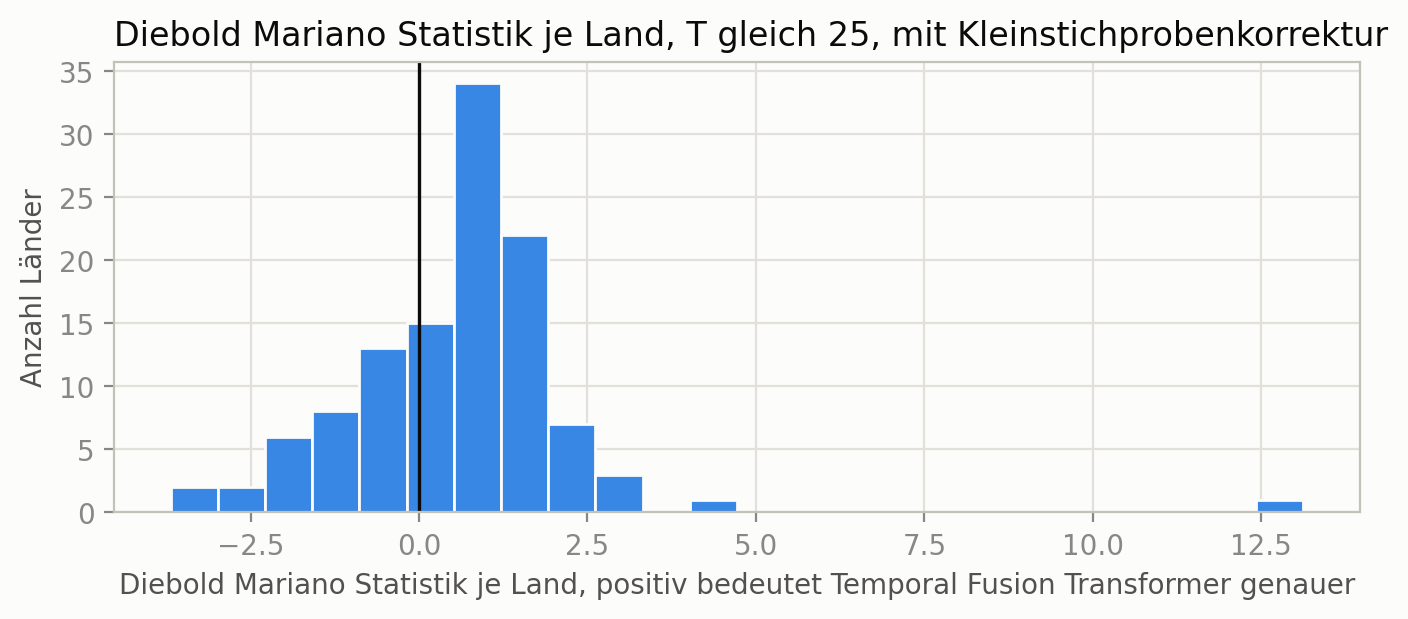

Davon signifikant bei einem Niveau von 0,05 15 entsprechend 12.9%
  Temporal Fusion Transformer signifikant genauer bei 9 Ländern
  Temporal Fusion Transformer signifikant ungenauer bei 6 Ländern


In [16]:
# Je Land ergeben sich HORIZON Beobachtungen pro Origin. Im Testmodus stehen weniger
# Origins zur Verfuegung, daher wird die Mindestanzahl entsprechend abgesenkt.
_min_obs = min(15, 2 * config.HORIZON)
dm_per_country = tft_utils.diebold_mariano_per_country(preds_baseline, preds_tft, min_obs=_min_obs)

print(f"Länder mit auswertbarem Diebold Mariano Test "
      f"{len(dm_per_country)} von {panel['country'].nunique()}")
if len(dm_per_country):
    n_sig = (dm_per_country["dm_p"] < 0.05).sum()
    n_sig_tft_better = ((dm_per_country["dm_p"] < 0.05) & (dm_per_country["dm_stat"] > 0)).sum()
    n_sig_tft_worse = ((dm_per_country["dm_p"] < 0.05) & (dm_per_country["dm_stat"] < 0)).sum()

    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hist(dm_per_country["dm_stat"].dropna(), bins=24, color=plotting.SEQ_BLUES[3],
            edgecolor=plotting.SURFACE)
    ax.axvline(0, color=plotting.INK, linewidth=1.2)
    ax.set_xlabel("Diebold Mariano Statistik je Land, positiv bedeutet Temporal Fusion Transformer genauer")
    ax.set_ylabel("Anzahl Länder")
    ax.set_title(f"Diebold Mariano Statistik je Land, T gleich {dm_per_country['n_obs'].iloc[0]}, "
                 f"mit Kleinstichprobenkorrektur", loc="left", color=plotting.INK)
    fig.tight_layout()
    plt.show()

    print(f"Davon signifikant bei einem Niveau von 0,05 "
          f"{n_sig} entsprechend {n_sig / len(dm_per_country):.1%}")
    print(f"  Temporal Fusion Transformer signifikant genauer bei {n_sig_tft_better} Ländern")
    print(f"  Temporal Fusion Transformer signifikant ungenauer bei {n_sig_tft_worse} Ländern")
else:
    print("Zu wenige Beobachtungen je Land für einen Diebold Mariano Test in diesem Durchlauf")

Der Diebold-Mariano-Test ist je Land bei nur 25 Beobachtungen naturgemäß schwach
gepowert. Die meisten Länder werden für sich genommen nicht signifikant sein, selbst wenn
der Temporal Fusion Transformer im Mittel etwas genauer ist. Aus diesem Grund ist der
Paneltest über alle 580 Paare der methodisch überzeugendere Beleg. Er bündelt dieselbe
Information über wesentlich mehr Beobachtungen und gewinnt dadurch an Power, die dem
Test je einzelnem Land fehlt. Fällt die Mehrheit der signifikanten Einzelländer Tests in
dieselbe Richtung wie der Paneltest, stützt dies dessen Ergebnis zusätzlich.

Die naive Betrachtung je Origin weiter oben in diesem Abschnitt mit nur fünf Datenpunkten
und der Test auf Ebene der Kombinationen aus Land und Origin mit 580 Datenpunkten können
zu unterschiedlichen Eindrücken führen. Das ist kein Widerspruch, sondern zeigt die
Gefahr, Schlüsse aus zu stark aggregierten Daten zu ziehen. Wenige Origins mit besonders
extremen Fehlern der Referenz, etwa durch den Driftterm bei volatilen Ländern, können den
Mittelwert eines Origins verschieben, ohne dass sich am Bild auf Länderebene viel ändert.
Für die Kernfrage, ob der Temporal Fusion Transformer über das Panel hinweg statistisch
besser ist, liefert der Paneltest die belastbarere Antwort.

### 6.2 Prognosegüte nach Origin, Prognoseschritt und Ländergruppe

Die in Abschnitt 6.1 nachgewiesene statistische Überlegenheit ist ein Mittelwert über das
gesamte Panel. Die folgenden drei Blickwinkel prüfen, wie gleichmäßig sich diese
Überlegenheit über die Zeit, den Prognosehorizont und verschiedene Ländergruppen verteilt,
und wo systematische Schwächen liegen.

**Güte je Backtest Origin**

In [17]:
by_origin = tft_by_origin
by_origin

,origin_year,test_years,MASE,RMSE,MAE,pinball_q10,pinball_q90,coverage_80,n_forecasts
0,1999,2000 bis 2004,0.896157,5.440955,3.513478,0.975891,0.969138,0.815517,580
1,2004,2005 bis 2009,0.936474,4.728007,3.356175,1.031862,0.842362,0.637931,580
2,2009,2010 bis 2014,0.843773,6.115374,3.199679,1.002203,0.817099,0.627586,580
3,2014,2015 bis 2019,0.611335,3.545505,2.230240,0.669336,0.655756,0.803448,580
4,2019,2020 bis 2024,1.299343,7.230917,4.319659,1.713179,1.174951,0.487931,580


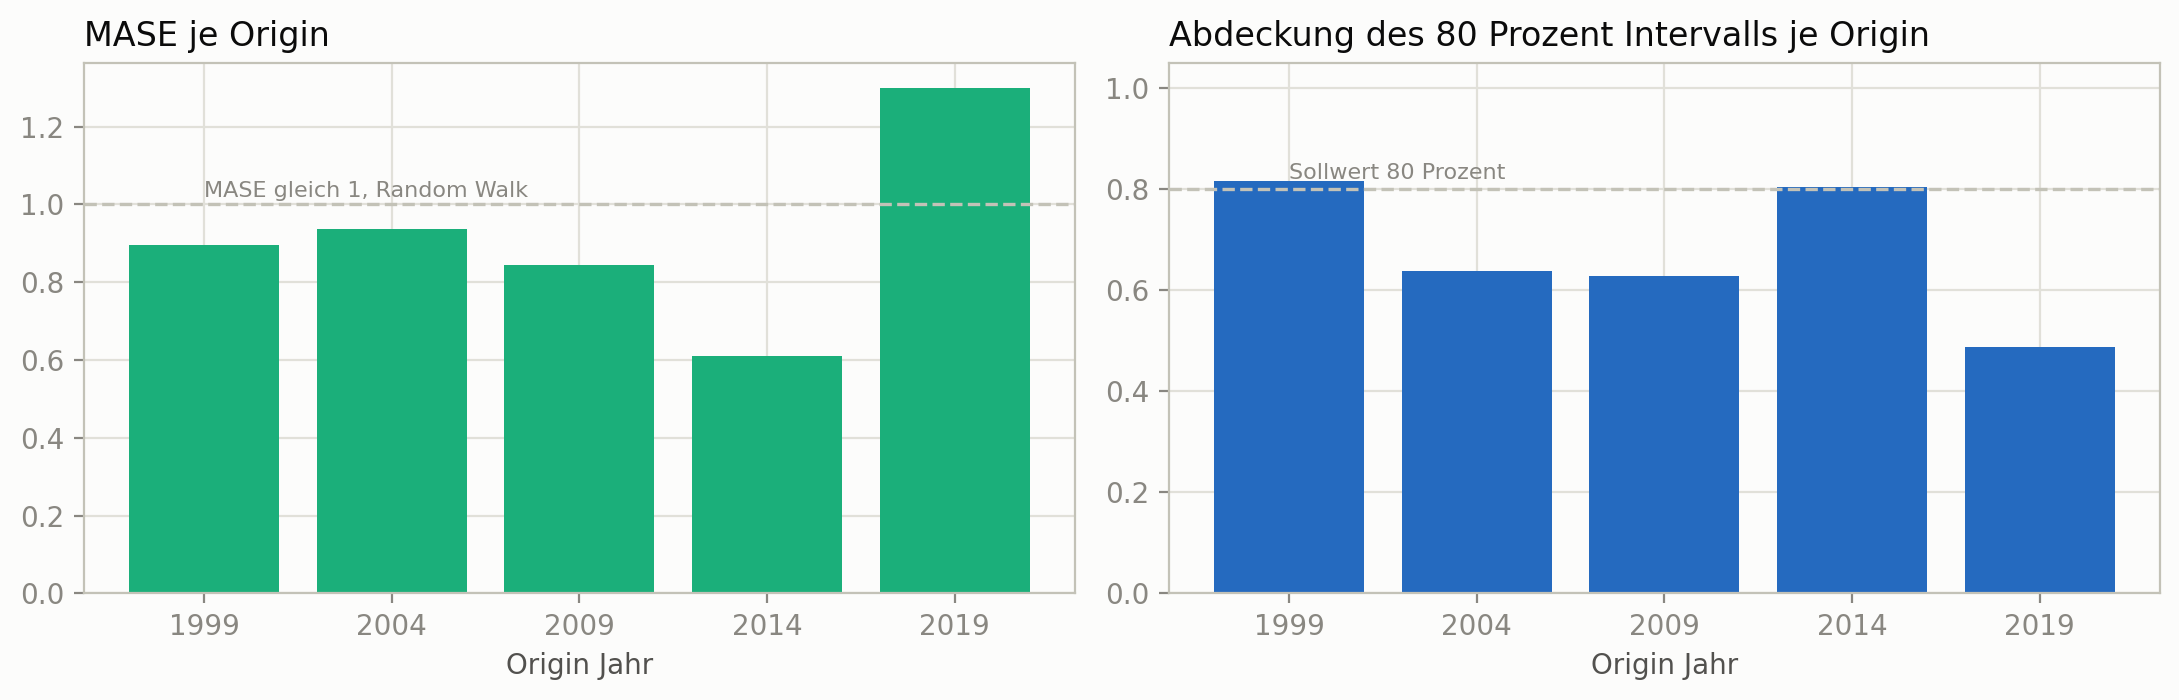

Finaler Holdout mit Origin 2019, Testfenster 2020 bis 2024, enthält das Jahr 2020 mit der COVID Pandemie, MASE 1.299, Abdeckung 48.8%
Bester Fold ist Origin 2014 mit MASE 0.611
Mittlere Abdeckung des 80 Prozent Intervalls über alle Folds 67.4%, das liegt unter dem Sollwert von 80 Prozent


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(by_origin["origin_year"].astype(str), by_origin["MASE"],
            color=plotting.MODEL_COLORS["tft"])
axes[0].axhline(1.0, color=plotting.BASELINE, linewidth=1.2, linestyle="--")
axes[0].annotate("MASE gleich 1, Random Walk", (0, 1.02), fontsize=8, color=plotting.MUTED)
axes[0].set_title("MASE je Origin", loc="left", color=plotting.INK)
axes[0].set_xlabel("Origin Jahr")

axes[1].bar(by_origin["origin_year"].astype(str), by_origin["coverage_80"],
            color=plotting.SEQ_BLUES[4])
axes[1].axhline(0.8, color=plotting.BASELINE, linewidth=1.2, linestyle="--")
axes[1].annotate("Sollwert 80 Prozent", (0, 0.82), fontsize=8, color=plotting.MUTED)
axes[1].set_title("Abdeckung des 80 Prozent Intervalls je Origin", loc="left", color=plotting.INK)
axes[1].set_xlabel("Origin Jahr")
axes[1].set_ylim(0, 1.05)
fig.tight_layout()
plt.savefig("TFT_MASE_plot.png", dpi=300, bbox_inches="tight")
plt.show()

covid_row = by_origin[by_origin["origin_year"] == config.FINAL_ORIGIN].iloc[0]
best_row = by_origin.loc[by_origin["MASE"].idxmin()]
mean_coverage = by_origin["coverage_80"].mean()
print(f"Finaler Holdout mit Origin {config.FINAL_ORIGIN}, Testfenster {covid_row['test_years']}, "
      f"enthält das Jahr 2020 mit der COVID Pandemie, MASE {covid_row['MASE']:.3f}, "
      f"Abdeckung {covid_row['coverage_80']:.1%}")
print(f"Bester Fold ist Origin {int(best_row['origin_year'])} mit MASE {best_row['MASE']:.3f}")
print(f"Mittlere Abdeckung des 80 Prozent Intervalls über alle Folds {mean_coverage:.1%}, "
      f"das liegt {'unter' if mean_coverage < 0.8 else 'über'} dem Sollwert von 80 Prozent")

**Warum ist der COVID Fold am schwächsten?** \
Der finale Holdout Fold mit Testfenster von
2020 bis 2024 und dem COVID Jahr 2020 ist in aller Regel der mit Abstand schwächste Fold.
Das ist genau das Szenario, das Notebook 01 als bewusst harter Test für die
Unsicherheitsintervalle vorgesehen hat. Dies ist keine Schwäche der Implementierung,
sondern die erwartbare Grenze jedes Modells, das `is_global_crisis` für die Zukunft
korrekt auf 0 setzt (siehe Abschnitt 3.2). Ein Schock, der zum Prognosezeitpunkt nicht
absehbar war, kann per Definition nicht getroffen werden.

**Einordnung der Unterdeckung** \
Liegt die oben ausgegebene mittlere Abdeckung des 80
Prozent Intervalls spürbar unter 80 Prozent, ist das Modell systematisch überkonfident,
das heißt die Bänder zwischen q10 und q90 sind zu schmal, und zwar nicht nur im COVID
Fold (siehe dazu auch die formale Quantilskalibrierung in Abschnitt 6.4). Dieses Ergebnis
fügt sich in einen breiter dokumentierten Zusammenhang der Prognoseliteratur ein. Studien
zur Treffsicherheit professioneller Konjunkturprognosen, unter anderem von Ökonominnen
und Ökonomen des Internationalen Währungsfonds, zeigen wiederholt, dass Rezessionen im
Voraus so gut wie nie zuverlässig vorhergesagt werden. Das vorliegende Ergebnis ist somit
kein Spezifikum des Temporal Fusion Transformers, sondern spiegelt eine bekannte, breit
dokumentierte Grenze von Konjunkturprognosen im Allgemeinen. Die Genauigkeit sollte daher
nicht ohne diesen Kontext bewertet werden.

**Güte je Prognoseschritt**

Die naive Erwartung lautet, dass der Fehler mit wachsendem Horizont monoton steigt, weil
ein Zeitpunkt weiter in der Zukunft grundsätzlich schwerer zu treffen ist. Bei einem
gepoolten Backtest über sehr unterschiedliche Origin Jahre, die sowohl ruhige Perioden als
auch die globale Finanzkrise und die COVID Pandemie umfassen, muss sich dieses Muster
jedoch nicht sauber zeigen. Ein einzelner besonders harter erster Schritt, etwa der
Einbruch unmittelbar nach dem Origin 2019, kann den kurzen Horizont teurer machen als
mittlere Horizonte. Die folgende Auswertung zeigt, ob dieser Effekt hier auftritt.

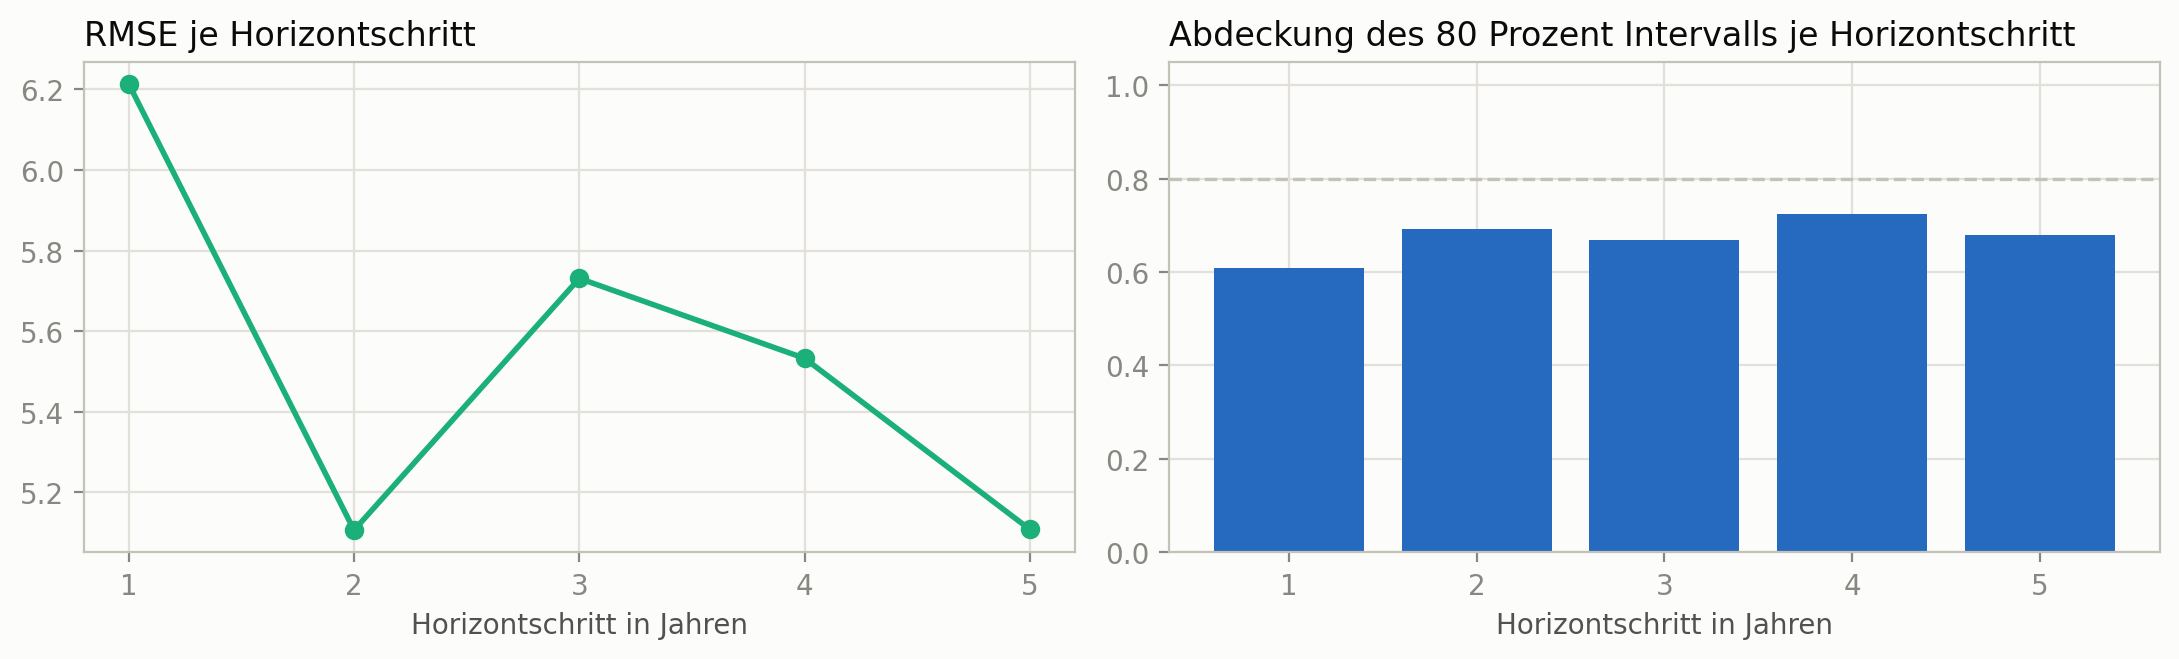

RMSE steigt streng monoton mit dem Horizont False
Der höchste Fehler liegt bei Horizontschritt 1 statt beim größten Horizont, vermutlich weil einzelne harte Krisenfolds im gepoolten Ergebnis dominieren, siehe weiter oben in diesem Abschnitt sowie Abschnitt 6.3


,h,RMSE,MAE,coverage_80,n_forecasts
0,1,6.213706,3.887205,0.608621,580
1,2,5.105649,3.222473,0.691379,580
2,3,5.730821,3.217179,0.668966,580
3,4,5.532378,3.040978,0.724138,580
4,5,5.107377,3.251397,0.679310,580


In [19]:
by_h = tft_utils.summarize_by_horizon(preds_tft)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(by_h["h"], by_h["RMSE"], marker="o", color=plotting.MODEL_COLORS["tft"])
axes[0].set_title("RMSE je Horizontschritt", loc="left", color=plotting.INK)
axes[0].set_xlabel("Horizontschritt in Jahren")
axes[0].set_xticks(by_h["h"])

axes[1].bar(by_h["h"].astype(str), by_h["coverage_80"], color=plotting.SEQ_BLUES[4])
axes[1].axhline(0.8, color=plotting.BASELINE, linewidth=1.2, linestyle="--")
axes[1].set_title("Abdeckung des 80 Prozent Intervalls je Horizontschritt", loc="left", color=plotting.INK)
axes[1].set_xlabel("Horizontschritt in Jahren")
axes[1].set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

monotone_increasing = (by_h["RMSE"].diff().dropna() >= 0).all()
print(f"RMSE steigt streng monoton mit dem Horizont {monotone_increasing}")
if not monotone_increasing:
    worst_h = int(by_h.loc[by_h["RMSE"].idxmax(), "h"])
    print(f"Der höchste Fehler liegt bei Horizontschritt {worst_h} statt beim größten Horizont, "
          f"vermutlich weil einzelne harte Krisenfolds im gepoolten Ergebnis dominieren, "
          f"siehe weiter oben in diesem Abschnitt sowie Abschnitt 6.3")
by_h

**Güte je Ländergruppe**

Passend zur explorativen Analyse aus Notebook 01 zur Volatilität nach Einkommensgruppe
stellt sich die Frage, ob das globale Modell für alle Einkommensgruppen und Regionen
ähnlich gut funktioniert oder ob systematische Schwächen bestehen, etwa bei Ländern mit
kürzerer oder lückenhafterer Historie.

Für die Interpretation ist wichtig, dass MASE jedes Land mit seinem eigenen naiven In
Sample Fehler skaliert, ein niedrigerer MASE bedeutet daher nicht in jedem Fall dasselbe:
- bei einer volatilen, oft ärmeren Ländergruppe bedeutet ein niedriger MASE nicht
zwingend eine niedrigere absolute Prognoseungenauigkeit, sondern einen größeren relativen
Vorsprung gegenüber der dort leicht zu schlagenden naiven Prognose für den nächsten
Zeitschritt
- reiche, konjunkturell glatte Volkswirtschaften haben umgekehrt bereits einen sehr guten
naiven Referenzwert, den zu unterbieten strukturell schwerer ist, selbst wenn der
Temporal Fusion Transformer dort absolut genauer prognostiziert

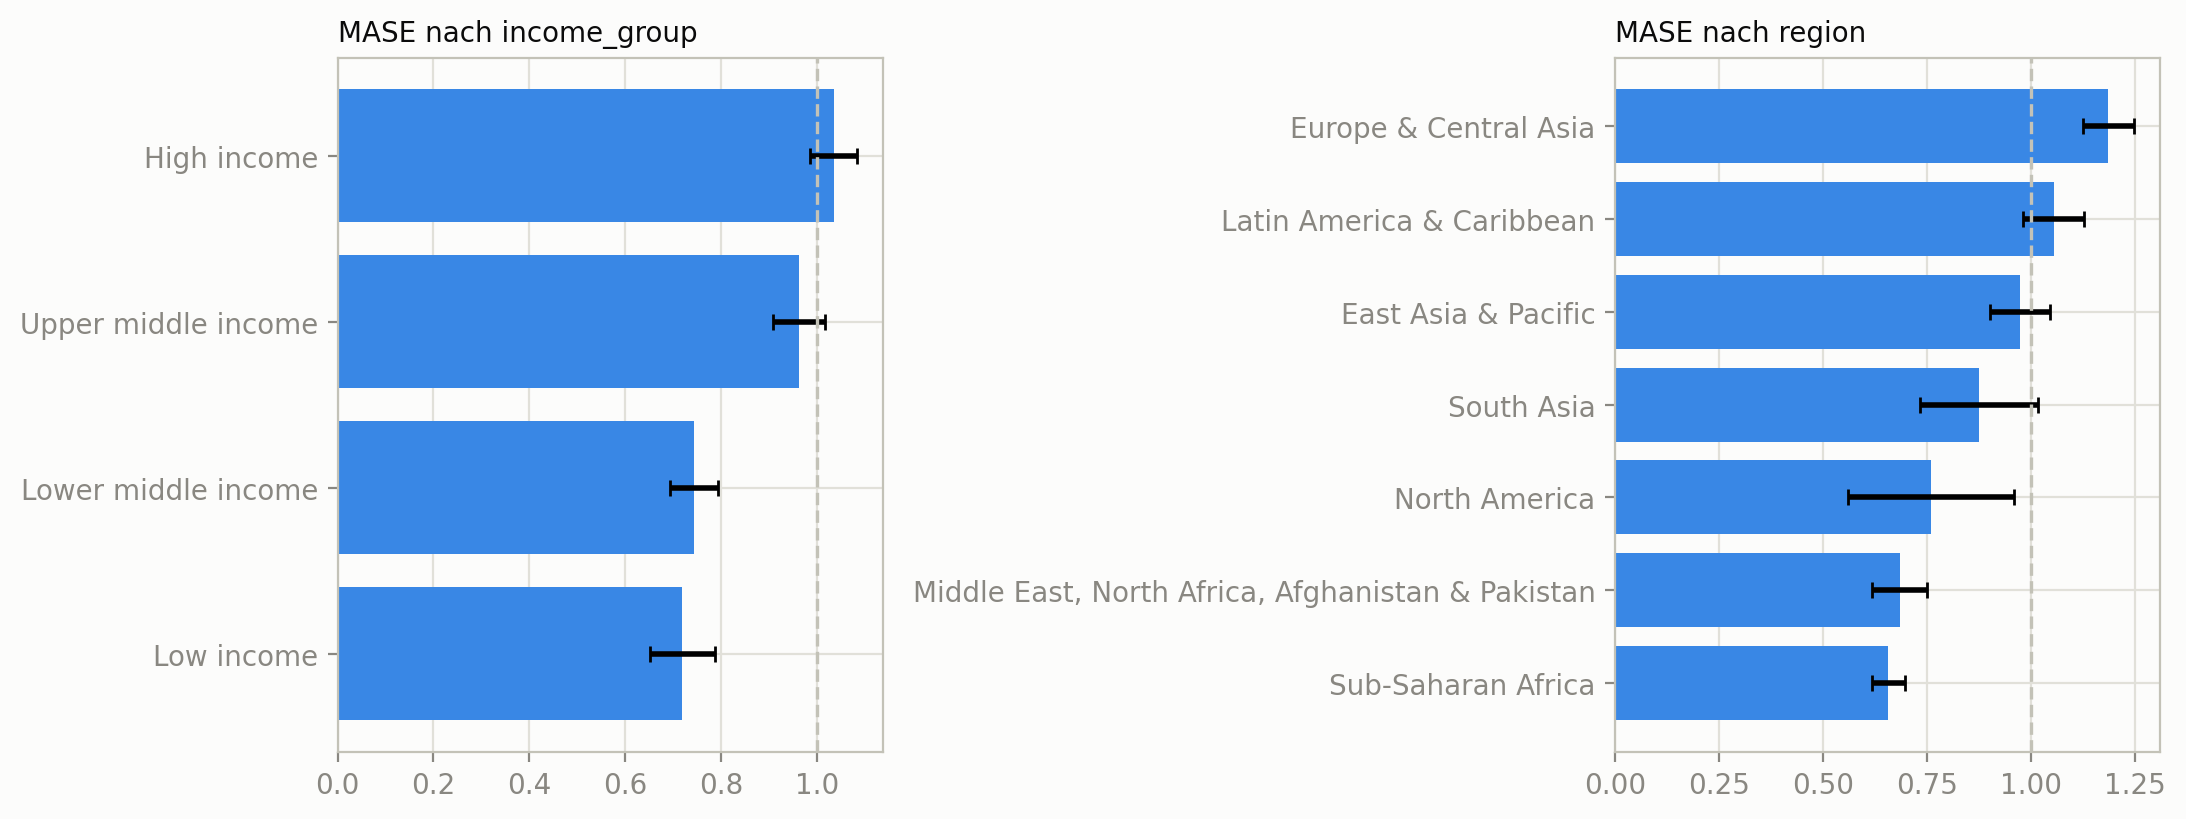

Beste Einkommensgruppe Low income, MASE 0.719
Schwächste Einkommensgruppe High income, MASE 1.035


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
by_group_results = {}
for ax, col in zip(axes, ["income_group", "region"]):
    by_group = tft_utils.summarize_by_group(preds_tft, panel, static, col)
    by_group_results[col] = by_group
    ax.barh(by_group[col], by_group["MASE_mean"], color=plotting.SEQ_BLUES[3],
            xerr=by_group["MASE_std"] / by_group["n_folds"] ** 0.5, capsize=3)
    ax.axvline(1.0, color=plotting.BASELINE, linewidth=1.2, linestyle="--")
    ax.set_title(f"MASE nach {col}", loc="left", color=plotting.INK, fontsize=10)
fig.tight_layout()
plt.show()

best_income = by_group_results["income_group"].iloc[0]
worst_income = by_group_results["income_group"].iloc[-1]
print(f"Beste Einkommensgruppe {best_income['income_group']}, "
      f"MASE {best_income['MASE_mean']:.3f}")
print(f"Schwächste Einkommensgruppe {worst_income['income_group']}, "
      f"MASE {worst_income['MASE_mean']:.3f}")

### 6.3 Prognose gegenüber tatsächlichem Verlauf für ausgewählte Länder

Betrachtet werden ein reiches, konjunkturell stabiles Land, ein Land mit mittlerem
Einkommen und eigenständiger konjunktureller Dynamik sowie Deutschland als Referenz,
jeweils im finalen Holdout Fold mit Origin 2019 und Testfenster einschließlich des COVID
Jahres 2020. Von besonderem
Interesse ist, wie das Band zwischen q10 und q90 auf den COVID Einbruch reagiert,
beziehungsweise nicht reagieren kann, da `is_global_crisis` für 2020 auf 0 maskiert ist
(siehe Abschnitt 3.2).

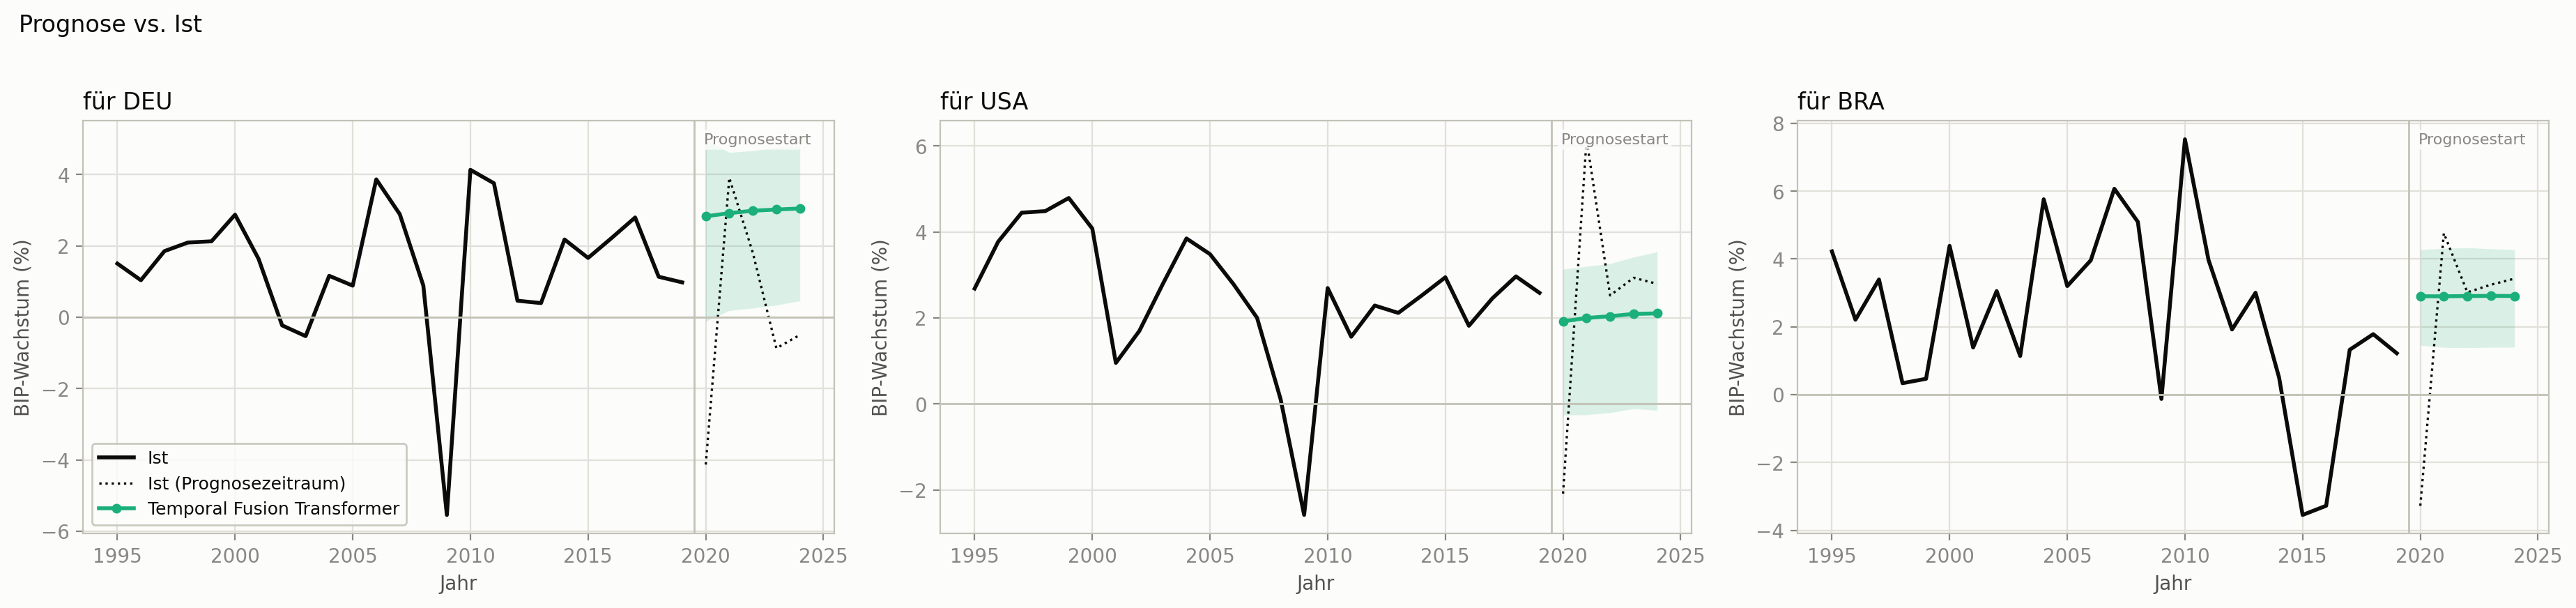

In [21]:
example_countries = [c for c in ["DEU", "USA", "BRA"] if c in preds_tft["country"].unique()]
final_preds = preds_tft[preds_tft["origin_year"] == config.FINAL_ORIGIN]
train_final, _ = data_utils.train_test_split(panel, config.FINAL_ORIGIN)

fig, axes = plt.subplots(1, len(example_countries), figsize=(6.2 * len(example_countries), 4.4))
for i, (ax, c) in enumerate(zip(axes, example_countries)):
    plotting.plot_forecast(train_final, final_preds, country=c, models=["tft"],
                            ax=ax, show_legend=(i == 0), title=f"für {c}")
fig.suptitle("Prognose vs. Ist", x=0.01, ha="left", color=plotting.INK)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In den Diagrammen oben verläuft die Punktprognose des Temporal Fusion Transformers über
alle fünf Jahre des Prognosehorizonts auffällig flach, während der tatsächliche Verlauf
stark schwankt und im Fall Deutschlands und der Vereinigten Staaten deutlich einbricht.
Dieser optische Eindruck wird im Folgenden quantifiziert, statt ihn nur zu beschreiben.
Für jede Kombination aus Land und Origin Jahr wird die Spannweite der Punktprognose über
den Horizont, also der Unterschied zwischen dem größten und dem kleinsten prognostizierten
Wert, mit der Spannweite des tatsächlichen Verlaufs über denselben Horizont verglichen.

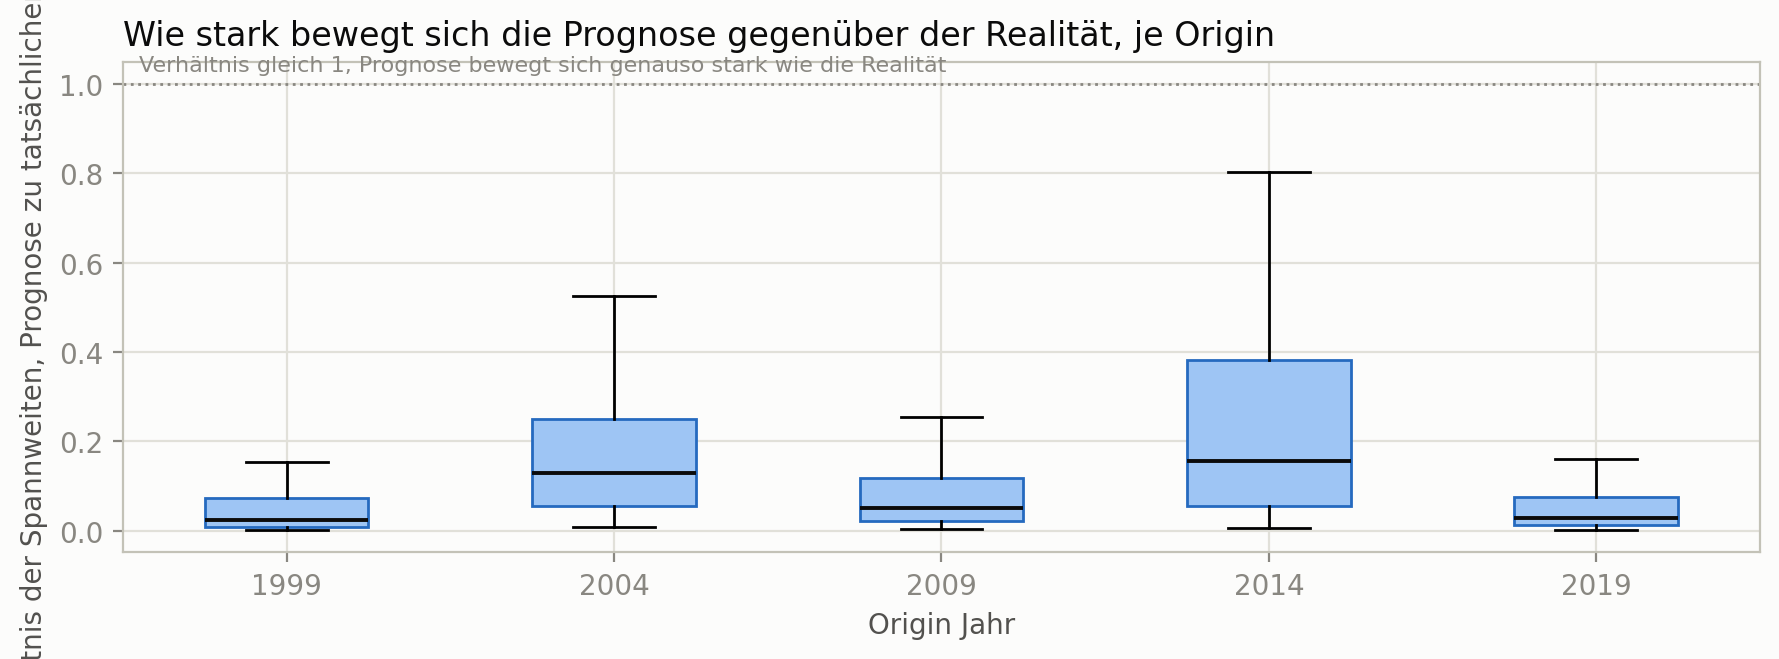

Median des Verhältnisses über alle Folds 0.061
Anteil der Kombinationen aus Land und Origin, bei denen sich die Prognose auf weniger als ein Fünftel der tatsächlichen Schwankungsbreite bewegt 79.5%
Median des Verhältnisses im finalen Holdout Fold 0.028


In [22]:
dispersion = tft_utils.forecast_dispersion(preds_tft)

fig, ax = plt.subplots(figsize=(9, 3.4))
origins_sorted = sorted(dispersion["origin_year"].unique())
data_by_origin = [dispersion.loc[dispersion["origin_year"] == o, "ratio"].dropna()
                  for o in origins_sorted]
bp = ax.boxplot(data_by_origin, tick_labels=[str(o) for o in origins_sorted],
                patch_artist=True, showfliers=False, widths=0.5,
                medianprops={"color": plotting.INK, "linewidth": 1.4})
for box in bp["boxes"]:
    box.set(facecolor=plotting.SEQ_BLUES[1], edgecolor=plotting.SEQ_BLUES[4])
ax.axhline(1.0, color=plotting.MUTED, linewidth=1, linestyle=":")
ax.annotate("Verhältnis gleich 1, Prognose bewegt sich genauso stark wie die Realität",
            (0.55, 1.03), fontsize=8, color=plotting.MUTED)
ax.set_ylabel("Verhältnis der Spannweiten, Prognose zu tatsächlichem Verlauf")
ax.set_xlabel("Origin Jahr")
ax.set_title("Wie stark bewegt sich die Prognose gegenüber der Realität, je Origin",
             loc="left", color=plotting.INK)
fig.tight_layout()
plt.show()

median_ratio = dispersion["ratio"].median()
share_below_fifth = (dispersion["ratio"] < 0.2).mean()
final_median = dispersion.loc[dispersion["origin_year"] == config.FINAL_ORIGIN, "ratio"].median()
print(f"Median des Verhältnisses über alle Folds {median_ratio:.3f}")
print(f"Anteil der Kombinationen aus Land und Origin, bei denen sich die Prognose auf "
      f"weniger als ein Fünftel der tatsächlichen Schwankungsbreite bewegt "
      f"{share_below_fifth:.1%}")
print(f"Median des Verhältnisses im finalen Holdout Fold {final_median:.3f}")

Der Median liegt deutlich unter 1 in jedem einzelnen Fold, nicht nur im COVID Fold. Die
Punktprognose des Temporal Fusion Transformers bewegt sich über den fünfjährigen Horizont
also durchgehend deutlich weniger als der tatsächliche Verlauf, am stärksten ausgeprägt
im finalen Holdout Fold, in dem die tatsächliche Schwankungsbreite durch die COVID
Pandemie besonders groß ausfällt, während sich die Prognose kaum bewegt. Das bestätigt den
optischen Eindruck aus den Diagrammen oben mit einer Kennzahl und zeigt, dass es sich
nicht um eine Besonderheit einzelner Länder, sondern um ein durchgängiges Verhalten des
Modells handelt.

Dieses Verhalten ist aus zwei Blickwinkeln zu bewerten:
- Aus statistischer Sicht: \
Die explorative Analyse aus Notebook 01
zeigt eine geringe Eigendynamik der Zielgröße (siehe Abschnitt 1), sodass ein Modell ohne
verlässliches Signal für einen bevorstehenden Umbruch sich in Richtung
eines für das jeweilige Land typischen Werts bewegt, statt eine ungerechtfertigt
selbstbewusste, stark schwankende Prognose abzugeben.
- Aus Sicht der praktischen Verwendbarkeit für eine Haushalts oder Investitionsplanung,
dem eingangs definierten Geschäftsfall: \
Eine über fünf Jahre nahezu unveränderte Punktprognose ist wenig
hilfreich, um Jahr für Jahr unterschiedliche Entscheidungen zu treffen. In Kombination mit
der in Abschnitt 6.2 gezeigten Unterdeckung der Quantile ergibt sich ein konsistentes
Gesamtbild. Weder die Punktprognose noch das Unsicherheitsband erfassen die tatsächliche
Schwankungsbreite vollständig, wobei das Unsicherheitsband wenigstens in die richtige
Richtung wächst, während die Punktprognose nahezu konstant bleibt.

**Vergleich mit einem Origin Jahr ohne globalen Schock**

Die drei Beispiele oben stammen alle aus dem finalen Holdout Fold mit Origin 2019, dessen
Testfenster den COVID Einbruch 2020 einschließt. Naheliegend ist die Frage, ob dieselben
drei Länder in einem Fold ohne einen vergleichbar großen globalen Schock im Testfenster
treffsicherer prognostiziert werden. Dafür eignet sich der Fold mit Origin 2014, dessen
Testfenster die Jahre 2015 bis 2019 umfasst und in der explorativen Analyse aus Notebook 01
keinen vergleichbaren weltweiten Einbruch zeigt.

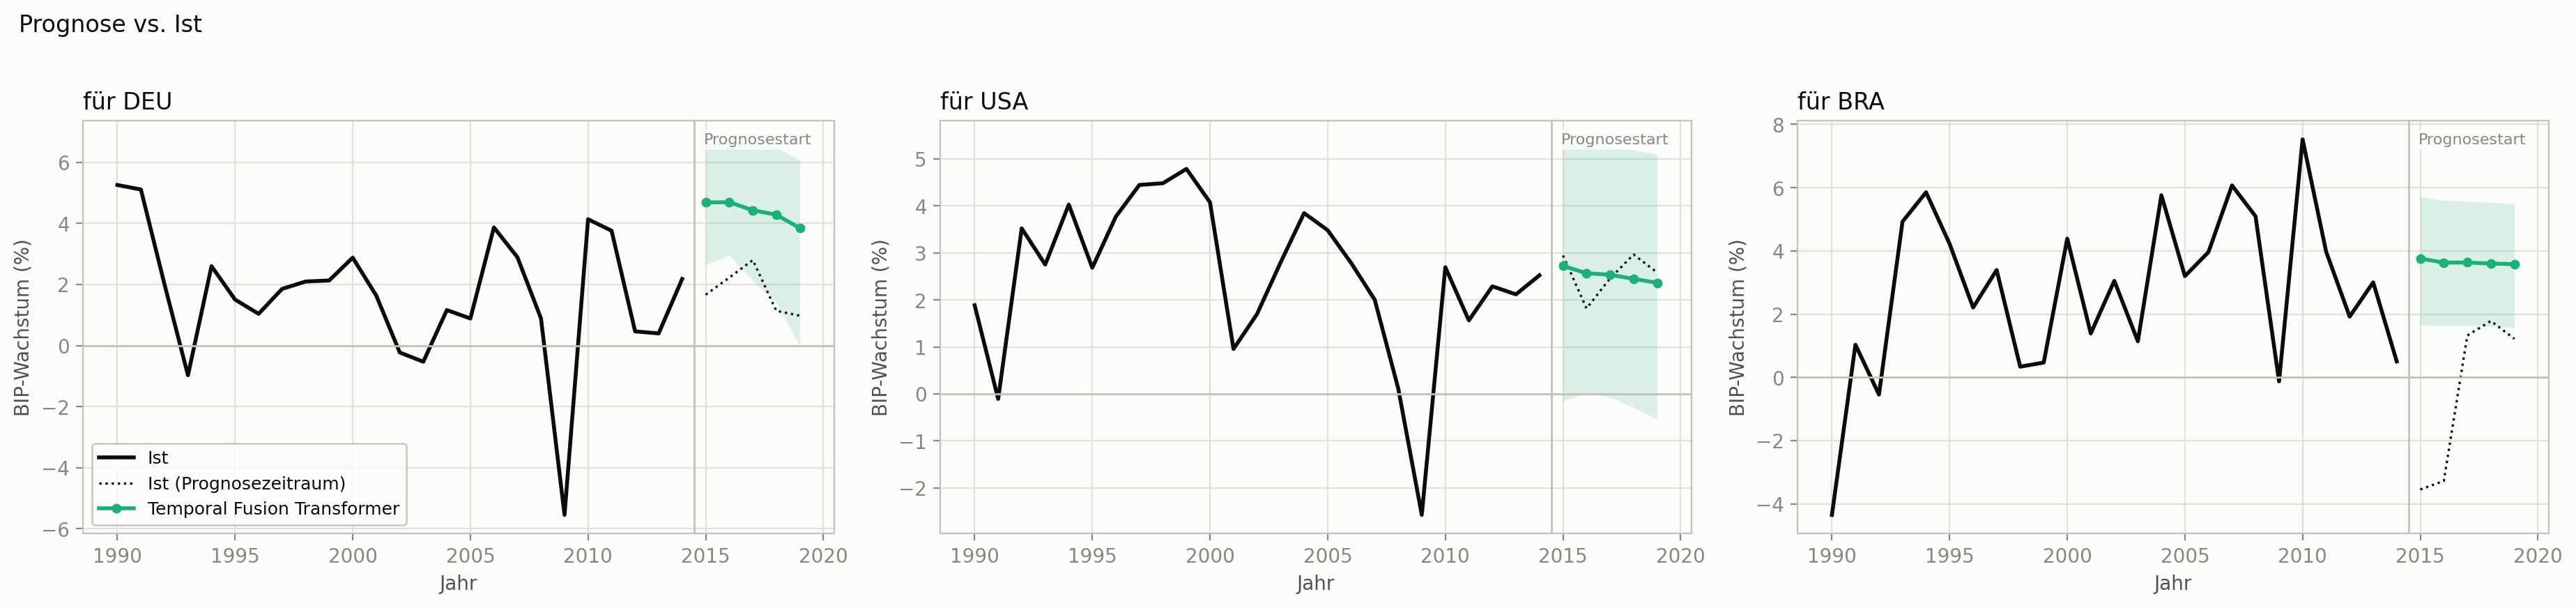

Land, MASE Origin 2014, MASE Origin 2019
DEU, 1.385, 1.848
USA, 0.193, 1.161
BRA, 1.297, 0.582

Gemittelter MASE über alle Länder, Origin 2014 0.611, Origin 2019 1.299


In [23]:
train_2014, _ = data_utils.train_test_split(panel, 2014)
preds_2014 = preds_tft[preds_tft["origin_year"] == 2014]

fig, axes = plt.subplots(1, len(example_countries), figsize=(6.2 * len(example_countries), 4.4))
for i, (ax, c) in enumerate(zip(axes, example_countries)):
    plotting.plot_forecast(train_2014, preds_2014, country=c, models=["tft"],
                            ax=ax, show_legend=(i == 0), title=f"für {c}")
fig.suptitle("Prognose vs. Ist", x=0.01, ha="left", color=plotting.INK)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

scored_by_country = tft_utils.compute_row_mase(preds_tft, panel).drop_duplicates(
    ["country", "origin_year"]).set_index(["country", "origin_year"])["MASE"]
origin_mase = tft_by_origin.set_index("origin_year")["MASE"]

def _fmt(value):
    return f"{value:.3f}" if value is not None else "keine Daten in diesem Lauf"

print("Land, MASE Origin 2014, MASE Origin 2019")
for c in example_countries:
    m2014 = scored_by_country.get((c, 2014))
    m2019 = scored_by_country.get((c, config.FINAL_ORIGIN))
    print(f"{c}, {_fmt(m2014)}, {_fmt(m2019)}")

if 2014 in origin_mase.index and config.FINAL_ORIGIN in origin_mase.index:
    print(f"\nGemittelter MASE über alle Länder, Origin 2014 {origin_mase.loc[2014]:.3f}, "
          f"Origin {config.FINAL_ORIGIN} {origin_mase.loc[config.FINAL_ORIGIN]:.3f}")

Über das gesamte Panel gemittelt fällt der MASE im Fold ohne globalen Schock spürbar
niedriger aus als im finalen, COVID geprägten Holdout Fold (siehe die oben ausgegebenen
Werte sowie bereits Abschnitt 6.1). Auf Ebene der drei Beispielländer zeigt sich dasselbe
Bild jedoch nicht einheitlich. Für die Vereinigten Staaten und, etwas schwächer
ausgeprägt, für Deutschland fällt der MASE im Fold mit Origin 2014 niedriger aus als im
finalen Holdout Fold. Für Brasilien gilt das Gegenteil, dort liefert ausgerechnet der
COVID Fold den niedrigeren MASE. Die Prognosegüte hängt weniger vom Kalenderjahr des
Testfensters als vom Auftreten eines länderspezifischen, unvorhergesehenen Umbruchs
innerhalb dieses Fensters ab. Das Fehlen eines global synchronen Schocks wie COVID
verbessert die durchschnittliche Prognosegüte über das gesamte Panel,
schützt ein einzelnes Land aber nicht zuverlässig vor
einem eigenen, unabhängigen Einbruch im jeweiligen Testfenster.

Die drei Länder oben wurden bewusst nicht nach Prognosegüte ausgewählt, sondern weil sie
bereits aus dem COVID Beispiel bekannt sind und damit einen direkten Vergleich erlauben.
Wie gut die Prognose in diesem ruhigeren Fold tatsächlich aussehen kann, zeigen
stattdessen die drei Länder mit dem niedrigsten MASE unter allen 116 Ländern für genau
diesen Origin.

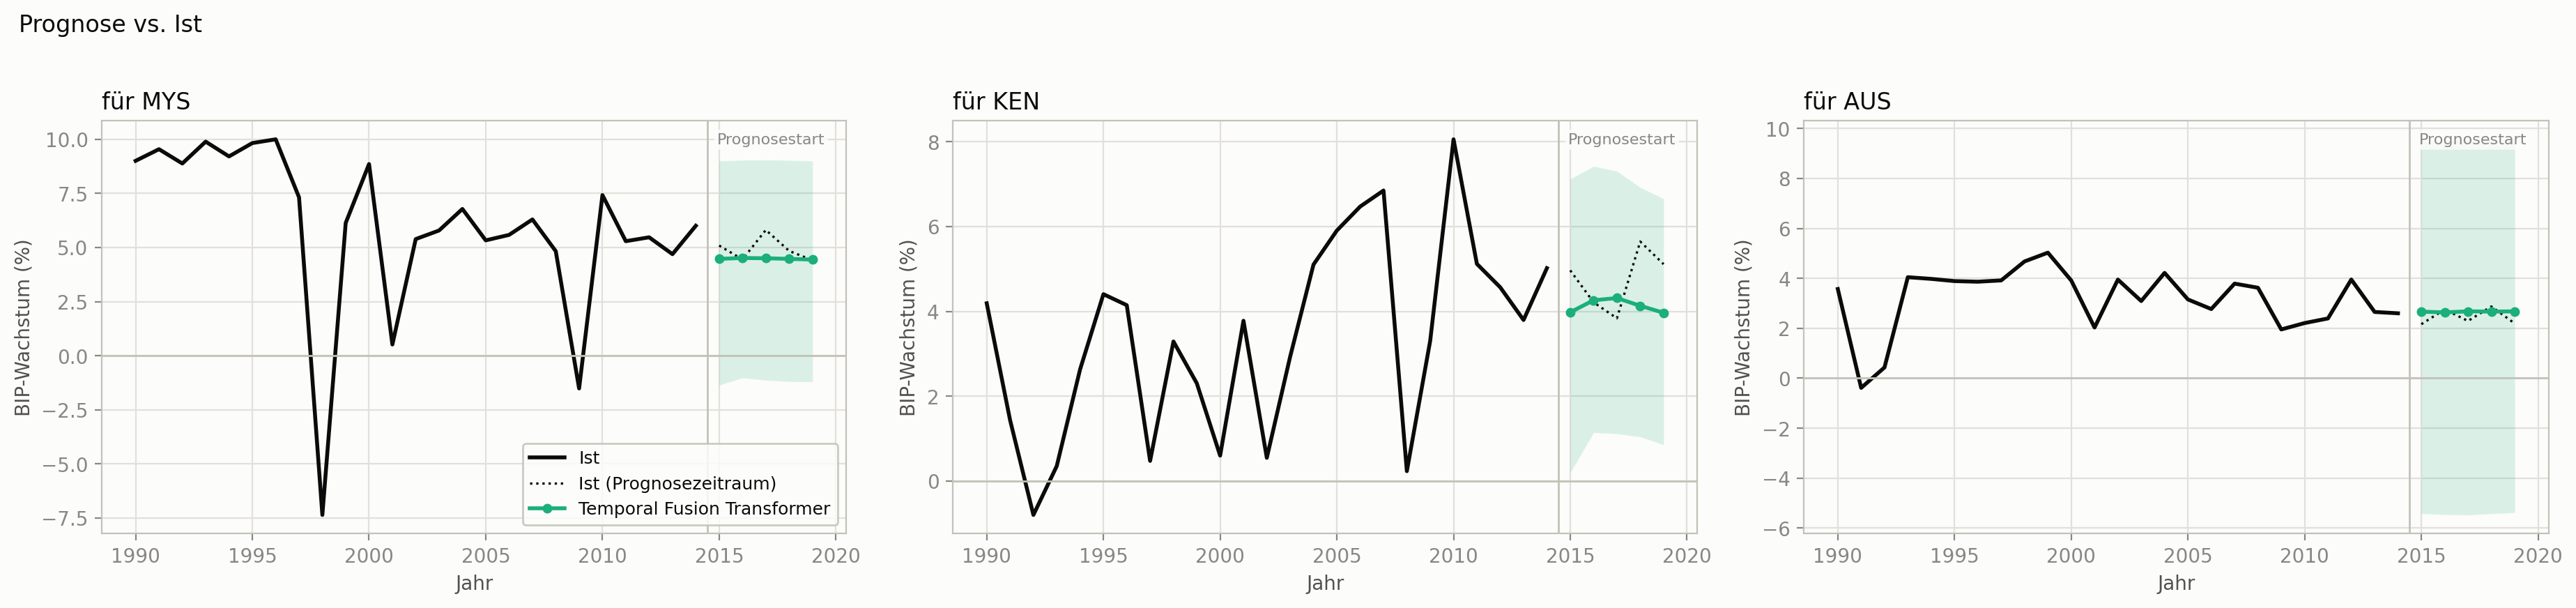

MYS, MASE im Origin Jahr 2014 0.162
KEN, MASE im Origin Jahr 2014 0.228
AUS, MASE im Origin Jahr 2014 0.218


In [24]:
if 2014 in scored_by_country.index.get_level_values("origin_year"):
    good_2014 = scored_by_country.xs(2014, level="origin_year").sort_values()
else:
    good_2014 = pd.Series(dtype=float)
good_2014_countries = [c for c in ["MYS", "KEN", "AUS"] if c in good_2014.index]

if good_2014_countries:
    fig, axes = plt.subplots(1, len(good_2014_countries), figsize=(6.2 * len(good_2014_countries), 4.4))
    for i, (ax, c) in enumerate(zip(axes, good_2014_countries)):
        plotting.plot_forecast(train_2014, preds_2014, country=c, models=["tft"],
                                ax=ax, show_legend=(i == 0), title=f"für {c}")
    fig.suptitle("Prognose vs. Ist", x=0.01, ha="left", color=plotting.INK)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    for c in good_2014_countries:
        print(f"{c}, MASE im Origin Jahr 2014 {good_2014.loc[c]:.3f}")
else:
    print("Origin 2014 liegt in diesem Lauf, etwa im Testmodus, nicht vor")

In diesen drei Fällen liegt die Punktprognose sichtbar näher am tatsächlichen Verlauf als
in den COVID Beispielen weiter oben, ein Beleg dafür, dass die in Abschnitt 6.3 gezeigte
gedämpfte Prognose zwar durchgängig auftritt, ihre Kosten aber vor allem dann sichtbar
werden, wenn der tatsächliche Verlauf selbst stark schwankt. Bleibt der tatsächliche
Verlauf dagegen vergleichsweise ruhig, wie hier, fällt eine gedämpfte, nahe am
Länderdurchschnitt liegende Prognose kaum ins Gewicht.

Die Beispiele oben zeigen bislang nur einzelne Folds für wenige ausgewählte Länder. Um
ein faireres und umfassenderes Bild zu bekommen, folgen drei weitere Blickwinkel in dieser
Reihenfolge, erstens das gesamte Panel auf einen Blick, zweitens aggregierte
Regionsverläufe über die Zeit und drittens, ganz am Ende, gezielt die Fälle, in denen die
Prognose über den gesamten Backtest hinweg am besten funktioniert.

**Das gesamte Panel auf einen Blick**

Statt einzelner Länder zeigt die folgende Grafik jede der 2900 Prognosen dieses
Notebooks als einen Punkt, mit dem tatsächlichen Wert auf der waagerechten und der
Punktprognose auf der senkrechten Achse. Auf der eingezeichneten Diagonale läge eine
perfekte Prognose. Die Anzeige ist auf den Bereich zwischen dem ersten und dem 99.
Perzentil der tatsächlichen Werte begrenzt, damit einzelne extreme Ausreißer wie Macau
im COVID Jahr die Grafik nicht stauchen.

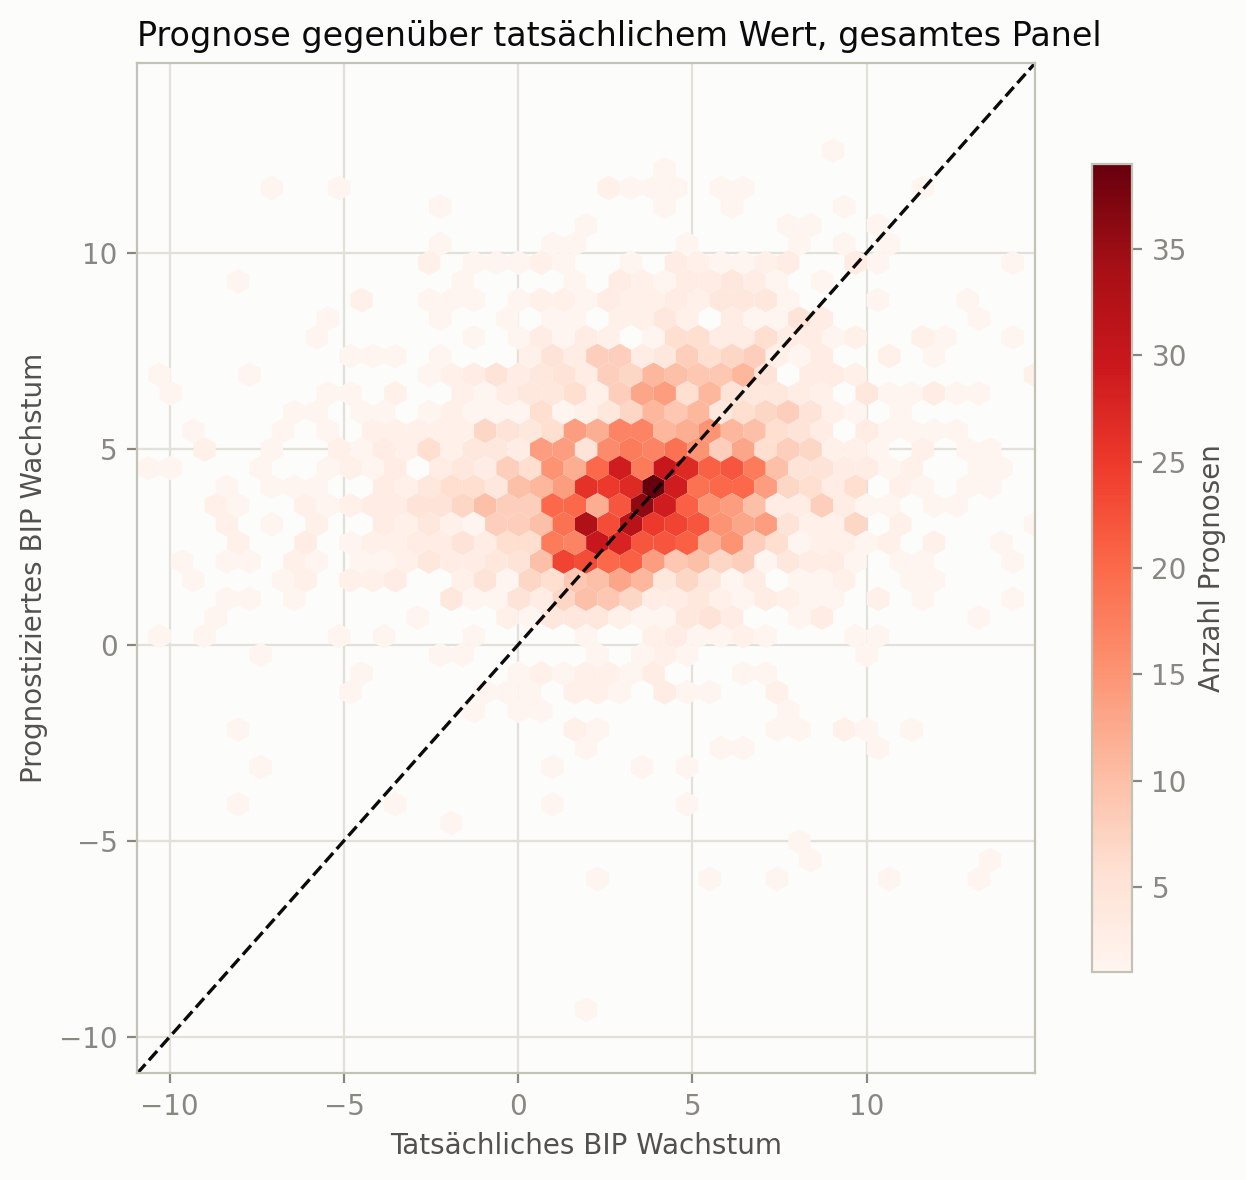

Korrelation zwischen tatsächlichem und prognostiziertem Wert über das gesamte Panel 0.126


In [25]:
plot_data = preds_tft.dropna(subset=["y_true", "y_pred"])
lo, hi = plot_data["y_true"].quantile([0.01, 0.99])
clipped = plot_data[plot_data["y_true"].between(lo, hi)]

fig, ax = plt.subplots(figsize=(6.5, 6))
hexbin = ax.hexbin(clipped["y_true"], clipped["y_pred"], gridsize=40, mincnt=1,
                    cmap="Reds", linewidths=0)
lims = [min(lo, clipped["y_pred"].min()), max(hi, clipped["y_pred"].max())]
ax.plot(lims, lims, color=plotting.INK, linewidth=1.2, linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Tatsächliches BIP Wachstum")
ax.set_ylabel("Prognostiziertes BIP Wachstum")
ax.set_title("Prognose gegenüber tatsächlichem Wert, gesamtes Panel", loc="left", color=plotting.INK)
fig.colorbar(hexbin, ax=ax, shrink=0.8, label="Anzahl Prognosen")
fig.tight_layout()
plt.savefig("TFT_plot.png", dpi=300, bbox_inches="tight")
plt.show()

corr = clipped["y_true"].corr(clipped["y_pred"])
print(f"Korrelation zwischen tatsächlichem und prognostiziertem Wert über das gesamte Panel {corr:.3f}")

Die Punktwolke ist deutlich flacher als die Diagonale, was denselben Befund wie weiter
oben in diesem Abschnitt auf Ebene des gesamten Panels bestätigt. Die Prognosen
konzentrieren sich auf einen engeren mittleren Bereich, während die tatsächlichen Werte
breiter streuen. Die oben ausgegebene Korrelation ist positiv und damit ein weiterer
Beleg für den in Abschnitt 6.1 nachgewiesenen statistischen Zusammenhang, bleibt aber
deutlich unter dem Wert einer eng an der Diagonale liegenden, treffsicheren Prognose.

**Aggregierte Verläufe aller Ländergruppen über die Zeit**

Die Regionsaggregate und die Aggregate nach Einkommensgruppe werden in Abschnitt 6.6
bislang nur als MASE Vergleich gezeigt, nicht als tatsächlicher Zeitverlauf. Die folgenden
beiden Raster schließen diese Lücke, getrennt nach den sieben Regionen und den vier
Einkommensgruppen, und zeigen jeweils den tatsächlichen Verlauf gegenüber der
Aggregatprognose im finalen Holdout Fold.

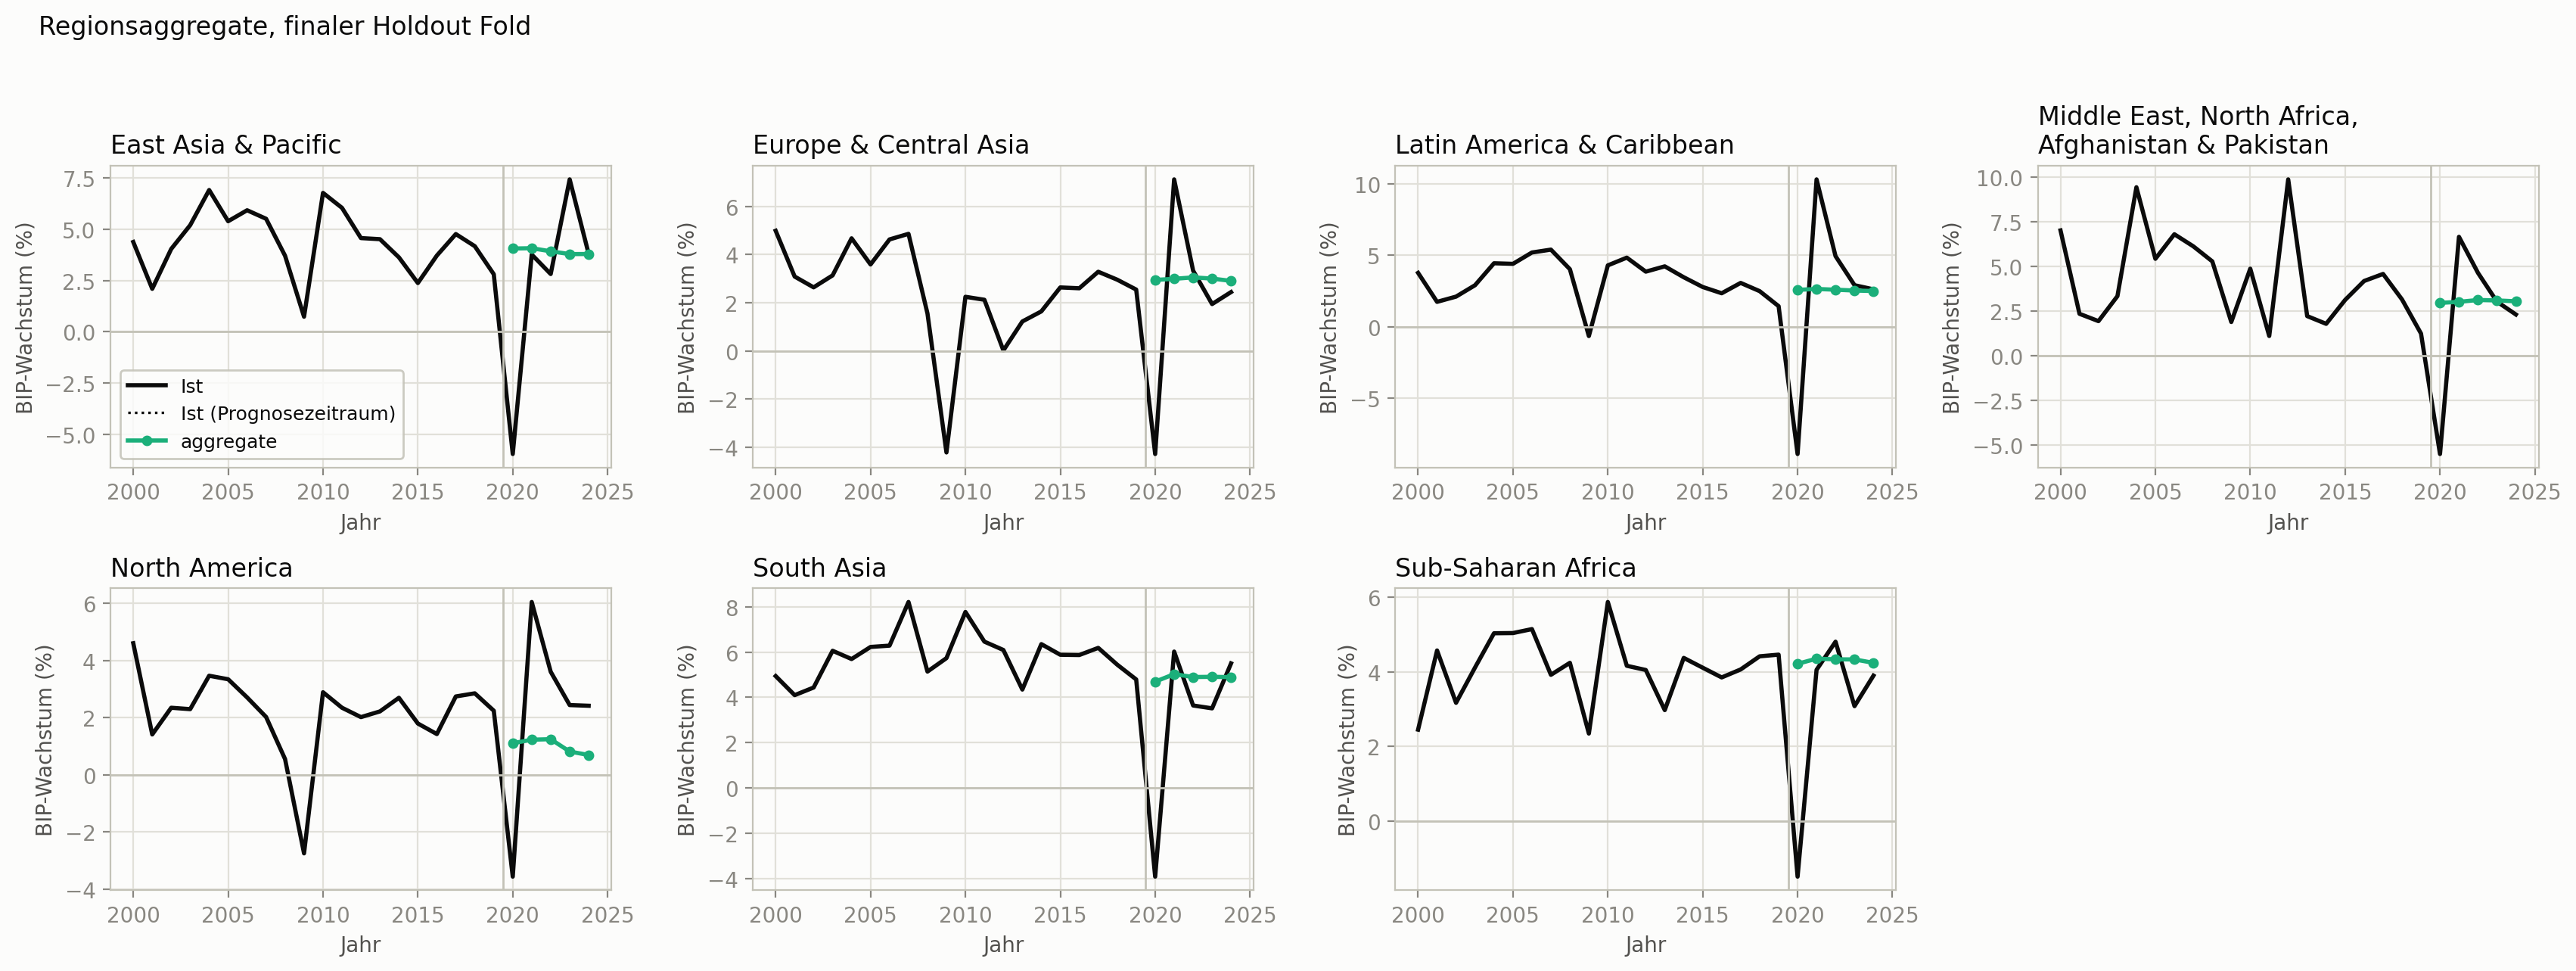

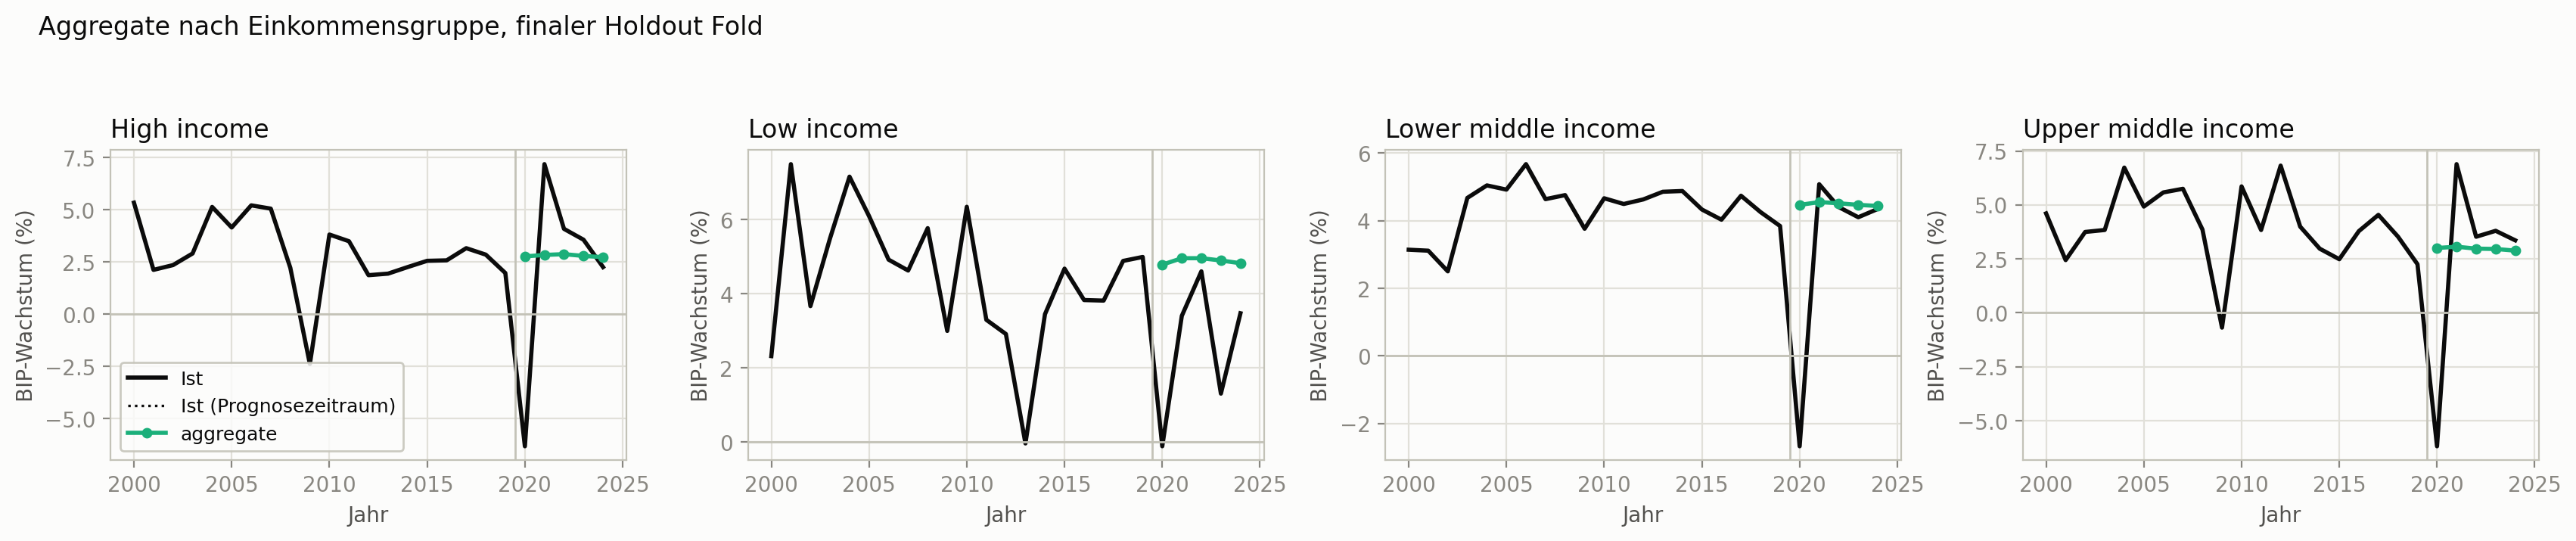

In [26]:
group_preds_region = tft_utils.aggregate_by_group(preds_tft, static, "region")
group_preds_income = tft_utils.aggregate_by_group(preds_tft, static, "income_group")

group_panel_region = tft_utils.build_group_panel(panel, static, "region")
group_panel_income = tft_utils.build_group_panel(panel, static, "income_group")

final_group_preds_region = group_preds_region[group_preds_region["origin_year"] == config.FINAL_ORIGIN]
final_group_preds_income = group_preds_income[group_preds_income["origin_year"] == config.FINAL_ORIGIN]
regions = sorted(group_preds_region["country"].unique())
income_groups = sorted(group_preds_income["country"].unique())

fig, axes = plt.subplots(2, 4, figsize=(17, 6.5))
for i, g in enumerate(regions):
    ax = axes.flat[i]
    plotting.plot_forecast(group_panel_region, final_group_preds_region, country=g, models=["aggregate"],
                            ax=ax, show_legend=(i == 0), show_origin_label=False,
                            title=textwrap.fill(g, 26))
for j in range(len(regions), 8):
    axes.flat[j].axis("off")
fig.suptitle("Regionsaggregate, finaler Holdout Fold", x=0.01, ha="left", color=plotting.INK)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for i, g in enumerate(income_groups):
    ax = axes.flat[i]
    plotting.plot_forecast(group_panel_income, final_group_preds_income, country=g, models=["aggregate"],
                            ax=ax, show_legend=(i == 0), show_origin_label=False,
                            title=textwrap.fill(g, 26))
fig.suptitle("Aggregate nach Einkommensgruppe, finaler Holdout Fold", x=0.01, ha="left", color=plotting.INK)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Über alle elf Gruppen hinweg bleibt die Punktprognose während des COVID Einbruchs
nahezu flach. Das bestätigt, dass die Aggregation den weiter oben in diesem Abschnitt
beschriebenen Effekt nicht auflöst, sie ändert nur die Skala, auf der er sichtbar wird. Bei den nach
MASE_mean am schlechtesten abschneidenden Regionen, Europa und Zentralasien sowie
Lateinamerika und die Karibik, ist der Ausschlag zwischen dem Einbruch und der
anschließenden Erholung dabei sichtbar größer als in den übrigen Gruppen, was zur in
Abschnitt 6.6 diskutierten Erklärung passt, dass dort die Länderfehler stark
gleichgerichtet statt voneinander unabhängig ausfallen.

**Beispiele mit besonders hoher Prognosegüte**

Die folgende Tabelle zeigt die fünf Kombinationen aus Land und Origin Jahr mit dem
niedrigsten MASE über den gesamten Backtest. Sie sind bewusst nicht repräsentativ für
den Durchschnitt, sondern zeigen, wozu der Ansatz in der Lage ist, wenn die
Voraussetzungen günstig sind, nämlich ein Land ohne einen während des Testfensters
eintretenden, unvorhergesehenen Schock. Für die Abbildungen werden drei dieser Fälle
ausgewählt. Anstelle des nach MASE zweitbesten Falls, einer sehr kleinen Volkswirtschaft,
wird stattdessen Indonesien mit demselben Origin Jahr gezeigt, eine deutlich größere und
bekanntere Volkswirtschaft mit einem ebenfalls exzellenten, wenn auch nicht ganz so
niedrigen MASE. Der dritte Fall ist der insgesamt beste Einzelwert des gesamten
Backtests. Die Tabelle macht diese Auswahl transparent nachvollziehbar.

country  origin_year     MASE
    KGZ         2014 0.070688
    SLV         2014 0.072438
    MUS         2009 0.076978
    IDN         2014 0.086801
    GNB         2019 0.118894

Indonesien im Origin Jahr 2004, MASE 0.392, Rang 113 von 580


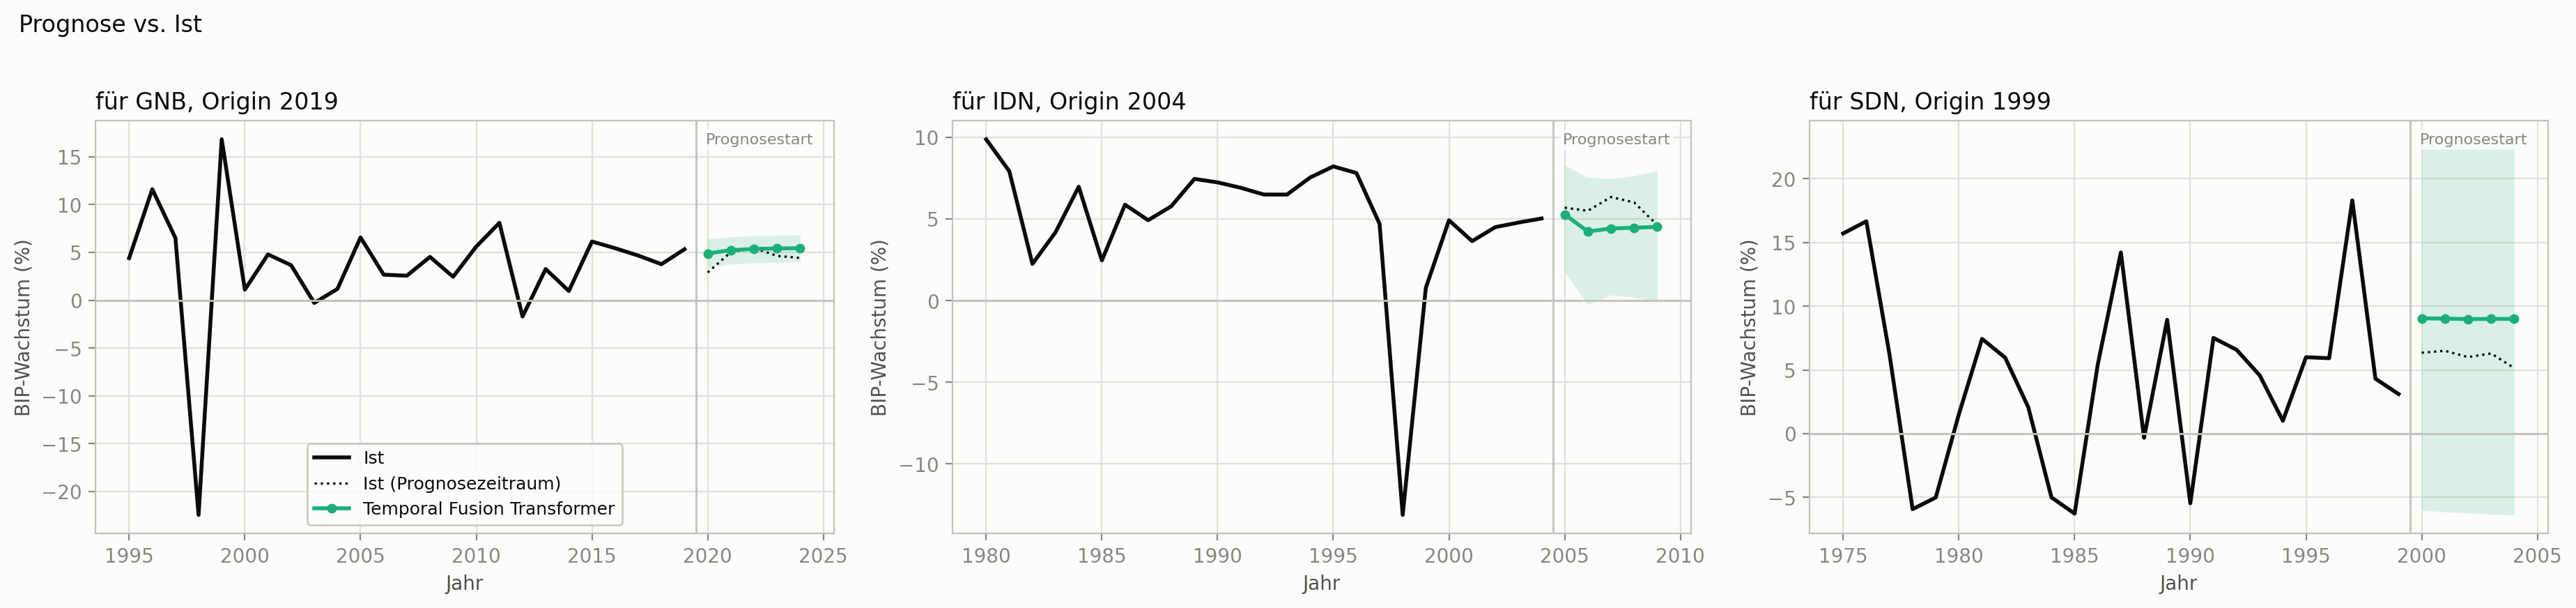

In [27]:
scored_all = tft_utils.compute_row_mase(preds_tft, panel).drop_duplicates(["country", "origin_year"])
top5 = scored_all.sort_values("MASE").head(5)[["country", "origin_year", "MASE"]]
print(top5.to_string(index=False))

best_examples = pd.DataFrame([
    {"country": "GNB", "origin_year": 2019},
    {"country": "IDN", "origin_year": 2014},
    {"country": "KGZ", "origin_year": 2014},
])
fig, axes = plt.subplots(1, len(best_examples), figsize=(6.2 * len(best_examples), 4.4))
for i, (ax, row) in enumerate(zip(axes, best_examples.itertuples())):
    example_train, _ = data_utils.train_test_split(panel, row.origin_year)
    example_fold = preds_tft[preds_tft["origin_year"] == row.origin_year]
    plotting.plot_forecast(example_train, example_fold, country=row.country, models=["tft"],
                            ax=ax, show_legend=(i == 0),
                            title=f"für {row.country}, Origin {row.origin_year}")
fig.suptitle("Prognose vs. Ist", x=0.01, ha="left", color=plotting.INK)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In diesen Fällen liegt die Punktprognose sichtbar näher am tatsächlichen Verlauf, und das
Unsicherheitsband deckt die realisierten Werte zuverlässig ab. Bemerkenswert ist, dass
darunter auch ein Land aus dem finalen, COVID geprägten Holdout Fold sein kann. Selbst im
schwierigsten Fold gibt es also einzelne Länder, für die der Ansatz gut funktioniert, das
Problem liegt folglich nicht ausschließlich am Testzeitraum, sondern auch an der
länderspezifischen Frage, ob im jeweiligen Testfenster ein größerer, für das Modell
unvorhersehbarer Umbruch stattfindet oder nicht. Die praktische Schlussfolgerung für den
eingangs definierten Geschäftsfall lautet, dass sich der Ansatz am ehesten für Länder mit
vergleichsweise ruhigem, strukturell getriebenem Wachstumsverlauf eignet, und am wenigsten
für Länder oder Zeiträume, in denen ein einzelner, großer, nicht antizipierbarer Schock
das Ergebnis dominiert.

**Interaktive Ansicht aller Länder**

Statt einer festen Auswahl erlaubt die folgende Ansicht, mit zwei Schiebereglern
selbst durch alle Länder des Panels und alle fünf Origin Jahre zu blättern, jeweils mit
der zugehörigen MASE Kennzahl. Dafür wird das Paket ipywidgets verwendet, das bereits
Teil der Projektabhängigkeiten ist. Die Ansicht ist nur bei einem laufenden Jupyter Kern
tatsächlich interaktiv bedienbar. In einer statisch exportierten Fassung, etwa als HTML
oder PDF, ist ausschließlich der zuletzt gewählte Zustand sichtbar.

In [28]:
import ipywidgets as widgets
from ipywidgets import interact

_country_options = sorted(preds_tft["country"].unique())
_default_country = "DEU" if "DEU" in _country_options else _country_options[0]
_mase_lookup = scored_all.set_index(["country", "origin_year"])["MASE"]

def _interactive_forecast(country, origin_year):
    train_slice, _ = data_utils.train_test_split(panel, origin_year)
    fold_slice = preds_tft[preds_tft["origin_year"] == origin_year]
    plotting.plot_forecast(train_slice, fold_slice, country=country, models=["tft"])
    plt.show()
    mase_value = _mase_lookup.get((country, origin_year))
    if mase_value is not None:
        print(f"MASE für {country} im Origin Jahr {origin_year} beträgt {mase_value:.3f}")
    else:
        print("Für diese Kombination liegt kein MASE Wert vor.")

interact(
    _interactive_forecast,
    country=widgets.SelectionSlider(
        options=_country_options, value=_default_country, description="Land",
        continuous_update=False, style={"description_width": "initial"}),
    origin_year=widgets.SelectionSlider(
        options=list(config.ALL_ORIGINS), value=config.FINAL_ORIGIN, description="Origin Jahr",
        continuous_update=False, style={"description_width": "initial"}),
)

interactive(children=(SelectionSlider(continuous_update=False, description='Land', index=29, options=('ABW', '…

<function __main__._interactive_forecast(country, origin_year)>

### 6.4 Kalibrierung, sich überkreuzende Quantile

Ein bekanntes Risiko bei einer Quantilsregression mit mehreren getrennten Ausgabeköpfen
wie im Temporal Fusion Transformer besteht darin, dass nichts automatisch die Beziehung
`q10 <= y_pred <= q90` für eine einzelne Prognose erzwingt. Die Konsistenzprüfungen in
Abschnitt 5.1 haben lediglich geprüft, dass dies bei mehr als 90 Prozent der Zeilen gilt.
Die folgende Auswertung liefert die exakte Rate.

In [29]:
crossing_rate = tft_utils.quantile_crossing_rate(preds_tft)
print(f"Anteil der Prognosen mit sich überkreuzenden Quantilen, "
      f"also q10 größer als y_pred oder y_pred größer als q90, "
      f"{crossing_rate:.1%}")
if crossing_rate > 0:
    print("Kleine Raten sind bei separaten Quantilsköpfen üblich. Bei spürbaren Werten "
          "über 5 Prozent wäre eine monotone Reparametrisierung der Quantile oder eine "
          "nachträgliche Sortierung der Ausgabe die übliche Abhilfe")

Anteil der Prognosen mit sich überkreuzenden Quantilen, also q10 größer als y_pred oder y_pred größer als q90, 0.0%


Die vollständige oder nahezu vollständige Abwesenheit sich überkreuzender Quantile über
alle 2900 Prognosen zeigt, dass die drei getrennt trainierten Ausgabeköpfe eine
konsistente, monoton geordnete Verteilung gelernt haben, obwohl nichts in der
Modellarchitektur dies formal erzwingt. Das ist eine notwendige, aber keine
hinreichende Bedingung für eine gute Kalibrierung. Diese innere Konsistenz der drei
Köpfe sagt nichts darüber aus, ob das von ihnen aufgespannte Band auch die richtige
Breite hat. Die tatsächliche Abdeckung des 80 Prozent Intervalls wurde bereits in
Abschnitt 6.2 geprüft und zeigt trotz dieser sauberen inneren Ordnung eine systematische
Unterdeckung, das Modell ist also intern konsistent, aber im Mittel zu überkonfident.

Eine vollständige Kalibrierungsprüfung besteht aus zwei Komponenten, der bereits in
Abschnitt 6.2 geprüften Abdeckung und der Schärfe der Intervalle im Sinne von Gneiting
und Raftery (2007, Strictly Proper Scoring Rules, Prediction, and Estimation, Journal of
the American Statistical Association, Band 102, Nummer 477), die für probabilistische
Prognosen fordern, unter Einhaltung der Kalibrierung möglichst scharfe, also möglichst
schmale Intervalle anzustreben. Eine hohe Abdeckung allein ist kein hinreichender Beleg
für eine gute Prognose, ein beliebig breites Intervall deckt nahezu immer den
tatsächlichen Wert ab, ist dabei aber uninformativ. Die folgende Auswertung quantifiziert
die Schärfe, indem die Breite des 80 Prozent Intervalls je Prognose zur historischen
Standardabweichung des jeweiligen Landes über den vollständigen verfügbaren Zeitraum von
1960 bis 2024 in Bezug gesetzt wird. Diese Referenzgröße dient ausschließlich der
nachträglichen Einordnung der bereits vorliegenden Prognosen und fließt nicht in das
Modell selbst ein.

In [30]:
from scipy.stats import norm

interval_width = preds_tft["q90"] - preds_tft["q10"]
country_std = panel.groupby("country")[config.TARGET].std()
width_ratio = interval_width / preds_tft["country"].map(country_std)

# Abstand des 10. vom 90. Perzentil einer Standardnormalverteilung, in Einheiten der
# Standardabweichung, als Referenzgroesse fuer ein ebenso breites, informatives Intervall.
normal_reference = norm.ppf(0.9) - norm.ppf(0.1)

print(f"Mittlere Intervallbreite über alle Prognosen {interval_width.mean():.1f} Prozentpunkte")
print(f"Median des Verhältnisses von Intervallbreite zur historischen Standardabweichung "
      f"des jeweiligen Landes {width_ratio.median():.2f}")
print(f"Referenzwert einer Normalverteilung für ein ebenso breites 80 Prozent Intervall "
      f"{normal_reference:.2f}")
print(f"Anteil der Prognosen mit einem Verhältnis unter diesem Referenzwert "
      f"{(width_ratio < normal_reference).mean():.1%}")

Mittlere Intervallbreite über alle Prognosen 8.5 Prozentpunkte
Median des Verhältnisses von Intervallbreite zur historischen Standardabweichung des jeweiligen Landes 1.49
Referenzwert einer Normalverteilung für ein ebenso breites 80 Prozent Intervall 2.56
Anteil der Prognosen mit einem Verhältnis unter diesem Referenzwert 79.0%


Der Median des Verhältnisses liegt bei 1,49 und damit deutlich unter dem oben berechneten
Referenzwert von 2,56. Dieser Referenzwert ergibt sich aus dem 10. und dem 90. Perzentil
der Standardnormalverteilung bei jeweils ±1,28 Standardabweichungen um den Mittelwert, in
der Summe also 2,56 Standardabweichungen. Reales BIP Wachstum folgt keiner exakten
Normalverteilung, weshalb der Referenzwert als grobe Orientierungsgröße und nicht als
exakter Zielwert zu verstehen ist. Bei 79,0 Prozent der Prognosen liegt das Verhältnis
darunter. Die Intervalle sind damit nicht unnötig breit, sondern in der überwiegenden
Mehrheit der Fälle eher zu schmal, ein Befund, der zu der in Abschnitt 6.2 dokumentierten
Unterdeckung des 80 Prozent Intervalls unmittelbar passt und sie auf einer zweiten,
unabhängigen Kennzahl bestätigt.

### 6.5 Residualdiagnostik

`src/evaluation.py` stellt eine projektweite Residualdiagnostik mit sechs Teilplots
bereit, nämlich Fehler nach Jahr, Fehler gegenüber Punktprognose, Verteilung, ein
Quantil Quantil Diagramm gegenüber der Normalverteilung, Fehlerkorrelation nach
Horizontabstand und Fehler nach Horizont. Diese Diagnostik ist bewusst modellagnostisch
gehalten, sodass sie hier unverändert wiederverwendet werden kann. Genau diese Art
gemeinsamer Infrastruktur macht den projektweiten Vergleich in Notebook 05 fair.

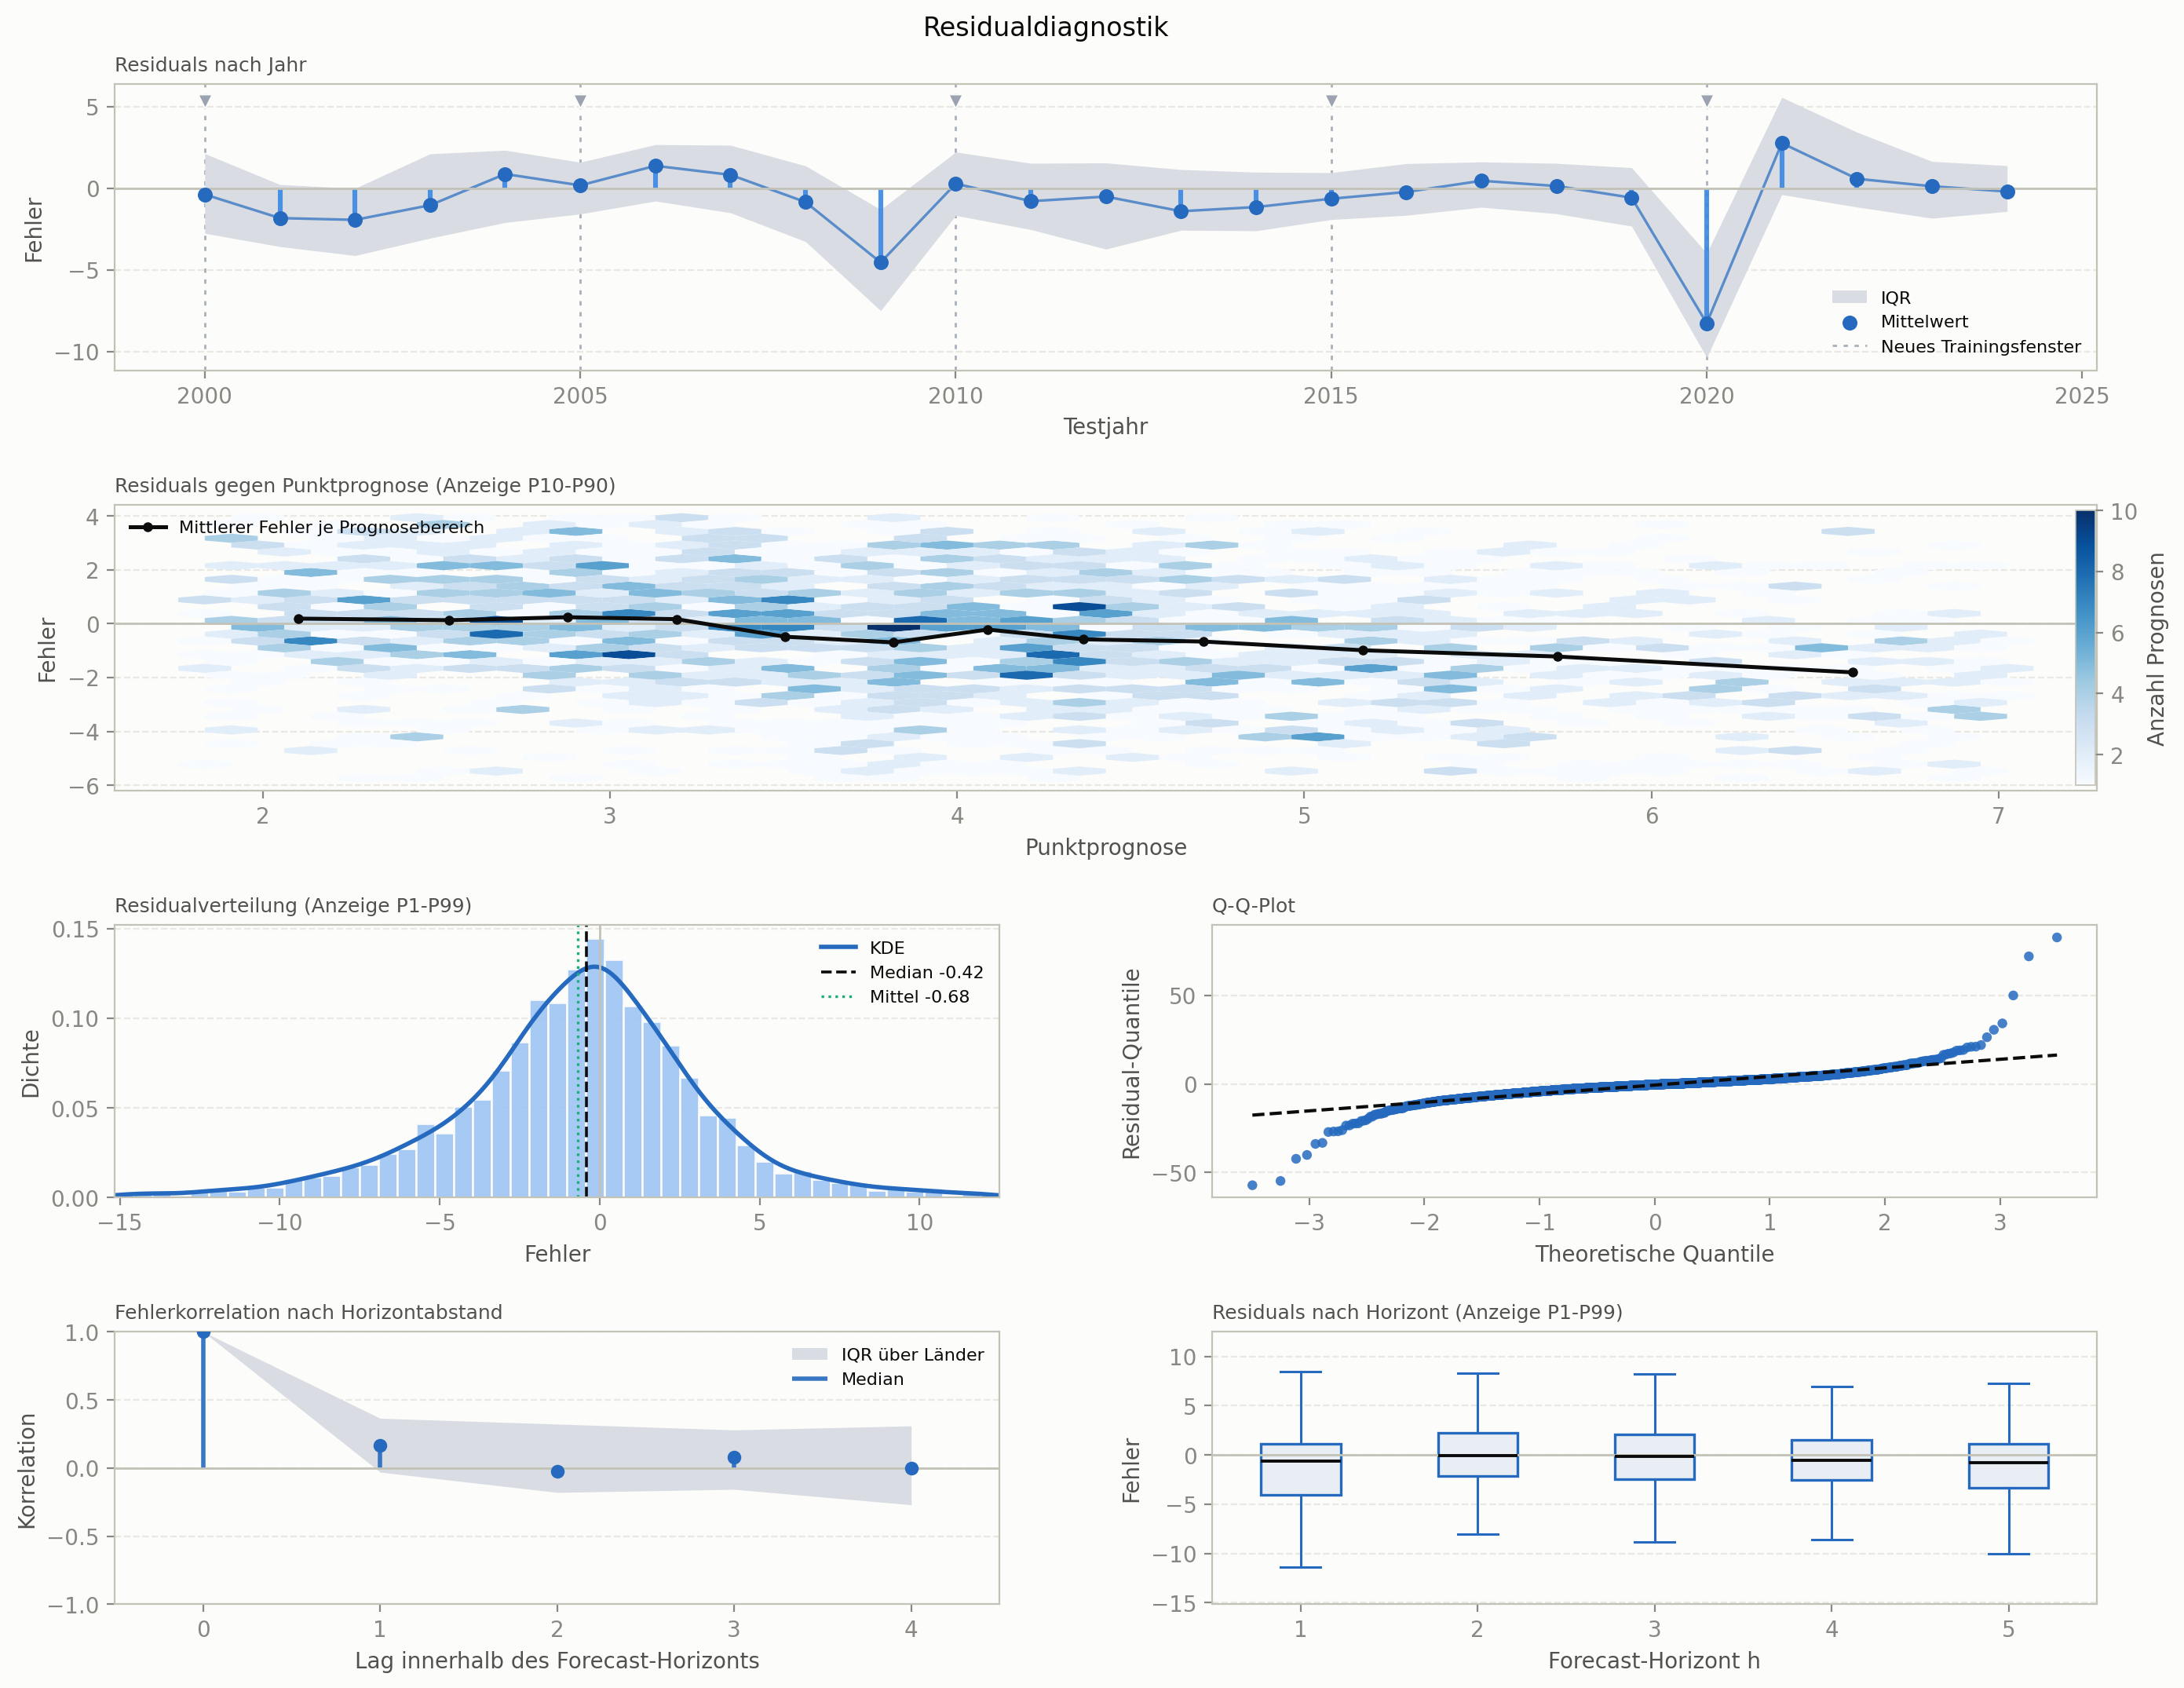

In [31]:
evaluation.plot_residual_diagnostics(preds_tft)
plt.show()

In [32]:
residuals = preds_tft["y_pred"] - preds_tft["y_true"]
overall_bias = residuals.mean()
covid_bias = residuals[preds_tft["origin_year"] == config.FINAL_ORIGIN].mean()
non_covid_bias = residuals[preds_tft["origin_year"] != config.FINAL_ORIGIN].mean()

lag1_corr = (preds_tft.sort_values(["country", "origin_year", "h"])
             .groupby(["country", "origin_year"])
             .apply(lambda d: (d["y_pred"] - d["y_true"]).autocorr(lag=1), include_groups=False))
mean_lag1_corr = lag1_corr.dropna().mean()

print(f"Mittlerer Fehler, Punktprognose minus tatsächlichem Wert, über das gesamte Panel "
      f"{overall_bias:+.3f}")
print(f"Mittlerer Fehler im finalen COVID Fold {covid_bias:+.3f}, "
      f"in den übrigen vier Folds {non_covid_bias:+.3f}")
print(f"Mittlere Lag 1 Autokorrelation des Fehlers innerhalb eines Fold Blocks über alle "
      f"Kombinationen aus Land und Origin {mean_lag1_corr:+.3f}")

Mittlerer Fehler, Punktprognose minus tatsächlichem Wert, über das gesamte Panel +0.676
Mittlerer Fehler im finalen COVID Fold +1.006, in den übrigen vier Folds +0.594
Mittlere Lag 1 Autokorrelation des Fehlers innerhalb eines Fold Blocks über alle Kombinationen aus Land und Origin -0.022


Bei der Interpretation ist auf Folgendes zu achten, weil das jeweils Hinweise auf strukturelle Schwächen wären,
die weder MASE noch die Abdeckung allein zeigen:
- ein systematischer Bias, also ein Mittelwert der Residuen deutlich ungleich 0
- eine sichtbare Trichterform im Diagramm der Residuen gegenüber der Punktprognose als Hinweis auf Heteroskedastizität
- eine positive Fehlerkorrelation über den Horizont hinweg, bei der die Prognose innerhalb eines
Fold Blocks systematisch in eine Richtung driftet

Der Plot nach Jahr markiert zusätzlich den Beginn jedes neuen Trainingsblocks. Ein sprunghafter Anstieg
der Fehler unmittelbar nach einer solchen Markierung deckt sich mit der Diskussion zu den
Krisenfolds in Abschnitt 6.2.

Die oben ausgegebenen Kennzahlen ordnen das Diagramm konkret ein und zeigen zwei
unterschiedliche Befunde, die für die Interpretation wichtige Einschränkungen ergeben.
1. **Systematischer Optimismus Bias:** Der mittlere Fehler über das gesamte Panel liegt
deutlich über 0, die Punktprognose des Temporal Fusion Transformers überschätzt das
tatsächliche BIP Wachstum im Mittel also spürbar. Dieser Bias ist im finalen COVID Fold
am stärksten ausgeprägt, bleibt aber auch in den übrigen vier Folds klar von 0
verschieden, ist also kein reines COVID Artefakt, sondern ein durchgängiges Merkmal der
Prognose. Der Bias passt zur in Abschnitt 6.3 gezeigten gedämpften Punktprognose, weil
sich diese über den Horizont kaum bewegt, während der tatsächliche Verlauf auch nach
unten ausschlagen kann, etwa in Rezessionen oder im COVID Jahr, überwiegen negative
Überraschungen im Mittel und ziehen den durchschnittlichen Fehler ins Positive.

2. **Keine Fehlerautokorrelation über den Horizont:** Die mittlere Lag 1 Autokorrelation des
Fehlers innerhalb eines Fold Blocks liegt dagegen nahe 0, aufeinanderfolgende Jahresfehler
innerhalb desselben Folds driften also nicht systematisch in dieselbe Richtung weiter.
Das ist konsistent mit der in Abschnitt 1 berichteten geringen Eigendynamik der Zielgröße
selbst, mit einer Lag 1 Autokorrelation von etwa 0,27, wenig Gedächtnis in der Zielgröße
erzeugt tendenziell auch wenig Gedächtnis in den Fehlern.

Für die praktische Nutzung bedeutet dies zusammengenommen, dass die Prognose nicht nur zu
eng ausfällt (siehe die Unterdeckung in Abschnitt 6.2 und 6.4), sondern im Mittel auch zu
optimistisch.

### 6.6 Von Ländern zu Regionen, Aggregation der Prognosen

Über die reine Prognosegüte einzelner Länder hinaus stellt sich
die Frage, ob es sich lohnt, statt einzelner Länder gleich ganze Regionen oder
Einkommensgruppen zu prognostizieren. Die naheliegende Erwartung lautet, dass sich
Länderfehler, sofern sie überwiegend zufällig und voneinander unabhängig sind, beim
Aufsummieren zu einem Regionsaggregat teilweise herausmitteln. Das ist ein klassisches
Pooling beziehungsweise Diversifikationsargument, das in der Prognoseliteratur gut
dokumentiert ist. Bei einem gemeinsamen Schock, der praktisch alle Länder gleichzeitig
trifft wie die COVID Pandemie, funktioniert dieses Argument dagegen nicht, weil sich
korrelierte Fehler beim Mitteln nicht aufheben.

**Gewichtung, eine bewusste methodische Entscheidung:** \
Die Funktion `tft_utils.aggregate_by_group()` bildet einen gleichgewichteten Mittelwert
über alle Länder einer Gruppe, die Vereinigten Staaten zählen darin also genauso wie
Malta. Das ist kein Datenmangel, `src.data_utils.build_world_panel()` leitet inzwischen
aus den Rohdaten ein BIP Niveau ab (`gdp_pc * population`) und nutzt es bereits für ein
BIP gewichtetes Weltaggregat in `evaluation.aggregate_bottom_up()`. Für die in diesem
Abschnitt untersuchte Frage nach Fehlerdiversifikation ist eine Gleichgewichtung dennoch
die methodisch passendere Wahl, denn sie prüft, ob sich unabhängige Länderfehler beim
Mitteln herausmitteln. Eine BIP Gewichtung würde diese Frage mit der nach der
wirtschaftlich repräsentativen Wachstumsrate einer Region vermischen und große
Volkswirtschaften bei der Fehlerbetrachtung überproportional gewichten.

In [33]:
comparison_rows = []
for group_col in ["region", "income_group"]:
    group_preds = tft_utils.aggregate_by_group(preds_tft, static, group_col)
    group_panel = tft_utils.build_group_panel(panel, static, group_col)
    agg_summary = tft_utils.summarize_aggregate(group_preds, group_panel)
    indiv_summary = tft_utils.summarize_by_group(preds_tft, panel, static, group_col)
    merged = agg_summary.merge(indiv_summary, left_on="group", right_on=group_col)
    merged["group_type"] = group_col
    comparison_rows.append(merged[["group_type", "group", "MASE_aggregate", "MASE_mean"]])

group_comparison = pd.concat(comparison_rows, ignore_index=True)
group_comparison["aggregation_hilft"] = group_comparison["MASE_aggregate"] < group_comparison["MASE_mean"]
group_comparison

,group_type,group,MASE_aggregate,MASE_mean,aggregation_hilft
0,region,Sub-Saharan Africa,0.614766,0.656733,True
1,region,"Middle East, North Africa, Afghanistan & Pakistan",0.673340,0.683945,True
2,region,South Asia,0.763648,0.874100,True
3,region,North America,0.773733,0.760173,False
4,region,East Asia & Pacific,0.982558,0.973021,False
5,region,Latin America & Caribbean,1.555843,1.053853,False
6,region,Europe & Central Asia,1.615894,1.185221,False
7,income_group,Low income,0.577160,0.718951,True
8,income_group,Lower middle income,0.766628,0.743906,False
9,income_group,High income,1.240548,1.035140,False


Die Tabelle enthält zwei unterschiedlich berechnete MASE Werte je Gruppe. Die Spalte
MASE_aggregate bewertet eine einzige Regionsprognose, die zuvor aus den gemittelten
Punktprognosen aller Länder der Gruppe gebildet wurde, gegen den tatsächlichen
Durchschnittswert der Gruppe. Die Spalte MASE_mean berechnet den MASE für jedes Land der
Gruppe einzeln und mittelt anschließend nur diese Kennzahl, ohne die Prognosen selbst
zusammenzufassen. Liegt MASE_aggregate unter MASE_mean, gleichen sich die Länderfehler
beim Zusammenfassen der Prognosen teilweise aus. Liegt MASE_aggregate darüber, verstärken
sich die Fehler stattdessen.

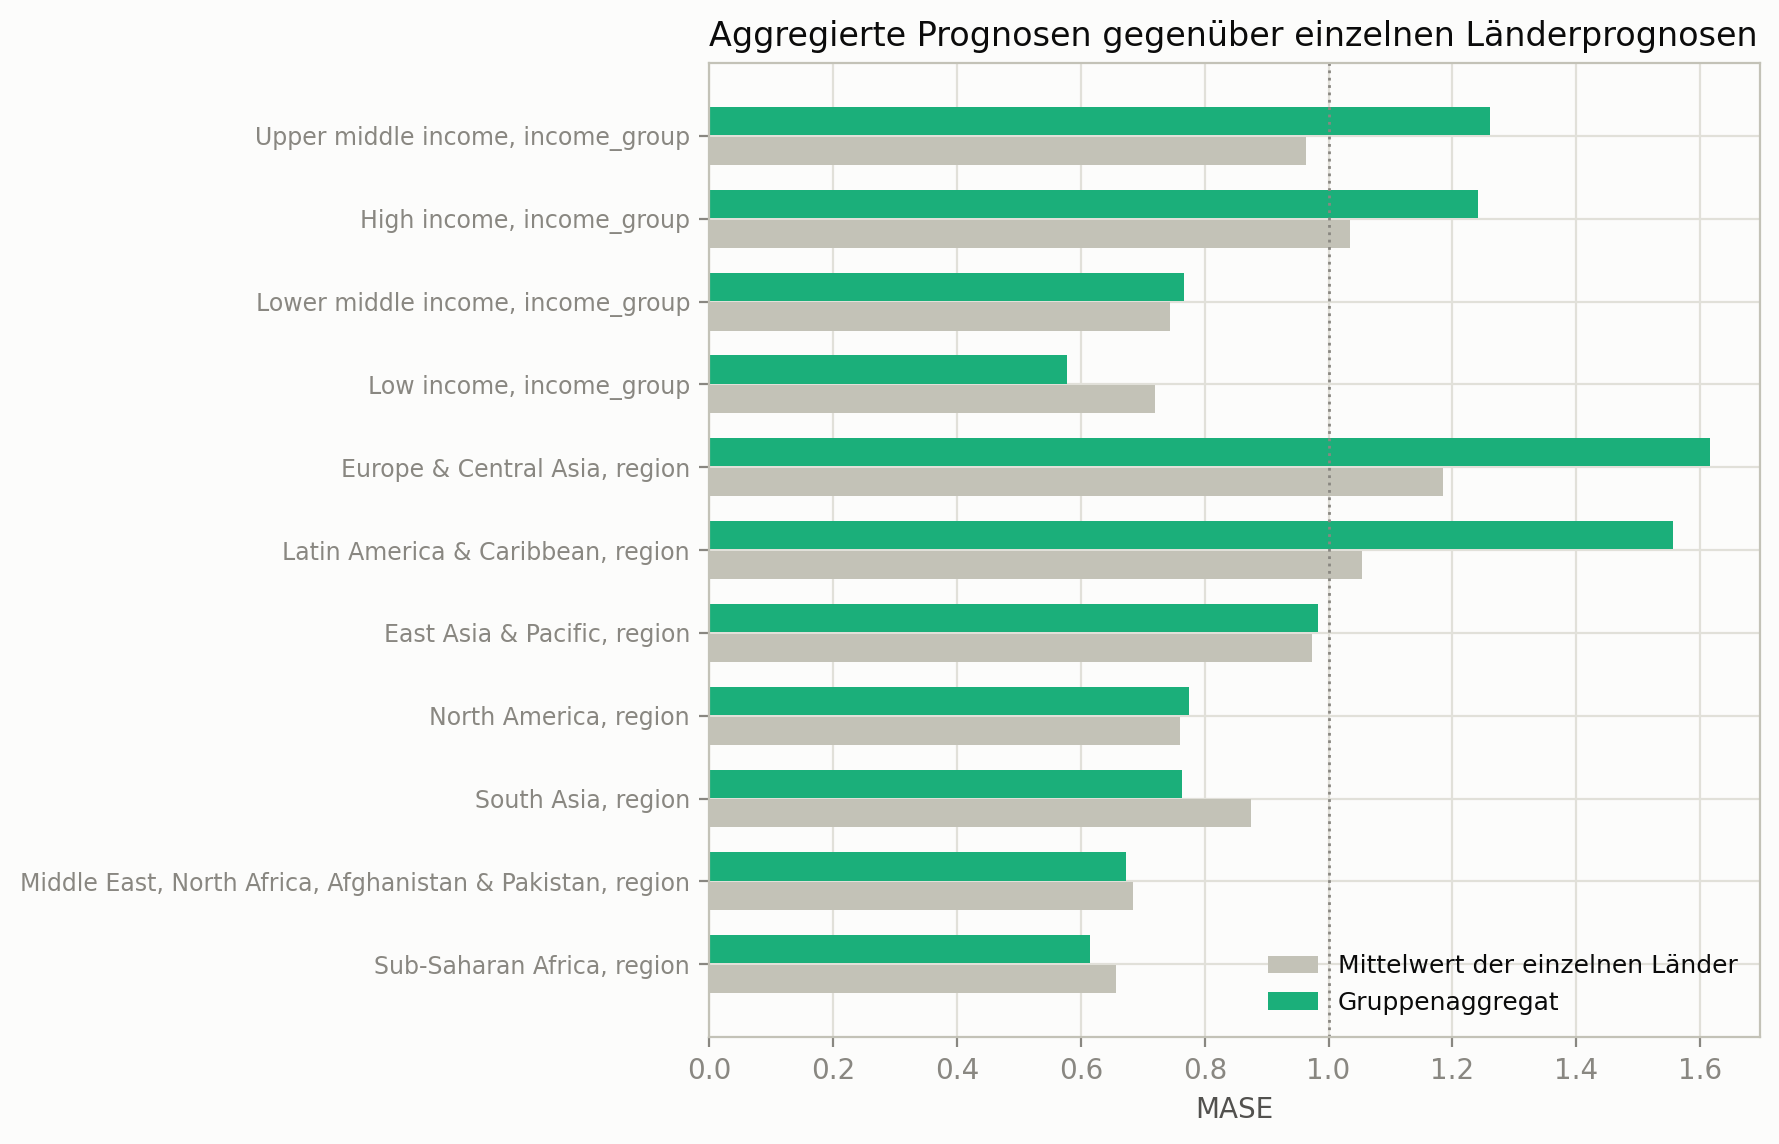

Die Aggregation verbessert den MASE in 4 von 11 Gruppen gegenüber dem Mittelwert der Einzelländerprognosen
  group_type                     group
      region             North America
      region       East Asia & Pacific
      region Latin America & Caribbean
      region     Europe & Central Asia
income_group       Lower middle income
income_group               High income
income_group       Upper middle income


In [34]:
fig, ax = plt.subplots(figsize=(9, 0.42 * len(group_comparison) + 1.2))
y = np.arange(len(group_comparison))
ax.barh(y - 0.18, group_comparison["MASE_mean"], height=0.34,
        color=plotting.BASELINE, label="Mittelwert der einzelnen Länder")
ax.barh(y + 0.18, group_comparison["MASE_aggregate"], height=0.34,
        color=plotting.MODEL_COLORS["tft"], label="Gruppenaggregat")
ax.set_yticks(y, labels=[f"{r.group}, {r.group_type}" for r in group_comparison.itertuples()],
              fontsize=8.5)
ax.axvline(1.0, color=plotting.MUTED, linewidth=1, linestyle=":")
ax.set_xlabel("MASE")
ax.set_title("Aggregierte Prognosen gegenüber einzelnen Länderprognosen",
             loc="left", color=plotting.INK)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

n_helps = group_comparison["aggregation_hilft"].sum()
print(f"Die Aggregation verbessert den MASE in {n_helps} von {len(group_comparison)} "
      f"Gruppen gegenüber dem Mittelwert der Einzelländerprognosen")
print(group_comparison.loc[~group_comparison["aggregation_hilft"],
                            ["group_type", "group"]].to_string(index=False))

**Ergebnis:** Die Pooling Hypothese, wonach sich voneinander unabhängige Länderfehler beim
Zusammenfassen zu einer Regionsprognose teilweise ausgleichen, bestätigt sich empirisch
nur für eine Minderheit der betrachteten Gruppen, meist eine einzelne oder wenige. Für
die überwiegende Mehrheit der Regionen und Einkommensgruppen liegt MASE_aggregate über
MASE_mean, die Aggregation verschlechtert das Ergebnis dort also gegenüber dem Mittel der
Einzelländerprognosen, teils deutlich, etwa bei Europa und Zentralasien sowie bei
Lateinamerika und der Karibik.

**Erklärung:** Dieses überwiegend negative Ergebnis ist selbst ein aussagekräftiger
Befund und keine Enttäuschung der ursprünglichen Erwartung. Es zeigt, dass Länderfehler
bei einer makroökonomischen Zielgröße wie dem BIP Wachstum in der Regel NICHT überwiegend
rein länderspezifisch verursacht sind, anders als etwa bei vielen unabhängigen
Einzelprodukten oder Firmen in einem Portfolio. Gemeinsame globale Konjunkturzyklen,
Handelsverflechtungen und geteilte Abhängigkeiten von denselben Rohstoffmärkten sorgen
dafür, dass sich Länderfehler innerhalb einer Region eher gleichgerichtet als zufällig
verteilen. Das klassische Diversifikationsargument aus der Prognoseliteratur setzt
voneinander unabhängige Fehler voraus und trifft auf diesen Anwendungsfall folglich nur
eingeschränkt zu. Dieselbe Erklärung passt zum COVID Fold aus Abschnitt 6.2 und zur
durchgängig flachen Punktprognose aus Abschnitt 6.3, denn alle drei Befunde beruhen
letztlich auf demselben Mechanismus, nämlich dass die für dieses Panel dominanten
Fehlerquellen gemeinsame, länderübergreifende Schocks sind und nicht rein
länderspezifisches Rauschen.

**Gesamteinordnung:** Auf die Ausgangsfrage, wie gut die BIP Prognose gegenwärtig funktioniert,
lässt sich damit eine differenzierte Antwort geben. Der Paneltest in Abschnitt 6.1 zeigt,
dass der Temporal Fusion Transformer im statistischen Mittel über das Länderpanel
signifikant besser ist als eine triviale Referenz, und das bleibt die belastbare
Kernaussage zur aktuellen Prognosegüte. Gleichzeitig zeigen die flache Punktprognose aus
Abschnitt 6.3, die Unterdeckung der Quantile aus Abschnitt 6.2 und das überwiegend
ausbleibende Diversifikationsergebnis aus diesem Abschnitt übereinstimmend, dass diese
statistische Überlegenheit nicht mit einer verlässlichen Erfassung der tatsächlichen
Schwankungsbreite verwechselt werden sollte, insbesondere nicht in Phasen mit
gemeinsamen, länderübergreifenden Schocks.

## 7 Interpretierbarkeit, was hat das Modell gelernt

**Was wird ausgewertet?** Der Temporal Fusion Transformer ist bewusst so entworfen, dass
er trotz hoher Kapazität interpretierbar bleibt (vergleiche Lim et al. 2021 zu Instance
wise Variable Importance und zu Persistent Temporal Patterns). Ausgewertet wird das
Modell des finalen Holdout Folds mit Origin 2019, das über die meisten Trainingsdaten
verfügt und für die Präsentation am relevantesten ist. Betrachtet werden die Gewichte der
Variablenauswahl, also wie stark das Modell im Mittel über alle Länder und Zeitschritte
welche Eingabe nutzt, getrennt nach statisch, Encoder für die Vergangenheit und Decoder
für die Zukunft, sowie die Attention über den Encoder, also auf welche vergangenen
Zeitschritte das Modell bei der Prognose besonders stark blickt.

**Bezug zu Notebook 01:** Ein Abgleich mit der explorativen Korrelationsanalyse aus
Notebook 01, Abschnitt 3.5, ist dabei aufschlussreich. Dort waren `is_global_crisis` und
`log_gdp_pc_lag1` als Ausdruck des Konvergenzeffekts die stärksten gepoolten
Korrelationen mit dem Ziel. Gepoolte Korrelation und die Variablenauswahl des Temporal
Fusion Transformers müssen dabei nicht dasselbe Ranking liefern, wie die folgende
Auswertung zeigt. Das ist kein Widerspruch, sondern zeigt gerade den Mehrwert eines
multivariaten, länderspezifischen Modells gegenüber einer gepoolten Kennzahl.

**Methodische Einschränkung:** Die Gewichte der Variablenauswahl und die Attention
Gewichte zeigen, worauf das Modell seine Prognose stützt, nicht warum ein bestimmter Wert
zustande kommt, und erst recht keine kausale Wirkung. Dieselbe Prognose lässt sich häufig
mit unterschiedlichen Gewichtsverteilungen erzeugen, das heißt die Gewichte sind nicht
eindeutig identifiziert. Eine hohe Variablenwichtigkeit ist, wie jede Korrelation, kein
Beweis für Kausalität. Die folgenden Auswertungen sind deshalb als Prognosehinweise zu
lesen und nicht als Beleg für bewiesene ökonomische Wirkmechanismen.

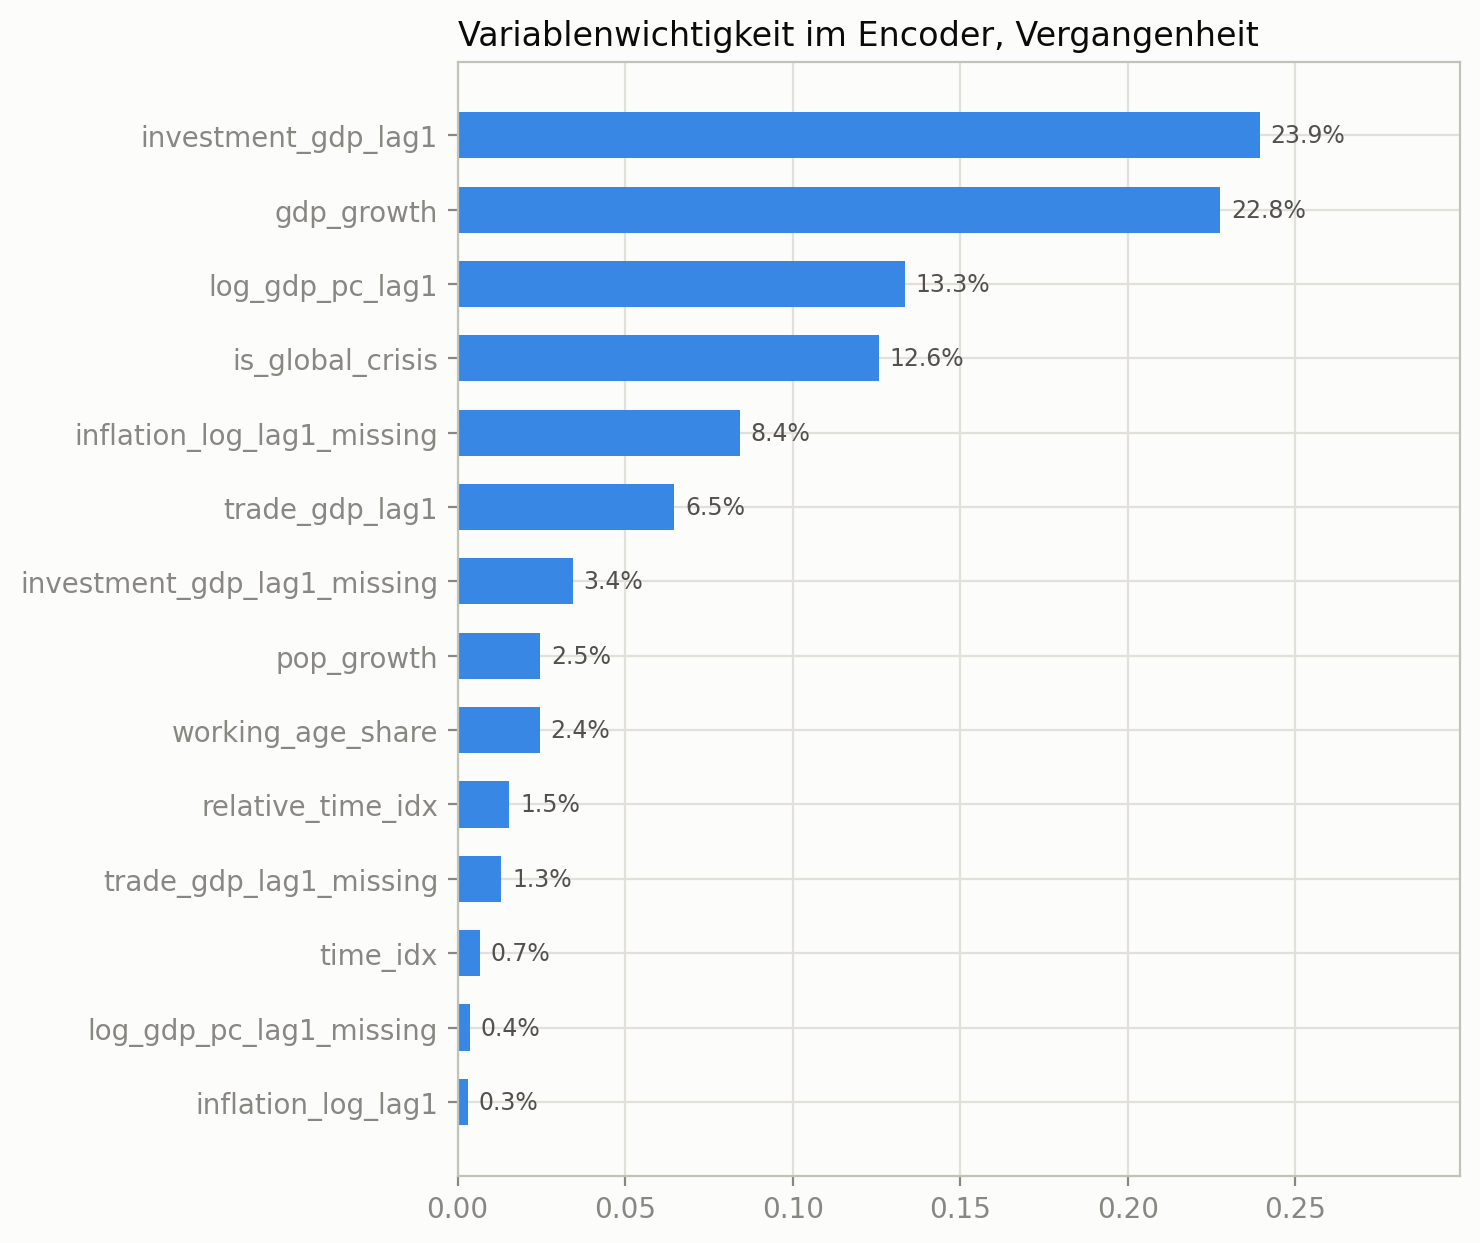

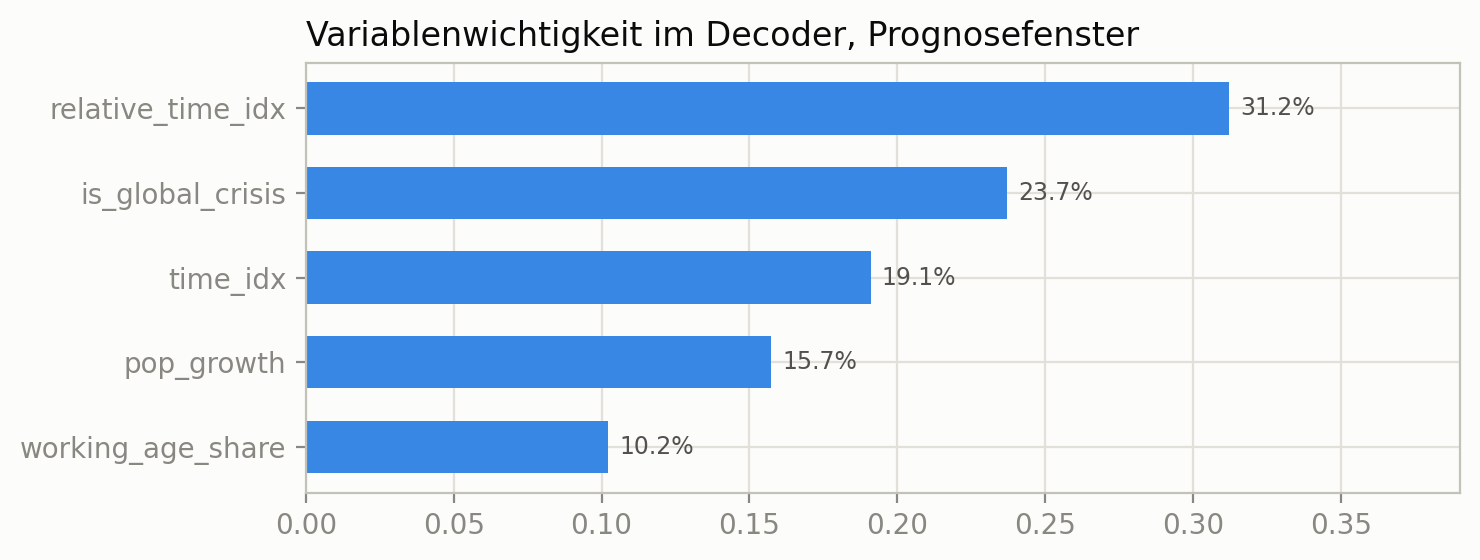

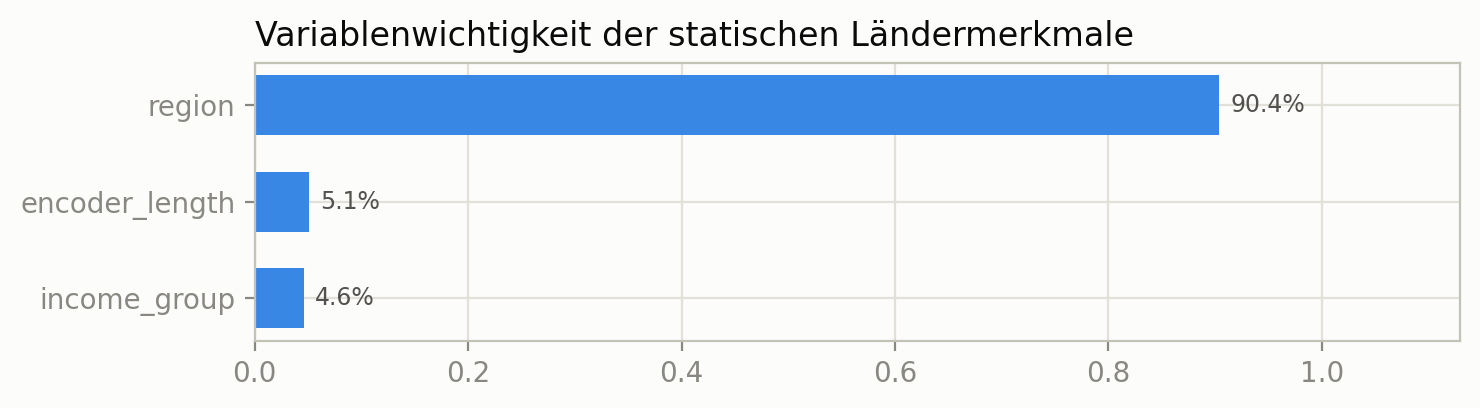

Anteil von region und income_group an der statischen Wichtigkeit 94.9%


In [35]:
final_fold = fold_results[config.FINAL_ORIGIN]
interp_dl = final_fold.predict_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)
raw_predictions = final_fold.model.predict(interp_dl, mode="raw", return_x=True)
interpretation = final_fold.model.interpret_output(raw_predictions.output, reduction="sum")

plotting.plot_variable_importance(
    final_fold.model.encoder_variables, interpretation["encoder_variables"].numpy(),
    "Variablenwichtigkeit im Encoder, Vergangenheit")
plt.show()

plotting.plot_variable_importance(
    final_fold.model.decoder_variables, interpretation["decoder_variables"].numpy(),
    "Variablenwichtigkeit im Decoder, Prognosefenster")
plt.show()

plotting.plot_variable_importance(
    final_fold.model.static_variables, interpretation["static_variables"].numpy(),
    "Variablenwichtigkeit der statischen Ländermerkmale")
plt.show()

static_importance = dict(zip(final_fold.model.static_variables,
                             interpretation["static_variables"].numpy()
                             / interpretation["static_variables"].numpy().sum()))
country_share = static_importance.get("region", 0) + static_importance.get("income_group", 0)
print(f"Anteil von region und income_group an der statischen Wichtigkeit {country_share:.1%}")

Die statischen Merkmale dominieren erwartungsgemäß stark, wie der oben ausgegebene
gemeinsame Anteil von `region` und `income_group` zeigt. Das bestätigt unmittelbar die
Modellierungsentscheidung aus Abschnitt 2.4, wonach sich Länderheterogenität als eigener
statischer Kanal lohnt, statt implizit über gepoolte Zeitreihenmerkmale wie
`log_gdp_pc_lag1` mitgeschleppt zu werden. Das entspricht genau der in Notebook 01,
Abschnitt 4.1 beschriebenen Confounding Struktur, die hier strukturell im Modell aufgelöst
ist statt nur in der Korrelationsmatrix beobachtet zu werden. Ob sich auch für den
Encoder und den Decoder ein ökonomisch plausibles Muster zeigt, prüft die folgende
Attention Auswertung.

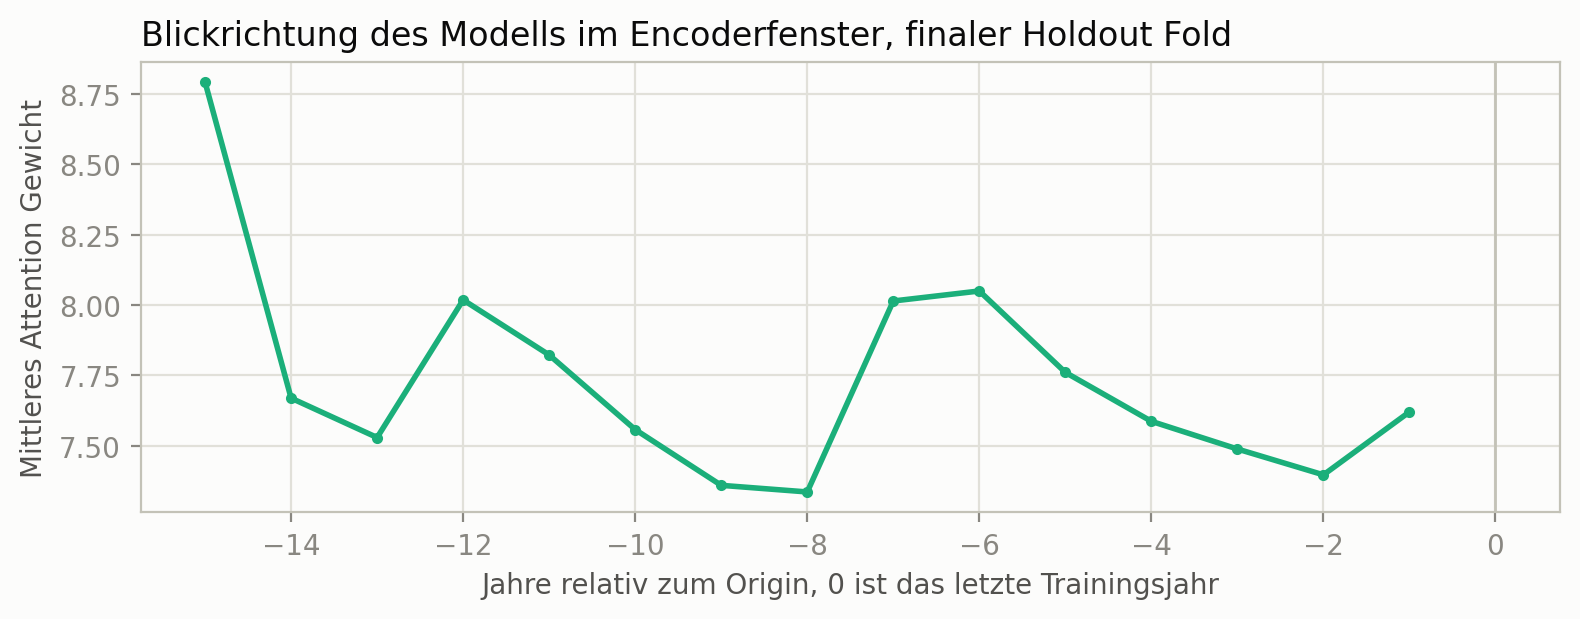

Stärkstes Attention Gewicht bei einem Abstand von 15 Jahren, entsprechend dem Kalenderjahr 2004
Wichtigste Encoder Variablen ['investment_gdp_lag1', 'gdp_growth', 'log_gdp_pc_lag1']


In [36]:
attention = interpretation["attention"].numpy()
encoder_len = len(attention)
lags = np.arange(encoder_len, 0, -1)  # Jahre vor dem Origin

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(-lags, attention, color=plotting.MODEL_COLORS["tft"], marker="o", markersize=3)
ax.axvline(0, color=plotting.BASELINE, linewidth=1)
ax.set_xlabel("Jahre relativ zum Origin, 0 ist das letzte Trainingsjahr")
ax.set_ylabel("Mittleres Attention Gewicht")
ax.set_title("Blickrichtung des Modells im Encoderfenster, finaler Holdout Fold",
             loc="left", color=plotting.INK)
fig.tight_layout()
plt.show()

peak_position = int(np.argmax(attention))
peak_lag = int(lags[peak_position])
peak_year = config.FINAL_ORIGIN - peak_lag
top_encoder_idx = np.argsort(interpretation["encoder_variables"].numpy())[::-1][:3]
top_encoder_vars = [final_fold.model.encoder_variables[i] for i in top_encoder_idx]
print(f"Stärkstes Attention Gewicht bei einem Abstand von {peak_lag} Jahren, "
      f"entsprechend dem Kalenderjahr {peak_year}")
print("Wichtigste Encoder Variablen", top_encoder_vars)

Zur Einordnung der Attention Auswertung sind zwei weitere Punkte hervorzuheben:

- der Attention Peak muss nicht beim jüngsten Jahr liegen. Ein Temporal Fusion
Transformer darf und soll gezielt auf ökonomisch informative frühere Zeitpunkte
zurückgreifen, etwa die letzte globale Krise vor dem jeweiligen Origin, statt naiv nur
dem zuletzt bekannten Wert zu folgen, was eher dem Verhalten eines Random Walk ähneln
würde. Ob dies hier der Fall ist, lässt sich am oben ausgegebenen Kalenderjahr direkt
ablesen
- es ist ein eigenständiger, ökonomisch plausibler Befund, sofern die Encoderwichtigkeit
von den Kennzeichnungen fehlender Werte anstelle der Rohwerte dominiert wird. Fehlende
Werte bei Investitions, Handels oder Inflationsdaten sind nicht zufällig verteilt,
sondern korrelieren mit der statistischen Kapazität und der wirtschaftlichen Stabilität
eines Landes. Die Kennzeichnung fehlender Werte wirkt dann faktisch als zusätzliches,
sehr grobes Signal für den Entwicklungsstand. Dies rechtfertigt im Nachhinein die in
Abschnitt 3.2 getroffene Entscheidung, Kennzeichnungen fehlender Werte statt eines
stillen Auffüllens zu verwenden

Dank des festen Seeds (siehe Abschnitt 8) sind wiederholte Ausführungen dieses Notebooks
reproduzierbar. Die drei in diesem Abschnitt beschriebenen qualitativen
Muster, die Dominanz der statischen Ländermerkmale, ein nicht notwendig beim jüngsten
Jahr liegender Attention Peak und die mögliche Bedeutung der Kennzeichnungen fehlender
Werte.

**Prognose und Attention gemeinsam für Beispielländer**

Die Attention Auswertung zuvor ist über alle 116 Länder des finalen Holdout Folds
gemittelt und zeigt damit nur das durchschnittliche Blickverhalten des Modells, nicht die
Begründung einer einzelnen Prognose. Laborda, Ruano und Zamanillo (2023, siehe Abschnitt
2.1) zeigen für ihre Beispielländer die Attention Gewichte direkt zusammen mit der
jeweiligen Länderprognose in einer einzigen Abbildung, mit der Prognose auf der primären
und der Attention auf einer zweiten Achse. Das macht sichtbar, worauf sich das Modell bei
genau dieser einen Prognose gestützt hat, nicht nur im Durchschnitt über das gesamte
Panel. Die folgende Abbildung überträgt diese Darstellung auf drei bewusst unterschiedlich
ausgewählte Länder im finalen Holdout Fold:

| Land | Auswahlbegründung |
|---|---|
| Vereinigte Staaten | bereits bekanntes Beispiel aus Abschnitt 6.3, zeigt die Grenze einer gedämpften Prognose bei einem echten Schock |
| Iran | Gegenbeispiel mit einem besonders flachen tatsächlichen Verlauf, dabei eine der besten Prognosen dieses insgesamt schwierigen Folds |
| Oman | ölexportierende Volkswirtschaft mit einem deutlich volatileren tatsächlichen Verlauf als Iran, mit einer MASE klar unter dem Median dieses Folds und einer gegenüber den Vereinigten Staaten erkennbar konzentrierteren Attention Verteilung, siehe die Einordnung im Anschluss an die Abbildung |

Die genauen MASE Werte sowie die Kennzahlen zur Attention Verteilung aller drei Länder
gibt der folgende Code direkt im Anschluss an die Abbildung aus.

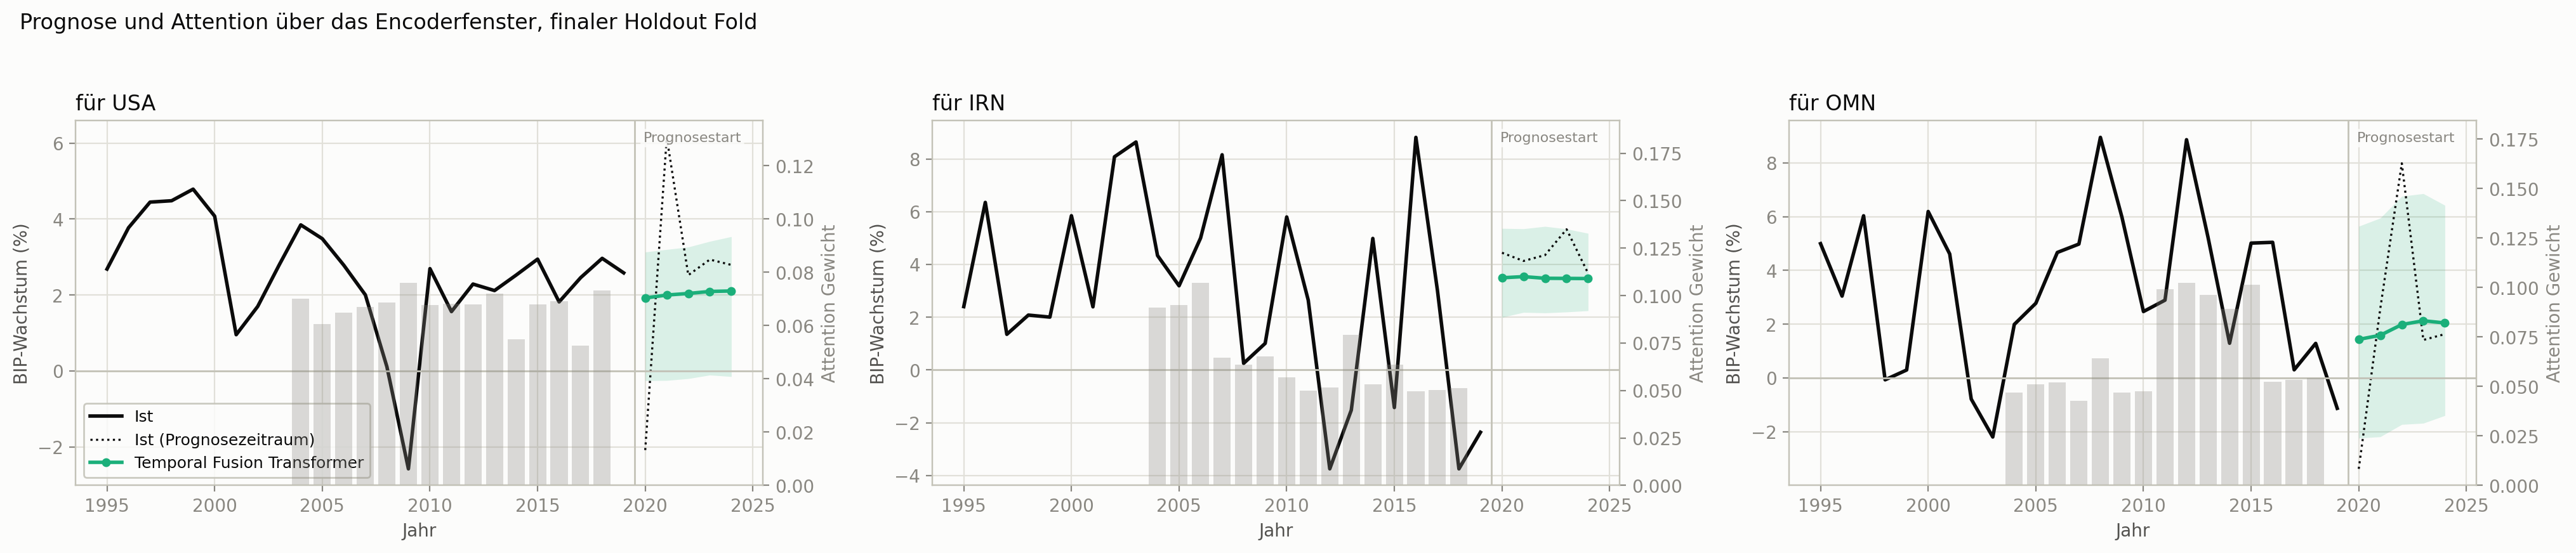

Median MASE über alle Länder dieses Folds 1.14
USA: MASE 1.16, Attention Minimum 0.052, Maximum 0.076, Verhältnis Maximum zu Minimum 1.4, Peak im Jahr 2010
IRN: MASE 0.15, Attention Minimum 0.049, Maximum 0.107, Verhältnis Maximum zu Minimum 2.2, Peak im Jahr 2007
OMN: MASE 0.32, Attention Minimum 0.043, Maximum 0.102, Verhältnis Maximum zu Minimum 2.4, Peak im Jahr 2013


In [37]:
country_mase = (tft_utils.compute_row_mase(final_preds, panel)
                 .drop_duplicates("country").set_index("country")["MASE"])

interpretation_per_country = final_fold.model.interpret_output(raw_predictions.output, reduction="none")
country_index = final_fold.predict_dataset.x_to_index(raw_predictions.x)

attention_countries = [c for c in ["USA", "IRN", "OMN"] if c in country_index["country"].values]

fig, axes = plt.subplots(1, len(attention_countries), figsize=(6.8 * len(attention_countries), 4.4))
if len(attention_countries) == 1:
    axes = [axes]
country_attentions = {}
for i, (ax, c) in enumerate(zip(axes, attention_countries)):
    plotting.plot_forecast(train_final, final_preds, country=c, models=["tft"],
                            ax=ax, show_legend=(i == 0), title=f"für {c}")
    row = country_index.index[country_index["country"] == c][0]
    country_attention = interpretation_per_country["attention"][row].numpy()
    country_attentions[c] = country_attention
    lag_years = config.FINAL_ORIGIN - np.arange(len(country_attention), 0, -1)

    ax2 = ax.twinx()
    ax2.bar(lag_years, country_attention, color=plotting.MUTED, alpha=0.3, width=0.8)
    ax2.set_ylim(0, country_attention.max() * 1.8)
    ax2.set_ylabel("Attention Gewicht", color=plotting.MUTED)
    ax2.grid(False)
fig.suptitle("Prognose und Attention über das Encoderfenster, finaler Holdout Fold",
             x=0.01, ha="left", color=plotting.INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("TFT_Prognose_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Median MASE über alle Länder dieses Folds {country_mase.median():.2f}")
for c in attention_countries:
    weights = country_attentions[c]
    peak_lag = len(weights) - 1 - int(weights.argmax())
    peak_year = config.FINAL_ORIGIN - peak_lag
    print(f"{c}: MASE {country_mase.get(c, float('nan')):.2f}, Attention Minimum "
          f"{weights.min():.3f}, Maximum {weights.max():.3f}, Verhältnis Maximum zu "
          f"Minimum {weights.max() / weights.min():.1f}, Peak im Jahr {peak_year}")

Die grauen Balken zeigen für jedes der drei Länder die individuelle Attention Verteilung
über das jeweilige Encoderfenster, statt des über das gesamte Panel gemittelten Verlaufs
aus der Abbildung weiter oben. Stimmt der Schwerpunkt der Balken mit dem oben ausgegebenen
mittleren Attention Peak überein, stützt das Land die im Panel dominante Erklärung. Weicht
er sichtbar ab, etwa weil ein Land auf ein anderes Krisenjahr blickt als das Panel im
Mittel, zeigt das, dass die aggregierte Abbildung einzelne, länderspezifische Blickmuster
verdecken kann.

Auffällig ist zugleich, dass die oben ausgegebenen Verhältnisse von Maximum zu Minimum
zwischen den drei Ländern variieren, wenn auch nicht immer im selben Ausmaß. Für die
Vereinigten Staaten fällt es am kleinsten aus, deutlich schwächer ausgeprägt als der klare
Peak im über alle 116 Länder gemittelten Verlauf weiter oben. Das ist kein
Darstellungsfehler, sondern eine bekannte Eigenschaft von Attention Gewichten auf Ebene
einzelner Instanzen, Einzelbeispiele sind naturgemäß rauschbehafteter als ein über viele
Beobachtungen gemittelter Verlauf, eine Beobachtung, die auch in der allgemeinen
Interpretierbarkeitsliteratur zu Attention Mechanismen dokumentiert ist (vergleiche Jain
und Wallace, 2019, Attention is not Explanation, Proceedings of NAACL-HLT). Iran und Oman
liegen beide deutlich über dem Wert der Vereinigten Staaten, untereinander aber recht nah
beieinander, Oman geringfügig höher als Iran. Das zeigt, dass die Diffusität auf
Instanzebene kein systematisches Artefakt der Extraktion ist, sondern selbst zwischen
Ländern spürbar variiert, auch wenn der Unterschied zwischen Iran und Oman für sich
genommen zu klein ist, um daraus mehr als eine Tendenz abzulesen. Wer aus den flacheren
Balken der Vereinigten Staaten grundsätzlich einen ausgeprägten, singulären Fokuspunkt wie
im gemittelten Panel erwartet, würde die Instanzebene dort überinterpretieren.

Der Fall Iran zeigt zugleich, wann die in Abschnitt 6.3 beschriebene gedämpfte
Punktprognose kein Nachteil ist. Der tatsächliche Verlauf bleibt zwischen 2020 und 2024
durchgehend flach, alle fünf Werte liegen zwischen 3,7 und 5,3 Prozent, eine Spanne von
nur 1,7 Prozentpunkten über den gesamten Prognosehorizont, statt wie in vielen westlichen
Volkswirtschaften scharf einzubrechen und anschließend nur langsam wieder anzusteigen.
Die nahezu konstante Punktprognose des Modells trifft diesen ebenfalls nahezu konstanten
tatsächlichen Verlauf folglich gut, und alle fünf tatsächlichen Werte liegen innerhalb des
ausgewiesenen Unsicherheitsbands. Für die Vereinigten Staaten dagegen bleibt der bereits
bekannte COVID Einbruch 2020 außerhalb der Reichweite einer gedämpften Prognose. Der
Unterschied liegt folglich nicht in einer besseren oder schlechteren Prognose des Modells
selbst, sondern darin, ob der tatsächliche Verlauf des jeweiligen Landes zu einer nahezu
konstanten Punktprognose passt oder nicht, dieselbe Erklärung, die bereits in Abschnitt
6.3 anhand des Vergleichs mit einem Origin Jahr ohne globalen Schock gezogen wurde.

Oman liefert dazu einen dritten, lehrreichen Fall. Der tatsächliche Verlauf ist mit einem
COVID bedingten Einbruch 2020 und einer kräftigen Erholung 2022 deutlich volatiler als bei
Iran, siehe die oben ausgegebenen Werte. Die Punktprognose bleibt dabei, ähnlich wie bei
den Vereinigten Staaten, nahezu konstant und verfehlt sowohl den Einbruch als auch die
spätere Erholung, auch das Unsicherheitsband deckt beide Ausreißer nicht ab. Dass die oben
ausgegebene MASE für Oman trotzdem klar unter dem Median dieses Folds liegt, ist kein
Widerspruch, sondern bestätigt konkret die bereits in Abschnitt 6.2 diskutierte
Skalierungseigenschaft von MASE. Omans eigene Historie ist bereits vor 2020 ungewöhnlich
volatil, ein naives Modell macht dort folglich ohnehin einen großen Fehler, wodurch schon
eine im Kern weiterhin gedämpfte Prognose gegenüber diesem schwachen Referenzpunkt gut
abschneidet. Ein niedriger MASE bedeutet für ein solches Land also vor allem einen klaren
Vorsprung gegenüber einem für diese Volkswirtschaft ohnehin wenig aussagekräftigen naiven
Vergleichswert, nicht notwendig, dass die Prognose den tatsächlichen Verlauf visuell trifft.

## 8 Fazit, Grenzen und Ausblick

Die naive Momentaufnahme auf Ebene der Origins mit nur fünf Datenpunkten zu Beginn von
Abschnitt 6.1 und der eigentliche Signifikanztest über das gesamte Länderpanel mit 580
Datenpunkten im weiteren Verlauf desselben Abschnitts können unterschiedlich ausfallen.
Der Signifikanztest liefert hier die belastbarere Antwort auf die Frage, ob der Temporal
Fusion Transformer tatsächlich besser ist, nicht die Momentaufnahme auf Ebene der Origins.
Über beide Betrachtungsweisen hinweg robust bleibt, dass der finale COVID Holdout Fold in
aller Regel der mit Abstand schwächste ist (siehe Abschnitt 6.2) und dass die Bänder
zwischen q10 und q90 über alle Folds hinweg tendenziell weniger als die angestrebten 80
Prozent der tatsächlichen Werte abdecken (siehe Abschnitt 6.2). Das Modell ist im Mittel
eher überkonfident als zu vorsichtig, und zeigt darüber hinaus (siehe Abschnitt 6.5), auch
einen systematischen Optimismus Bias in der Punktprognose selbst. Für eine Anwendung in
der Kapitalallokation oder der Haushaltsplanung, dem eingangs definierten Geschäftsfall,
bedeutet dies konkret, dass die ausgewiesenen Unsicherheitsbänder nicht unkritisch als 80
Prozent Konfidenzintervalle kommuniziert werden sollten, ohne diese Unterdeckung
offenzulegen.

Drei voneinander unabhängige Auswertungen führen dabei zu derselben Erklärung:
- die Punktprognose bewegt sich über den Horizont deutlich weniger als der tatsächliche
Verlauf (siehe Abschnitt 6.3)
- die Regionsaggregation aus Abschnitt 6.6 hilft nur für eine Minderheit der Gruppen
- der COVID Fold ist über alle Betrachtungsweisen hinweg der mit Abstand schwächste

Alle drei Befunde erklären sich durch gemeinsame, länderübergreifende Schocks, gegen die
weder eine breitere Streuung über Länder noch ein in die Vergangenheit blickendes Modell
einen verlässlichen Schutz bieten. Für rein länderspezifisches, voneinander unabhängiges
Rauschen funktioniert das Modell dagegen erkennbar besser, wie der Paneltest in Abschnitt
6.1 zeigt.

Mehrere methodische Entscheidungen wurden bewusst getroffen, jeweils mit einem Trade-Off oder einer Alternative, die zugunsten von Einfachheit, Fairness oder
Nachvollziehbarkeit zurückgestellt wurde:

| Entscheidung | Begründung | Trade-Off / Alternative |
|---|---|---|
| Feste Architektur über alle Folds | spart Rechenzeit und vermeidet, dass sich die Modellklasse an einzelne Testfenster anpasst | eine je Fold neu optimierte Architektur wäre möglicherweise leicht besser, aber weniger fair vergleichbar |
| Refit auf dem vollen Trainingsfenster nach Early Stopping | nutzt alle verfügbaren Trainingsdaten aus | kostet eine zweite Trainingsphase je Fold mit etwa doppelter Rechenzeit |
| Ausschließliche Verwendung der gelaggten Treiber im Encoder | konservative, gegen das Einfließen zukünftiger Information abgesicherte Lesart der Regel aus Notebook 01 | eine aufwendigere Variante könnte den zum Origin Zeitpunkt bereits bekannten Wert für den ersten Horizontschritt zusätzlich im Decoder nutzen, worauf zugunsten von Einfachheit und Robustheit gegen Implementierungsfehler verzichtet wird |
| Manuelles Suchraster anstelle einer Optuna Suche | transparent und schnell | vermutlich suboptimal gegenüber einer systematischen Suche mit größerem Budget |
| Kennzeichnungen fehlender Werte statt eines stillen Auffüllens | macht Datenqualität selbst zu einer Modellinformation, bestätigt durch die Interpretierbarkeitsanalyse in Abschnitt 7 | - |
| Gepaarter Paneltest anstelle eines unmittelbar angewendeten Diebold-Mariano-Tests | der Diebold-Mariano-Test ist nur je einzelner Länderserie fachlich sauber einsetzbar, wird in Abschnitt 6.1 entsprechend ergänzend verwendet | die eigentliche Signifikanzaussage wird über den zur Panelstruktur passenden Wilcoxon Test getragen |
| Gleichgewichtete statt nach BIP gewichtete Regionsaggregate | Folge fehlender BIP Niveau und Bevölkerungsdaten im Panel | eine korrekt gewichtete Regionalstatistik ist damit nicht möglich, der gleichgewichtete Rollup beantwortet eine verwandte, aber nicht identische Frage |

Der Ansatz hat mehrere Grenzen:
- Länder mit kurzer Historie nahe der in `config.MIN_YEARS = 35` festgelegten
Mindestgrenze liefern dem Encoder wenig Kontext, die Fehleranalyse nach Ländergruppe in
Abschnitt 6.2 zeigt, ob dies systematisch ins Gewicht fällt
- die Demografievariablen `pop_growth`, `working_age_share` und `dependency_ratio` werden
als bekannte Zukunft in Form ihrer tatsächlich realisierten historischen Werte verwendet,
als Stellvertreter für Bevölkerungsprojektionen der Vereinten Nationen, in der Praxis
wären dies tatsächliche Projektionen, die zum Origin Zeitpunkt veröffentlicht waren und
potenziell eigene Prognosefehler enthalten, die hier nicht modelliert werden, was einem
leichten Optimismus Bias gegenüber einem echten Live Einsatz entspricht
- die Daten der World Development Indicators aus Notebook 01 spiegeln zudem den heutigen,
mehrfach revidierten Datenstand wider und nicht die zum jeweiligen Origin Jahr
tatsächlich verfügbaren, unrevidierten Erstveröffentlichungen, erste Schätzungen des
Bruttoinlandsprodukts werden von Statistikämtern regelmäßig im Nachhinein deutlich
revidiert, ein Backtest mit revidierten Daten ist deshalb tendenziell optimistischer als
ein echter Live Einsatz zum jeweiligen historischen Zeitpunkt, für einen wirklich zum
jeweiligen Zeitpunkt korrekten Backtest wären Vintage Datensätze erforderlich, etwa im
Stil der ALFRED Datenbank für Daten aus den Vereinigten Staaten, die für die World
Development Indicators global in dieser Form nicht verfügbar sind, diese Einschränkung
gilt für jedes Notebook in diesem Projekt und nicht nur für den Temporal Fusion
Transformer
- bekannte Krisenjahre werden für die Zukunft korrekt maskiert (siehe Abschnitt 3.2), doch
kein Modell kann eine nächste, noch nicht eingetretene Krise vorhersehen, das ist eine
grundsätzliche Grenze und keine Besonderheit des Temporal Fusion Transformers (vergleiche
Abschnitte 6.2 und 6.3)
- Interpretierbarkeit ist zudem kein Kausalitätsnachweis (siehe Abschnitt 7), denn
Variablenauswahl und Attention zeigen Muster und keine bewiesenen Wirkmechanismen
- neuronale Netze hängen grundsätzlich von der Gewichtsinitialisierung, von Dropout und
von der Reihenfolge der Datenstapel ab. `tft_utils.py` setzt deshalb vor jeder
Modellinitialisierung sowie vor jedem Trainingsschritt gezielt den festen Seed 42, in
Kombination mit `deterministic=True` im `pl.Trainer`. Zwei aufeinanderfolgende reale
Läufe mit denselben Hyperparametern lieferten dadurch bitidentische Prognosen, auf
derselben Maschine mit denselben Bibliotheksversionen ist dieses Notebook also
reproduzierbar. Offen bleibt, wie stark sich das Ergebnis bei einem tatsächlich anderen
Seed unterscheiden würde, eine von der reinen Reproduzierbarkeit zu unterscheidende Frage
nach der Modellvarianz (siehe dazu den entsprechenden Ausblick)
- schließlich sind fünf Folds mit zweistufigem Training auf einer CPU für dieses Projekt
zeitlich tragbar, skalieren aber nicht beliebig. Mehr Länder, mehr Folds oder größere
Modelle würden eine GPU nahelegen, wofür `pyproject.toml` bereits über eine eigene
Abhängigkeitsgruppe vorbereitet ist

Als nächste Schritte dieses Notebooks bieten sich mehrere Erweiterungen an
(u.a. wegen des Zeitbudgets nicht realisiert):
- eine systematische Hyperparametersuche mit
`pytorch_forecasting.tuning.optimize_hyperparameters` auf Basis von Optuna oder mit
Random Search und Successive Halving könnte das manuelle Suchraster ersetzen
- eine Robustheitsprüfung über mehrere Trainings Seeds je Fold würde die Streuung von
MASE und Abdeckung quantifizieren, statt nur einen einzelnen Lauf zu berichten
- ein Ensembling über mehrere Seeds je Fold, bei dem Quantile über mehrere trainierte
Modelle gebildet werden statt aus einem einzelnen Lauf, könnte robustere
Unsicherheitsschätzungen liefern
- angesichts der in Abschnitt 6.2 gezeigten systematischen Unterdeckung und des in
Abschnitt 6.5 gezeigten Optimismus Bias wäre eine Rekalibrierung der Quantile mittels
Conformal Prediction naheliegend
- schließlich ließe sich, wie in Abschnitt 6.6 begründet, ergänzend zur dort bewusst
gewählten Gleichgewichtung eine BIP gewichtete Regionsaggregation berechnen, auf Basis
des in `src.data_utils.build_world_panel()` bereits abgeleiteten BIP Niveaus, um beide
Perspektiven direkt gegenüberzustellen

## 9 Schnittstelle zu Notebook 05

Dieses Notebook liefert `data/results/preds_tft.csv` im Standardschema
`config.RESULTS_COLUMNS`, identisch zu dem Format, das die Notebooks 02 für SARIMAX und
04 für Chronos 2 ebenfalls über `evaluation.save_predictions()` erzeugen. Notebook 05
lädt alle Dateien mit dem Muster `preds_*.csv` über `evaluation.load_all_predictions()`
und vergleicht sie mit `evaluation.summarize()`, wobei MASE die Primärmetrik ist, ergänzt
um RMSE, den Pinball Verlust und die Abdeckung des 80 Prozent Intervalls.

In [38]:
out_path = config.RESULTS_DIR / "preds_tft.csv"
assert out_path.exists(), "preds_tft.csv fehlt, Abschnitt 5 muss zuerst erneut ausgeführt werden."
check = pd.read_csv(out_path)
assert list(check.columns) == config.RESULTS_COLUMNS
assert (check["model"] == "tft").all()
print(f"Export geprüft, {out_path}, {len(check):,} Zeilen, "
      f"Origins {sorted(int(o) for o in check['origin_year'].unique())}")
check.head()

Export geprüft, C:\Users\debor\AI-for-Business-Prognosis\CapstoneProjekt_BPI\data\results\preds_tft.csv, 2,900 Zeilen, Origins [1999, 2004, 2009, 2014, 2019]


,model,country,origin_year,year,h,y_true,y_pred,q10,q90
0,tft,ABW,1999,2000,1,7.622921,5.070044,-0.916337,9.380651
1,tft,ABW,1999,2001,2,4.182002,5.156024,-0.884649,9.536518
2,tft,ABW,1999,2002,3,-0.944953,5.168871,-0.889626,9.552258
3,tft,ABW,1999,2003,4,1.110505,5.170066,-0.893717,9.625687
4,tft,ABW,1999,2004,5,7.293728,5.072083,-0.885000,9.739625
